# PREDICTIVE ML MODEL TRAINING FOR HYDRAULIC PRESS THROUGH SYNTHETICALLY GENERATED DATASET

In [2]:
# DIAGNOSTIC: Memory & Top Globals
print("========DIAGNOSTIC: MEMORY & GLOBALS=======")
import psutil, os, sys, gc, time
import pandas as pd, numpy as np

# System and process memory summary (compare to htop)
vm = psutil.virtual_memory()
proc = psutil.Process(os.getpid())
print(f"[SYS] virtual used: {vm.used/1024**3:.2f} GB / total {vm.total/1024**3:.2f} GB")
mi = proc.memory_info()
print(f"[PROC] RSS: {mi.rss/1024**2:.1f} MB; VMS: {mi.vms/1024**2:.1f} MB")
try:
    uss = proc.memory_full_info().uss
    print(f"[PROC] USS: {uss/1024**2:.1f} MB")
except Exception:
    pass

# Estimate sizes of global objects (best-effort):
objs = []
for name, obj in list(globals().items()):
    if name.startswith('__') or name in ['get_ipython','In','Out','display']:
        continue
    try:
        if isinstance(obj, pd.DataFrame):
            size = int(obj.memory_usage(deep=True).sum())
        elif isinstance(obj, (pd.Series, np.ndarray)):
            size = int(getattr(obj, 'nbytes', sys.getsizeof(obj)))
        else:
            size = sys.getsizeof(obj)
    except Exception:
        try:
            size = sys.getsizeof(repr(obj))
        except Exception:
            size = 0
    objs.append((name, size, type(obj).__name__))

objs.sort(key=lambda x: x[1], reverse=True)
print('\nTop globals by estimated size (top 20):')
for n, s, t in objs[:20]:
    print(f"  {n:30s} {s/1024**2:8.2f} MB  {t}")
print(f"\nTotal globals considered: {len(objs)}")



========DIAGNOSTIC: MEMORY & GLOBALS=======
[SYS] virtual used: 5.17 GB / total 23.47 GB
[PROC] RSS: 144.7 MB; VMS: 1608.2 MB
[PROC] USS: 133.1 MB

Top globals by estimated size (top 20):
  _i                                 0.00 MB  str
  _i1                                0.00 MB  str
  _i2                                0.00 MB  str
  objs                               0.00 MB  list
  obj                                0.00 MB  list
  open                               0.00 MB  function
  vm                                 0.00 MB  svmem
  _ih                                0.00 MB  list
  mi                                 0.00 MB  pmem
  psutil                             0.00 MB  module
  os                                 0.00 MB  module
  sys                                0.00 MB  module
  gc                                 0.00 MB  module
  time                               0.00 MB  module
  pd                                 0.00 MB  module
  np                             

### Set-up & Imports

In [3]:
# 0/ Setup & Imports
import warnings
warnings.filterwarnings('ignore')


import os
import gc
import json
import math
import joblib
import onnxmltools
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

from onnxmltools.convert.common.data_types import FloatTensorType as OnnxFloatTensorType
from skl2onnx.common.data_types import FloatTensorType as Skl2OnnxFloatTensorType
from onnxmltools.utils import save_model as save_onnx_model
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from IPython.display import Markdown
from sklearn.metrics import r2_score
from IPython.display import display
from xgboost import XGBClassifier
from xgboost import XGBRegressor


# Reproducibility
np.random.seed(42)

# Display options for readable, aligned outputs
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

# Small helpers for tidy logs
def print_header(title: str):
    line = '=' * 70
    print(f"\n{line}\n{title}\n{line}")

def print_footer(title: str):
    line = '-' * 70
    print(f"\n{line}\n{title}\n{line}")

def print_kv(pairs):
    # pairs: list of (key, value)
    width = max(len(str(k)) for k, _ in pairs) if pairs else 0
    for k, v in pairs:
        print(f"{str(k).ljust(width)} : {v}")

def R_MSE(y_true, y_pred):
    return np.sqrt(MSE(y_true, y_pred))

def get_numeric_sensor_cols(df: pd.DataFrame, exclude_cols: set) -> list:
    cols = []
    for c in df.columns:
        if c in exclude_cols:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            cols.append(c)
    return cols


def free_memory(variable_names: list):
    """Free memory by deleting variables and running garbage collector."""
    for var_name in variable_names:
        if var_name in globals():
            try:
                del globals()[var_name]
            except Exception:
                pass
    gc.collect()

# HYDRAULIC PRESS SPECIFIC CONSTANTS
    # These constants are tuned for Hydraulic Press RUL scale (30K-50K min range)
    # Similar to Process Pump scale for optimal ML performance
STAGE1_CRITICAL_THRESHOLD = 300    # Stage-1 classifier trigger (minutes) 5 hours
STAGE2A_CRITICAL_THRESHOLD = 200   # Stage-2A regressor max RUL (minutes) ~3.3 hours
PROJECT_CRITICAL_THRESHOLD = 100   # Final project metric threshold (minutes) ~1.6 hours
ACCURACY_TOLERANCE = 10            # +/- 10 min tolerance (same as Process Pump)
SENSOR_COLUMNS = [
                    'hydraulic_pressure', 'oil_temperature', 'oil_contamination',
                    'ram_position_deviation', 'press_force', 'vibration',
                    'flow_rate', 'motor_current'
                ]

# Create models directory if it doesn't exist
if not os.path.exists("models_and_features"):
    os.makedirs("models_and_features")
    if not os.path.exists("models_and_features/hydraulic_press"):
        os.makedirs("models_and_features/hydraulic_press")
    if not os.path.exists("models_and_features") or not os.path.exists("models_and_features/hydraulic_press"):
        raise RuntimeError("Failed to create models_and_features directory")

save_path= "models_and_features/hydraulic_press/"

print_footer("SETUP AND IMPORTS COMPLETE")



----------------------------------------------------------------------
SETUP AND IMPORTS COMPLETE
----------------------------------------------------------------------


## 1) Dataset Load & Basic Inspection

In [4]:
# 1/ Dataset Load & Basic Inspection
# Memory-optimized: Load directly to pandas, avoid duplicate copies

print_header("1/ DATASET LOAD")

# Define file paths
long_life_csv_path = "synthetic_hydraulic_press_data_long_life.csv"
short_life_csv_path = "synthetic_hydraulic_press_data_short_life.csv"

def load_datasets(path):
    # Load datasets with optimized dtypes to save memory
    dtype_mapping = {
                        'cycle_id': 'int32',
                        'time_min': 'int32',
                        'total_rul': 'int32',
                        'current_rul': 'int32',
                        'hydraulic_pressure': 'float32',
                        'oil_temperature': 'float32',
                        'oil_contamination': 'float32',
                        'ram_position_deviation': 'float32',
                        'press_force': 'float32',
                        'vibration': 'float32',
                        'flow_rate': 'float32',
                        'motor_current': 'float32'
                    }

    df = pd.read_csv(path, dtype=dtype_mapping)
    return df

print("Loading Long-Life dataset...")
df_long_life = load_datasets(long_life_csv_path)

print("Loading Short-Life dataset...")
df_short_life = load_datasets(short_life_csv_path)


# Print dataset info
print("\n--- Long-Life Dataset")
print(f"Shape: {df_long_life.shape}")
print(f"Memory: {df_long_life.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"RUL range: {df_long_life['current_rul'].min()} - {df_long_life['current_rul'].max()} minutes")
print(f"Cycles: {df_long_life['cycle_id'].nunique()}")

print("\n--- Short-Life Dataset")
print(f"Shape: {df_short_life.shape}")
print(f"Memory: {df_short_life.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"RUL range: {df_short_life['current_rul'].min()} - {df_short_life['current_rul'].max()} minutes")
print(f"Cycles: {df_short_life['cycle_id'].nunique()}")

# Critical region analysis
long_critical_ratio = (df_long_life['current_rul'] <= PROJECT_CRITICAL_THRESHOLD).mean() * 100
short_critical_ratio = (df_short_life['current_rul'] <= PROJECT_CRITICAL_THRESHOLD).mean() * 100

print(f"\n--- Critical Region (RUL <= {PROJECT_CRITICAL_THRESHOLD})")
print(f"Long-Life: {long_critical_ratio:.4f}%")
print(f"Short-Life: {short_critical_ratio:.2f}%")

print_footer("DATASET LOAD COMPLETE")


1/ DATASET LOAD
Loading Long-Life dataset...
Loading Short-Life dataset...

--- Long-Life Dataset
Shape: (25456356, 12)
Memory: 1221.9 MB
RUL range: 0 - 713374 minutes
Cycles: 80

--- Short-Life Dataset
Shape: (468769, 12)
Memory: 22.5 MB
RUL range: 0 - 4993 minutes
Cycles: 200

--- Critical Region (RUL <= 100)
Long-Life: 0.0317%
Short-Life: 4.31%

----------------------------------------------------------------------
DATASET LOAD COMPLETE
----------------------------------------------------------------------


In [5]:
# 1A/ Long-Life Dataset Summary
print_header("1A/ LONG-LIFE DATASET SUMMARY")

# Basic statistics
print("Column types:")
print(df_long_life.dtypes)
print("-" * 40)

print("\nStatistical summary:")
print(df_long_life.describe().T)
print("-" * 40)

print(f"\nNull values: {df_long_life.isnull().sum().sum()}")
print(f"Duplicate rows: {df_long_life.duplicated().sum()}")
print("-" * 40)

# RUL distribution per cycle
print("\nSamples per cycle (first 10):")
cycle_counts = df_long_life['cycle_id'].value_counts().sort_index()
print(cycle_counts.head(10))

print(f"\nTotal RUL values (unique): {df_long_life['total_rul'].nunique()}")
print(f"Min total_rul: {df_long_life['total_rul'].min()}")
print(f"Max total_rul: {df_long_life['total_rul'].max()}")

print_footer("LONG-LIFE DATASET SUMMARY COMPLETE")


1A/ LONG-LIFE DATASET SUMMARY
Column types:
cycle_id                    int32
time_min                    int32
total_rul                   int32
current_rul                 int32
hydraulic_pressure        float32
oil_temperature           float32
oil_contamination         float32
ram_position_deviation    float32
press_force               float32
vibration                 float32
flow_rate                 float32
motor_current             float32
dtype: object
----------------------------------------

Statistical summary:
                            count        mean         std       min         25%         50%         75%         max
cycle_id                2.546e+07      41.187      23.709     1.000      20.000      44.000      61.000      80.000
time_min                2.546e+07  228553.933  171587.926     0.000   84824.000  191668.000  342948.000  713374.000
total_rul               2.546e+07  457108.866  189973.994  7014.000  308675.000  506910.000  640877.000  713375.000
curren

In [6]:
# 1B/ Short-Life Dataset Summary
print_header("1B/ SHORT-LIFE DATASET SUMMARY")

# Basic statistics
print("Column types:")
print(df_short_life.dtypes)
print("-" * 40)

print("\nStatistical summary:")
print(df_short_life.describe().T)
print("-" * 40)

print(f"\nNull values: {df_short_life.isnull().sum().sum()}")
print(f"Duplicate rows: {df_short_life.duplicated().sum()}")
print("-" * 40)

# RUL distribution per cycle
print("\nSamples per cycle (first 10):")
cycle_counts = df_short_life['cycle_id'].value_counts().sort_index()
print(cycle_counts.head(10))

print(f"\nTotal RUL values (unique): {df_short_life['total_rul'].nunique()}")
print(f"Min total_rul: {df_short_life['total_rul'].min()}")
print(f"Max total_rul: {df_short_life['total_rul'].max()}")

print_footer("SHORT-LIFE DATASET SUMMARY COMPLETE")


1B/ SHORT-LIFE DATASET SUMMARY
Column types:
cycle_id                    int32
time_min                    int32
total_rul                   int32
current_rul                 int32
hydraulic_pressure        float32
oil_temperature           float32
oil_contamination         float32
ram_position_deviation    float32
press_force               float32
vibration                 float32
flow_rate                 float32
motor_current             float32
dtype: object
----------------------------------------

Statistical summary:
                           count      mean       std      min       25%       50%       75%       max
cycle_id                468769.0    99.743    60.068    1.000    43.000   101.000   154.000   200.000
time_min                468769.0  1609.984  1181.269    0.000   621.000  1372.000  2417.000  4993.000
total_rul               468769.0  3220.969  1261.952  139.000  2157.000  3412.000  4403.000  4994.000
current_rul             468769.0  1609.984  1181.269    0.000

## 2) Explanatory Data Analysis (EDA)


2/ EXPLORATORY DATA ANALYSIS
Selected cycles for Short-Life Dataset: [16, 31, 96, 159]


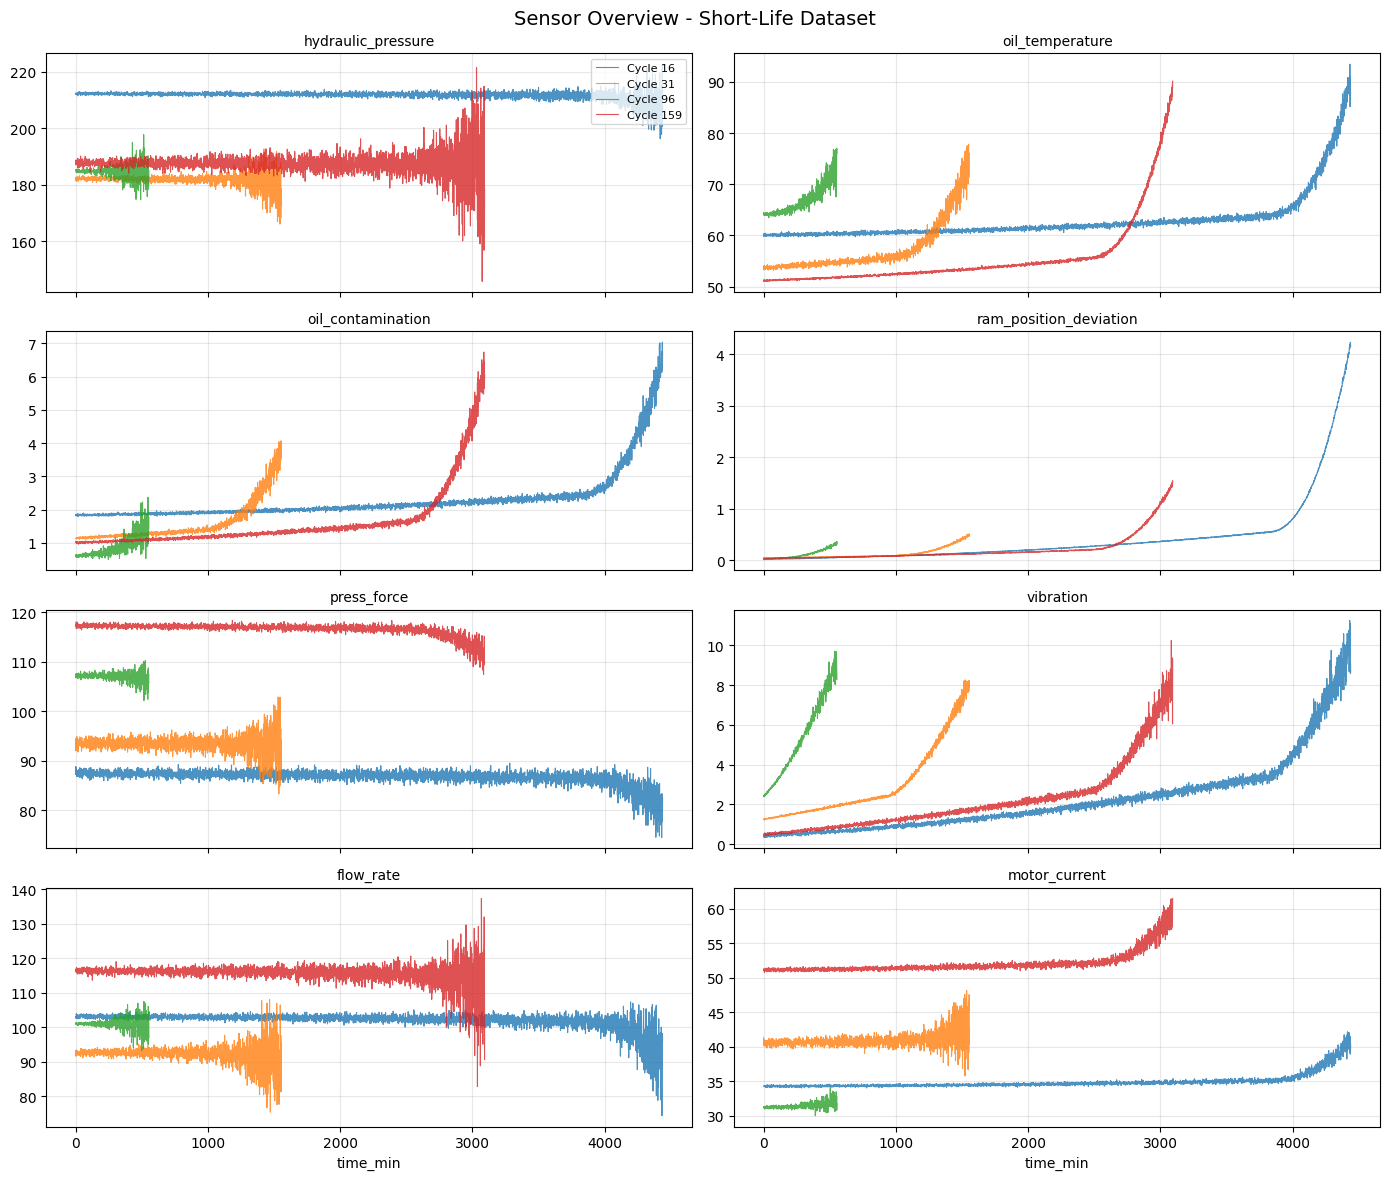


Sampling Long-Life dataset for visualization...
Selected cycles for Long-Life Dataset (Sampled): [13, 58, 62, 75]


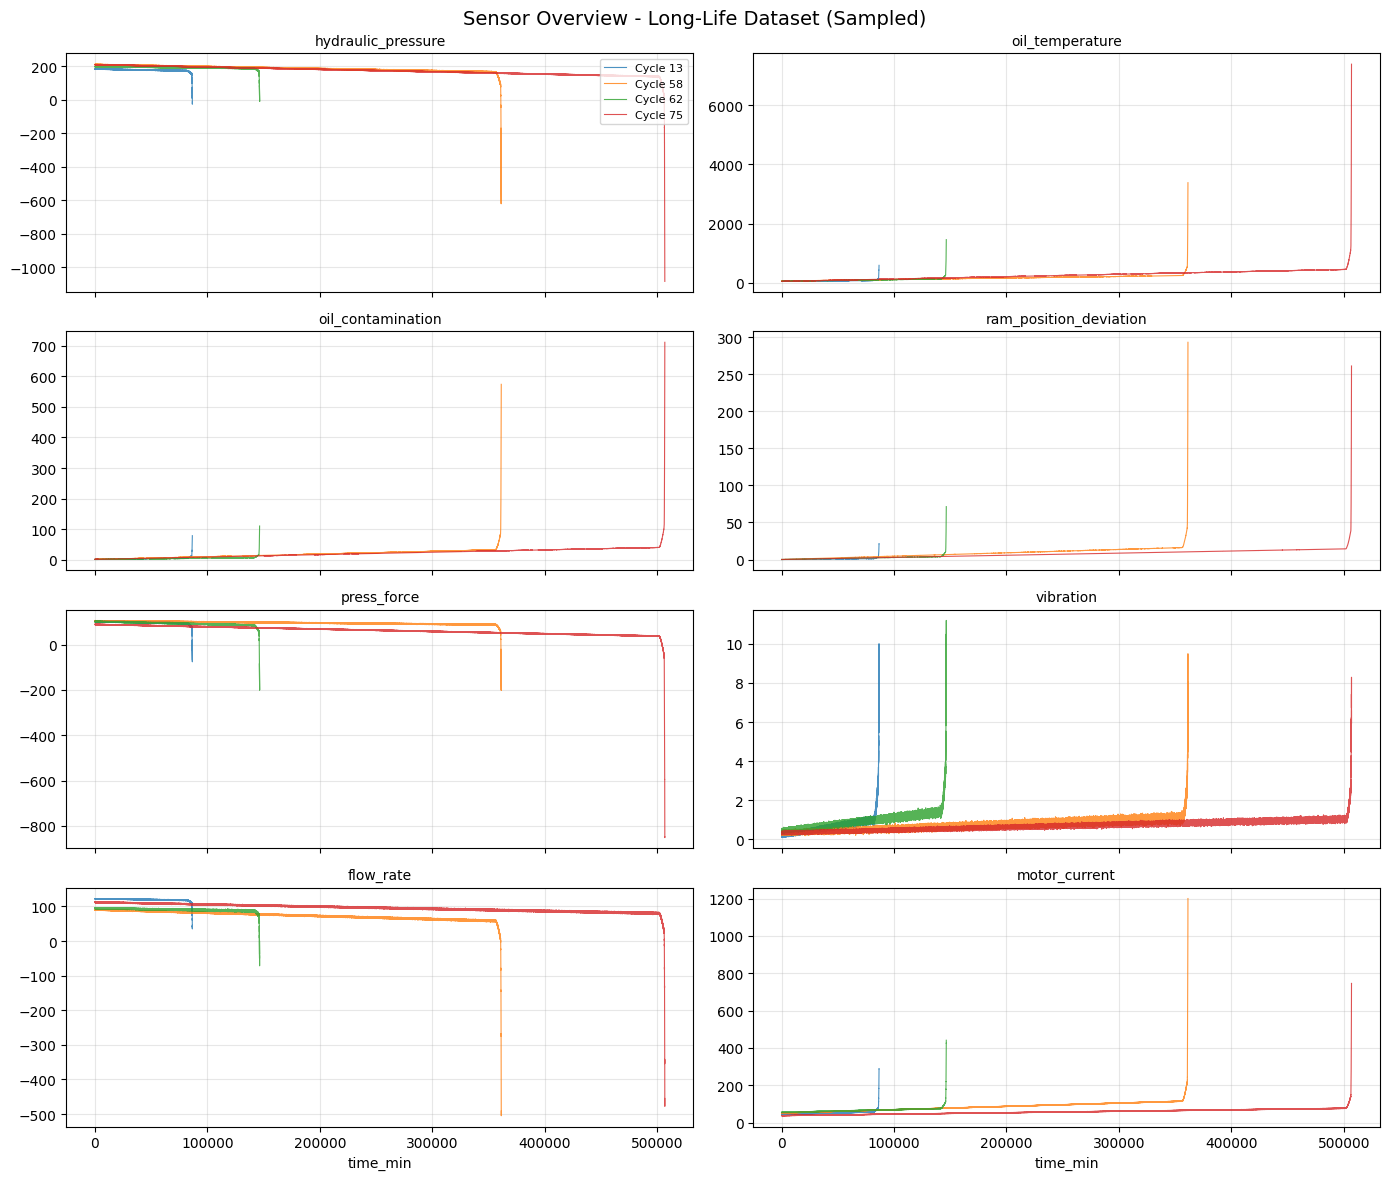


----------------------------------------------------------------------
EDA COMPLETE
----------------------------------------------------------------------


In [7]:
# 2/ Exploratory Data Analysis - Sensor Overview
print_header("2/ EXPLORATORY DATA ANALYSIS")

def plot_sensor_overview(dataframe, dataset_name):
    """Plot sensor trends for selected cycles."""
    
    # Select 4 random cycles for visualization
    np.random.seed(42)
    all_cycles = sorted(dataframe['cycle_id'].unique())
    selected_cycles = sorted(np.random.choice(all_cycles, size=min(4, len(all_cycles)), replace=False))
    
    print(f"Selected cycles for {dataset_name}: {selected_cycles}")
    
    # Create subplot grid
    fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
    axes = axes.flatten()
    
    colors = plt.cm.tab10.colors[:4]
    
    for sensor_idx, sensor_name in enumerate(SENSOR_COLUMNS):
        ax = axes[sensor_idx]
        
        for cycle_idx, cycle_id in enumerate(selected_cycles):
            cycle_data = dataframe[dataframe['cycle_id'] == cycle_id].sort_values('time_min')
            ax.plot(
                    cycle_data['time_min'], 
                    cycle_data[sensor_name], 
                    label=f'Cycle {cycle_id}',
                    color=colors[cycle_idx],
                    linewidth=0.8,
                    alpha=0.8
                )
        
        ax.set_title(sensor_name, fontsize=10)
        ax.grid(alpha=0.3)
    
    # Add legend to first subplot
    axes[0].legend(loc='upper right', fontsize=8)
    
    # Set common x-label
    for ax in axes[-2:]:
        ax.set_xlabel('time_min')
    
    fig.suptitle(f'Sensor Overview - {dataset_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

# Plot for Short-Life (smaller dataset, faster to plot)
plot_sensor_overview(df_short_life, "Short-Life Dataset")

# Sample Long-Life for faster plotting
print("\nSampling Long-Life dataset for visualization...")
sample_cycles = np.random.choice(df_long_life['cycle_id'].unique(), size=4, replace=False)
df_long_sample = df_long_life[df_long_life['cycle_id'].isin(sample_cycles)]
plot_sensor_overview(df_long_sample, "Long-Life Dataset (Sampled)")

# Clean up sample
del df_long_sample
gc.collect()

print_footer("EDA COMPLETE")

### 2A) Additional EDA: RUL, Correlation & Distributions


2A/ CORRELATION ANALYSIS
Short-Life Dataset Correlations:


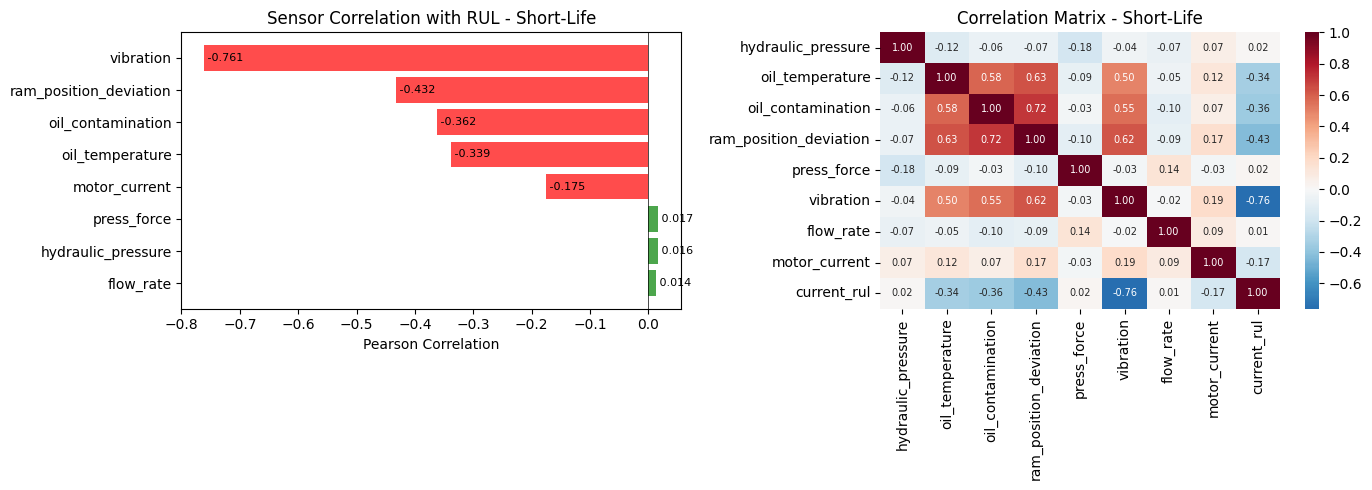

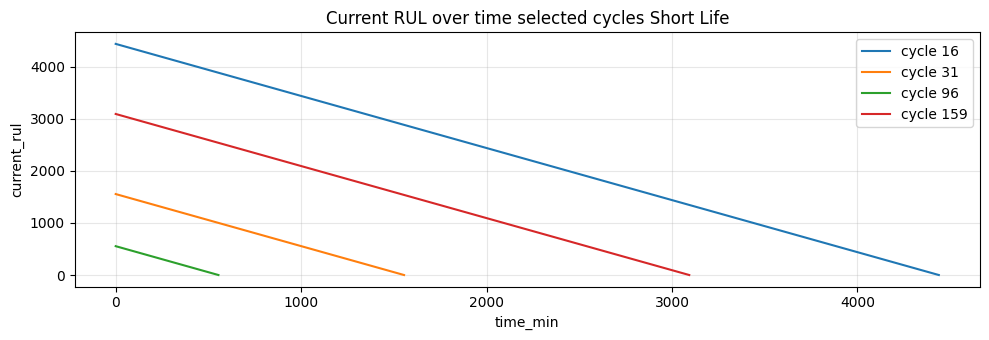


Long-Life Dataset Correlations (sampled):


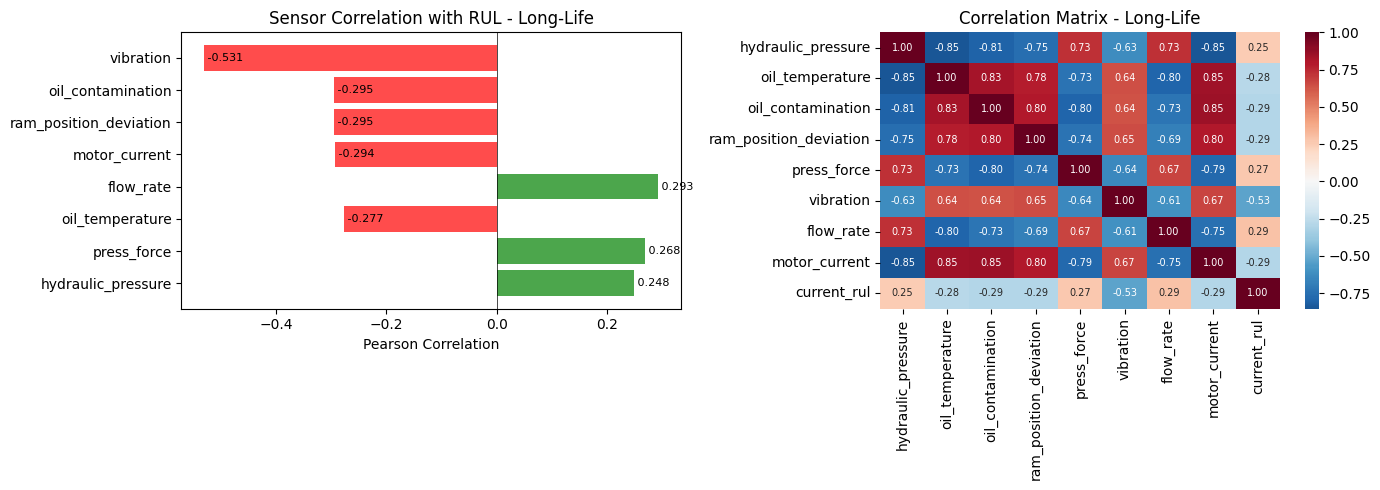

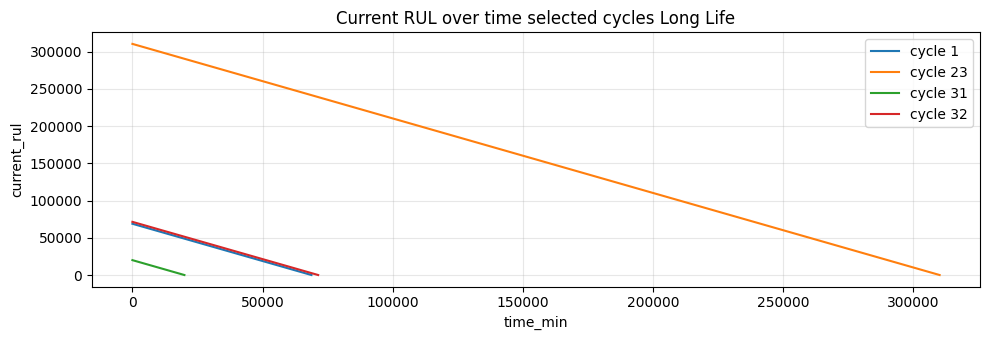


----------------------------------------------------------------------
CORRELATION ANALYSIS COMPLETE
----------------------------------------------------------------------


In [8]:
# 2A/ Correlation Analysis
print_header("2A/ CORRELATION ANALYSIS")

SENSOR_COLUMNS = [
                    'hydraulic_pressure', 'oil_temperature', 'oil_contamination',
                    'ram_position_deviation', 'press_force', 'vibration',
                    'flow_rate', 'motor_current'
                ]


def plot_correlation_analysis(dataframe, dataset_name, sample_size=50000):
    """Plot correlation between sensors and RUL."""
    
    # Sample for memory efficiency
    if len(dataframe) > sample_size:
        df_sample = dataframe.sample(n=sample_size, random_state=42)
    else:
        df_sample = dataframe
    
    # Columns for correlation
    correlation_columns = SENSOR_COLUMNS + ['current_rul']
    
    # Calculate correlation matrix
    correlation_matrix = df_sample[correlation_columns].corr()
    
    # Extract RUL correlations
    rul_correlations = correlation_matrix['current_rul'].drop('current_rul')
    rul_correlations_sorted = rul_correlations.reindex(rul_correlations.abs().sort_values().index)
    
    # Plot correlation bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart of RUL correlations
    ax1 = axes[0]
    colors = ['green' if x > 0 else 'red' for x in rul_correlations_sorted.values]
    ax1.barh(rul_correlations_sorted.index, rul_correlations_sorted.values, color=colors, alpha=0.7)
    ax1.set_xlabel('Pearson Correlation')
    ax1.set_title(f'Sensor Correlation with RUL - {dataset_name}')
    ax1.axvline(x=0, color='black', linewidth=0.5)
    
    for i, (sensor, corr) in enumerate(rul_correlations_sorted.items()):
        ax1.text(corr, i, f' {corr:.3f}', va='center', fontsize=8)
    
    # Heatmap
    ax2 = axes[1]
    sns.heatmap(
                    correlation_matrix, 
                    annot=True, 
                    fmt='.2f', 
                    cmap='RdBu_r', 
                    center=0,
                    ax=ax2,
                    annot_kws={'size': 7}
                )
    ax2.set_title(f'Correlation Matrix - {dataset_name}')
    
    plt.tight_layout()
    plt.show()
    
    return rul_correlations_sorted

def additional_eda(dataframe_input, title_suffix=""):
    if not isinstance(dataframe_input, pl.DataFrame):
        dataframe_polars = pl.from_pandas(dataframe_input)
    else:
        dataframe_polars = dataframe_input

    available_sensors = [sensor_name for sensor_name in SENSOR_COLUMNS if sensor_name in dataframe_polars.columns]

    if not available_sensors:
        print(f"No sensor columns available for 2A EDA {title_suffix}")
        return

    np.random.seed(42)
    unique_cycle_ids = sorted(dataframe_polars.get_column("cycle_id").unique().to_list())
    number_of_cycles = min(4, len(unique_cycle_ids))
    selected_cycle_ids = sorted(np.random.choice(unique_cycle_ids, size=number_of_cycles, replace=False))

    plt.figure(figsize=(10, 3.5))
    for cycle_id in selected_cycle_ids:
        cycle_subset = dataframe_polars.filter(pl.col("cycle_id") == cycle_id).sort("time_min")
        plt.plot(
                    cycle_subset.get_column("time_min").to_numpy(),
                    cycle_subset.get_column("current_rul").to_numpy(),
                    label=f'cycle {cycle_id}',
                    linewidth=1.5
                )
    plt.xlabel('time_min')
    plt.ylabel('current_rul')
    plt.title(f'Current RUL over time selected cycles {title_suffix}')
    plt.grid(alpha=0.3)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()



# Analyze Short-Life dataset
print("Short-Life Dataset Correlations:")
short_correlations = plot_correlation_analysis(df_short_life, "Short-Life")
additional_eda(df_short_life, title_suffix="Short Life")

# Analyze Long-Life dataset (sampled)
print("\nLong-Life Dataset Correlations (sampled):")
long_correlations = plot_correlation_analysis(df_long_life, "Long-Life")
additional_eda(df_long_life, title_suffix="Long Life")

print_footer("CORRELATION ANALYSIS COMPLETE")

### 2B) Cycle-to-cycle comparison (start vs end)

2B/ CYCLE COMPARISONS - start vs end summaries and plots

Example start/end table (Short Life) (first 8 cycles - sample sensors):


,cycle_id,hydraulic_pressure,oil_temperature,oil_contamination,ram_position_deviation,hydraulic_pressure_end,oil_temperature_end,oil_contamination_end,ram_position_deviation_end
0,1,209.624,59.875,0.915,0.027,184.611,140.775,9.467,4.821
1,2,202.071,58.571,0.946,0.011,209.321,59.644,1.535,0.157
2,3,197.062,60.941,1.085,0.045,204.117,81.315,4.131,1.711
3,4,194.008,59.038,0.764,0.033,179.453,81.992,1.912,0.877
4,5,205.185,64.868,1.076,0.020,208.685,118.011,5.000,1.379
5,6,216.151,60.881,0.930,0.041,207.470,124.691,7.214,4.693
6,7,204.304,50.754,0.572,0.032,191.750,120.893,6.559,4.694
7,8,213.882,56.291,1.706,0.039,225.347,75.414,3.872,0.981



Delta summary (Short Life) (end - start):
                              count    mean     std     min     25%     50%     75%     max
hydraulic_pressure_delta      200.0  -5.387  12.964 -43.645 -13.806  -4.717   3.082  45.662
oil_temperature_delta         200.0  27.284  20.075  -0.652  11.631  23.056  38.614  89.584
oil_contamination_delta       200.0   2.736   1.985  -0.271   1.253   2.440   3.678   8.579
ram_position_deviation_delta  200.0   1.490   1.201   0.088   0.557   1.111   2.108   5.254
press_force_delta             200.0  -3.114   3.852 -16.571  -5.745  -3.264  -0.526   8.816
vibration_delta               200.0   7.434   1.969   1.751   6.009   7.415   8.874  11.986
flow_rate_delta               200.0  -3.638   8.676 -27.890  -9.339  -4.378   2.298  20.456
motor_current_delta           200.0   5.675   4.458  -5.042   2.323   5.070   8.523  19.012


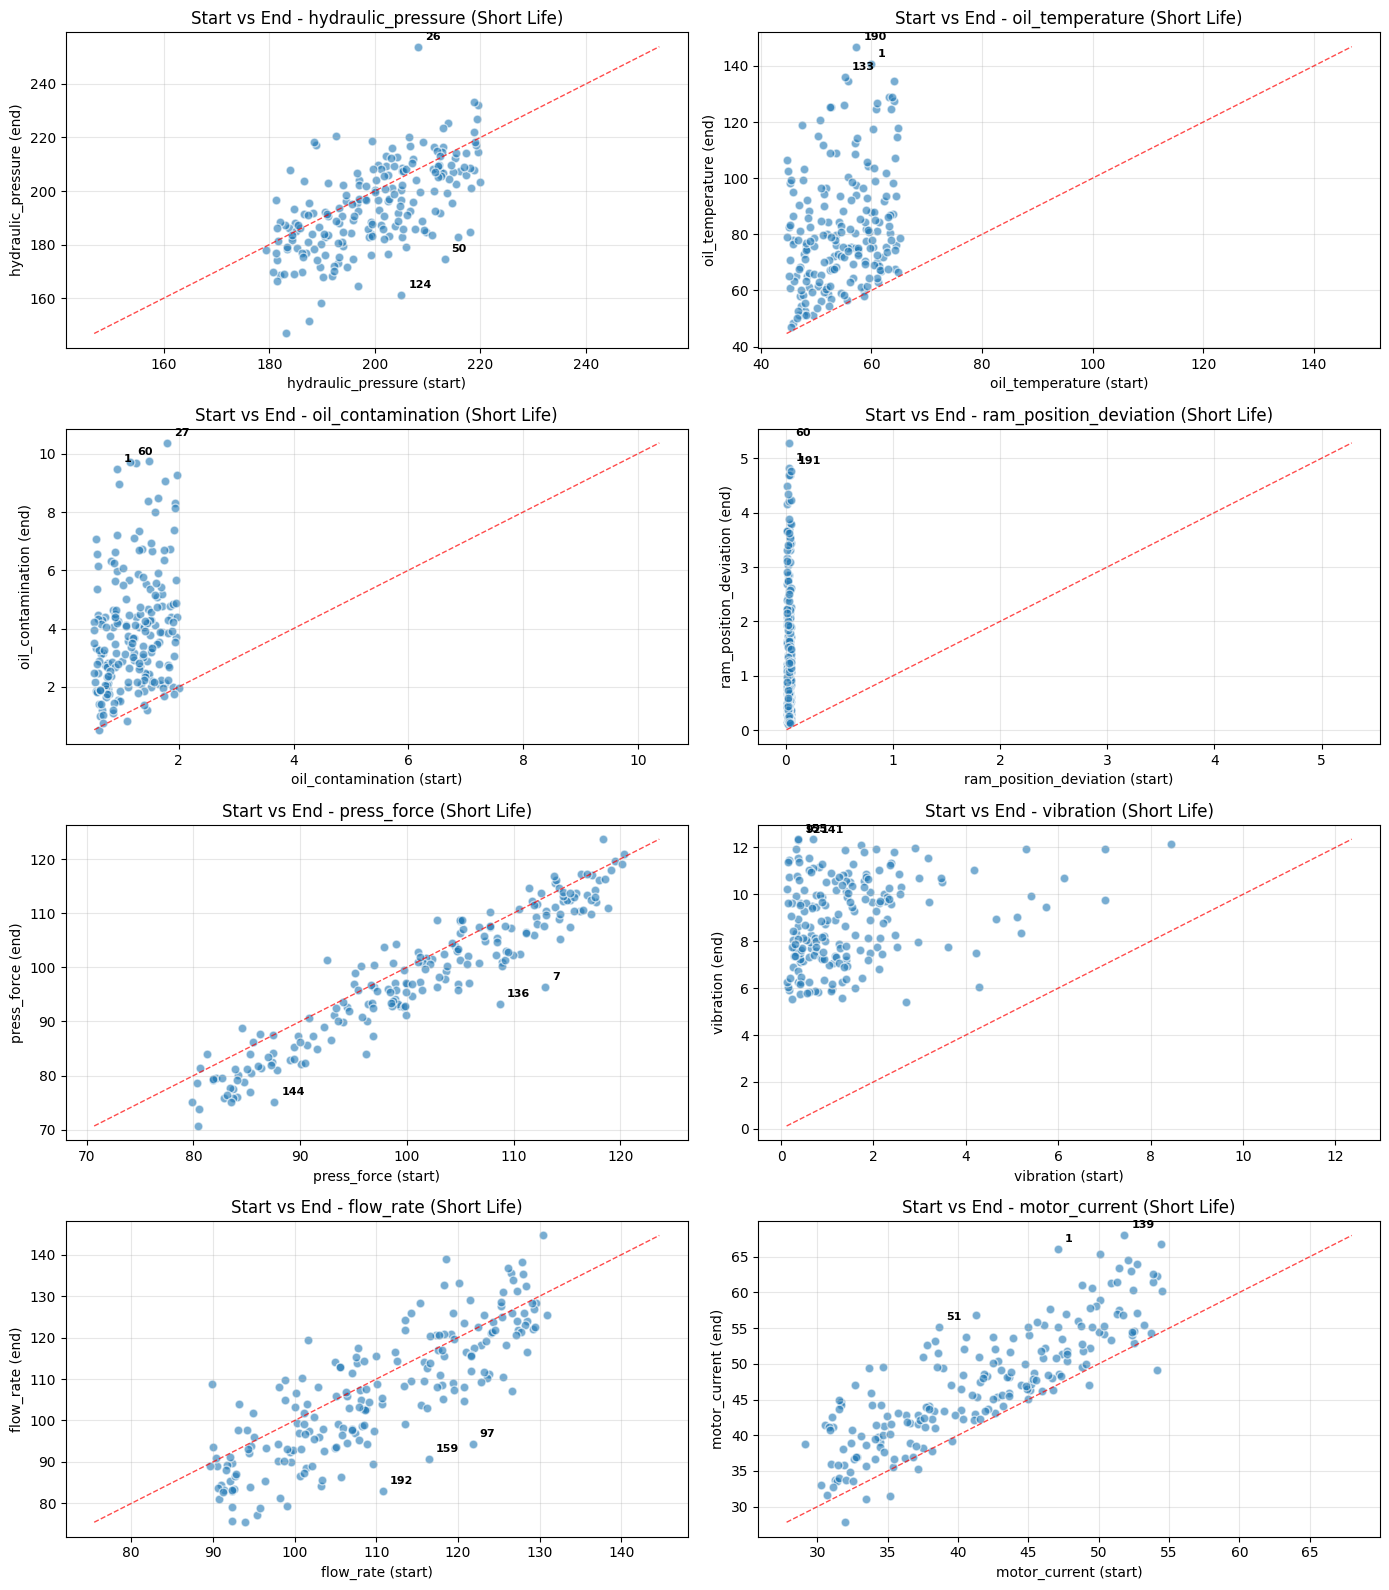


Top Extremes per Sensor ((Short Life))

Largest increase in hydraulic_pressure:
 cycle_id  hydraulic_pressure  hydraulic_pressure_end  hydraulic_pressure_delta
       26             208.210                 253.872                    45.662
      168             188.462                 218.149                    29.686
      162             188.849                 217.099                    28.250
Largest decrease in hydraulic_pressure:
 cycle_id  hydraulic_pressure  hydraulic_pressure_end  hydraulic_pressure_delta
      124             205.011                 161.366                   -43.645
       50             213.229                 174.780                   -38.448
      175             183.123                 146.840                   -36.283

Largest increase in oil_temperature:
 cycle_id  oil_temperature  oil_temperature_end  oil_temperature_delta
      190           57.280              146.864                 89.584
      133           55.190              136.147            

,cycle_id,hydraulic_pressure,oil_temperature,oil_contamination,ram_position_deviation,hydraulic_pressure_end,oil_temperature_end,oil_contamination_end,ram_position_deviation_end
0,1,197.278,46.917,1.686,0.025,47.122,1260.999,49.728,69.759
1,2,192.597,59.441,1.778,0.051,-975.582,8884.533,511.143,106.347
2,3,197.392,55.834,0.989,0.032,-1044.622,7601.489,488.789,510.361
3,4,214.741,55.321,0.954,0.033,-869.094,7276.625,1046.673,261.060
4,5,185.260,58.409,0.598,0.021,-1186.655,12083.851,1017.109,508.334
5,6,191.229,64.729,0.606,0.033,-916.771,9992.007,432.584,555.020
6,7,217.811,47.357,1.264,0.020,-234.806,3016.270,455.060,232.256
7,8,199.032,59.786,1.691,0.051,-13.825,510.942,113.219,39.633



Delta summary (Long Life) (end - start):
                              count      mean       std       min       25%       50%       75%        max
hydraulic_pressure_delta       80.0  -589.119   449.804 -1679.219  -970.090  -463.117  -211.532     -1.892
oil_temperature_delta          80.0  3745.575  2965.822   110.137  1435.135  3069.647  5318.438  12025.441
oil_contamination_delta        80.0   385.797   301.546     5.585   154.529   294.867   574.773   1199.817
ram_position_deviation_delta   80.0   186.748   150.014     2.370    74.117   132.442   262.281    639.812
press_force_delta              80.0  -479.083   387.740 -1465.163  -795.702  -331.032  -163.828    -10.952
vibration_delta                80.0     8.736     2.008     4.025     7.348     8.953    10.178     12.360
flow_rate_delta                80.0  -538.090   414.047 -1753.996  -764.537  -419.443  -218.998     -8.294
motor_current_delta            80.0   744.508   562.537    16.033   334.877   631.853  1090.830   2438

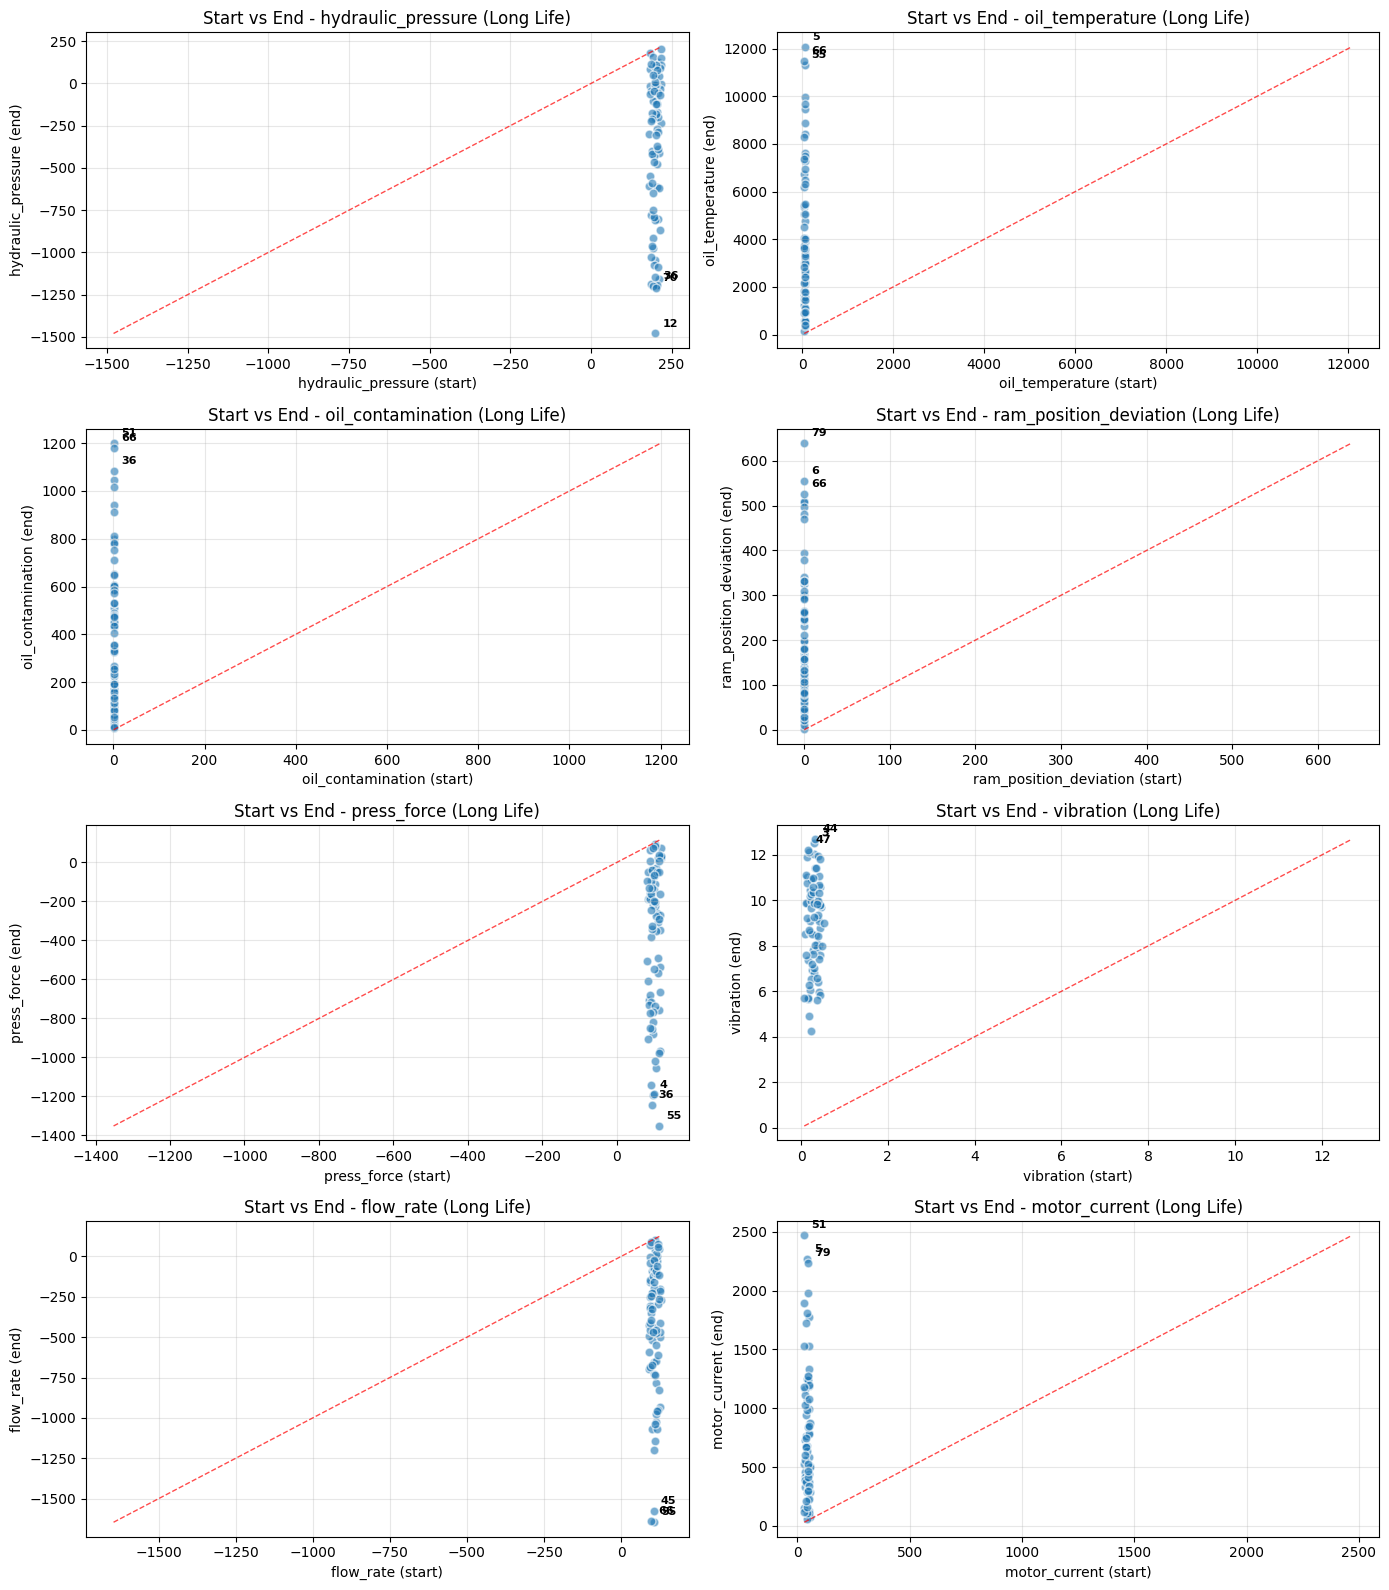


Top Extremes per Sensor ((Long Life))

Largest increase in hydraulic_pressure:
 cycle_id  hydraulic_pressure  hydraulic_pressure_end  hydraulic_pressure_delta
       11             182.993                 181.101                    -1.892
       31             217.192                 203.358                   -13.834
       28             191.852                 157.332                   -34.520
Largest decrease in hydraulic_pressure:
 cycle_id  hydraulic_pressure  hydraulic_pressure_end  hydraulic_pressure_delta
       12             199.775               -1479.443                 -1679.219
       70             201.017               -1211.518                 -1412.535
       36             202.340               -1198.630                 -1400.971

Largest increase in oil_temperature:
 cycle_id  oil_temperature  oil_temperature_end  oil_temperature_delta
        5           58.409            12083.851              12025.441
       66           46.823            11497.672             

In [9]:
# 2B/ Cycle Comparisons - Start vs End Summaries and Plots
print("2B/ CYCLE COMPARISONS - start vs end summaries and plots")

def cycle_comparison(df_raw, title_suffix=""):
   
    # Determine sensor list
    if 'SENSOR_COLUMNS' in globals():
        sensors = SENSOR_COLUMNS
    else:
        sensors = [
                    "hydraulic_pressure", "oil_temperature", "oil_contamination",
                    "ram_position_deviation", "press_force", "vibration",
                    "flow_rate", "motor_current"
                ]

    # polars or pandas input
    try:
        is_pl = isinstance(df_raw, pl.DataFrame)
    except Exception:
        is_pl = False

    if is_pl:
        df_sorted = df_raw.sort(["cycle_id", "time_min"])
        firsts = df_sorted.groupby("cycle_id").first()
        lasts = df_sorted.groupby("cycle_id").last()
        # select only needed sensor cols that exist
        available_sensors = [s for s in sensors if s in df_raw.columns]
        cols_start = ["cycle_id"] + available_sensors
        cols_end = ["cycle_id"] + available_sensors
        start_end = firsts.select(cols_start).join(lasts.select(cols_end), on="cycle_id", how="inner", suffix="_end")
        # compute deltas and pct change using polars then convert to pandas for plotting
        for s in available_sensors:
            start_end = start_end.with_columns(
                                                    (pl.col(f"{s}_end") - pl.col(s)).alias(f"{s}_delta")
                                                ).with_columns(
                                                                ( (pl.col(f"{s}_delta") / pl.when(pl.col(s) == 0).then(None).otherwise(pl.col(s))) * 100 ).alias(f"{s}_pct_change")
                                                )
        start_end_pd = start_end.to_pandas()
    else:
        # pandas path
        df_sorted = df_raw.sort_values(["cycle_id", "time_min"])
        available_sensors = [s for s in sensors if s in df_raw.columns]
        if not available_sensors:
            print(f"No sensors found to compare {title_suffix}")
            return
        firsts = df_sorted.groupby("cycle_id").first().reset_index()
        lasts = df_sorted.groupby("cycle_id").last().reset_index()

        # build lasts_end by renaming only sensor columns
        lasts_end = lasts[["cycle_id"] + available_sensors].copy()
        lasts_end = lasts_end.rename(columns={s: f"{s}_end" for s in available_sensors})

        start_end_pd = pd.merge(
                                    firsts[["cycle_id"] + available_sensors],
                                    lasts_end,
                                    on="cycle_id",
                                    how="inner"
                                )

        # compute deltas and percent changes
        for s in available_sensors:
            start_end_pd[f"{s}_delta"] = start_end_pd[f"{s}_end"] - start_end_pd[s]
            start_end_pd[f"{s}_pct_change"] = start_end_pd[f"{s}_delta"] / start_end_pd[s].replace(0, np.nan) * 100.0


    # Basic display
    cols_show = ["cycle_id"] + available_sensors[:4] + [f"{s}_end" for s in available_sensors[:4]]
    print(f"\nExample start/end table {title_suffix} (first 8 cycles - sample sensors):")
    display(start_end_pd[cols_show].head(8))

    delta_cols = [f"{s}_delta" for s in available_sensors]
    print(f"\nDelta summary {title_suffix} (end - start):")
    print(start_end_pd[delta_cols].describe().T)

    # Plotting: dynamic grid (2 columns)
    n = len(available_sensors)
    cols = 2
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    axes = axes.flatten()

    for i, s in enumerate(available_sensors):
        ax = axes[i]
        x = start_end_pd[s]
        y = start_end_pd[f"{s}_end"]
        ax.scatter(x, y, alpha=0.6, edgecolors="w", s=40)
        lims = [min(x.min(), y.min()), max(x.max(), y.max())]
        ax.plot(lims, lims, "--", color="red", linewidth=1, alpha=0.7)
        ax.set_xlabel(f"{s} (start)")
        ax.set_ylabel(f"{s} (end)")
        ax.set_title(f"Start vs End - {s} {title_suffix}")
        ax.grid(alpha=0.3)

        # annotate top 3 absolute deltas
        top3_idx = start_end_pd[f"{s}_delta"].abs().nlargest(3).index
        for idx in top3_idx:
            row = start_end_pd.loc[idx]
            cid = int(row["cycle_id"])
            ax.annotate(
                            cid,
                            (row[s], row[f"{s}_end"]),
                            textcoords="offset points",
                            xytext=(5, 5),
                            fontsize=8,
                            fontweight="bold"
                        )

    # turn off unused axes
    for j in range(n, rows * cols):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    # Print top extremes for first three sensors
    print(f"\nTop Extremes per Sensor ({title_suffix})")
    for s in available_sensors[:3]:
        print(f"\nLargest increase in {s}:")
        print(start_end_pd[["cycle_id", s, f"{s}_end", f"{s}_delta"]].nlargest(3, f"{s}_delta").to_string(index=False))
        print(f"Largest decrease in {s}:")
        print(start_end_pd[["cycle_id", s, f"{s}_end", f"{s}_delta"]].nsmallest(3, f"{s}_delta").to_string(index=False))

    print(f"\n{'='*50}\nExplanatory Data Analysis COMPLETED {title_suffix}\n{'='*50}")


cycle_comparison(df_short_life, title_suffix="(Short Life)")
cycle_comparison(df_long_life, title_suffix="(Long Life)")

## 3) Train / Validation / Test split

In [10]:
# 3/ Train / Validation / Test Split
print_header("3/ DATASET SPLIT - Cycle-based")

def split_by_cycles(dataframe, train_ratio=0.7, val_ratio=0.15, random_seed=42):
   
    # Get all unique cycles
    all_cycles = sorted(dataframe['cycle_id'].unique())
    total_cycles = len(all_cycles)
    
    # Shuffle cycles deterministically
    rng = np.random.default_rng(seed=random_seed)
    rng.shuffle(all_cycles)
    
    # Calculate split sizes
    n_train = int(total_cycles * train_ratio)
    n_val = int(total_cycles * val_ratio)
    n_test = total_cycles - n_train - n_val
    
    # Split cycles
    train_cycles = all_cycles[:n_train]
    val_cycles = all_cycles[n_train:n_train + n_val]
    test_cycles = all_cycles[n_train + n_val:]
    
    # Create dataframes
    df_train = dataframe[dataframe['cycle_id'].isin(train_cycles)].copy()
    df_val = dataframe[dataframe['cycle_id'].isin(val_cycles)].copy()
    df_test = dataframe[dataframe['cycle_id'].isin(test_cycles)].copy()
    
    # Print split info
    print(f"Total cycles: {total_cycles}")
    print(f"Train cycles ({len(train_cycles)}): {train_cycles[:5]}...")
    print(f"Val cycles ({len(val_cycles)}): {val_cycles[:5]}...")
    print(f"Test cycles ({len(test_cycles)}): {test_cycles[:5]}...")
    print(f"\nRow counts:")
    print(f"  Train: {len(df_train):,} rows")
    print(f"  Val: {len(df_val):,} rows")
    print(f"  Test: {len(df_test):,} rows")
    
    # Verify no overlap
    assert set(train_cycles).isdisjoint(val_cycles), "Train and Val cycles overlap!"
    assert set(train_cycles).isdisjoint(test_cycles), "Train and Test cycles overlap!"
    assert set(val_cycles).isdisjoint(test_cycles), "Val and Test cycles overlap!"
    
    return df_train, df_val, df_test

# Split Short-Life dataset
print("--- Short-Life Dataset Split")
df_train_short, df_val_short, df_test_short = split_by_cycles(df_short_life)

print("\n" + "=" * 70)

# Split Long-Life dataset
print("\n--- Long-Life Dataset Split")
df_train_long, df_val_long, df_test_long = split_by_cycles(df_long_life)

# Free original dataframes to save memory
print("\nFreeing original dataframes...")
del df_long_life, df_short_life
gc.collect()

print_footer("DATA SPLIT COMPLETE")


3/ DATASET SPLIT - Cycle-based
--- Short-Life Dataset Split
Total cycles: 200
Train cycles (140): [153, 27, 116, 47, 39]...
Val cycles (30): [2, 43, 123, 18, 183]...
Test cycles (30): [45, 185, 35, 31, 59]...

Row counts:
  Train: 344,084 rows
  Val: 62,864 rows
  Test: 61,821 rows


--- Long-Life Dataset Split
Total cycles: 80
Train cycles (56): [34, 52, 41, 29, 62]...
Val cycles (12): [69, 75, 55, 50, 7]...
Test cycles (12): [36, 65, 48, 13, 54]...

Row counts:
  Train: 17,105,638 rows
  Val: 4,598,831 rows
  Test: 3,751,887 rows

Freeing original dataframes...

----------------------------------------------------------------------
DATA SPLIT COMPLETE
----------------------------------------------------------------------



3A/ SPLIT VISUALIZATION - cycles, RUL & sensor distributions
Dataset         : (Short Life)
Selected sensor : vibration
Train cycles    : 140
Val cycles      : 30
Test cycles     : 30


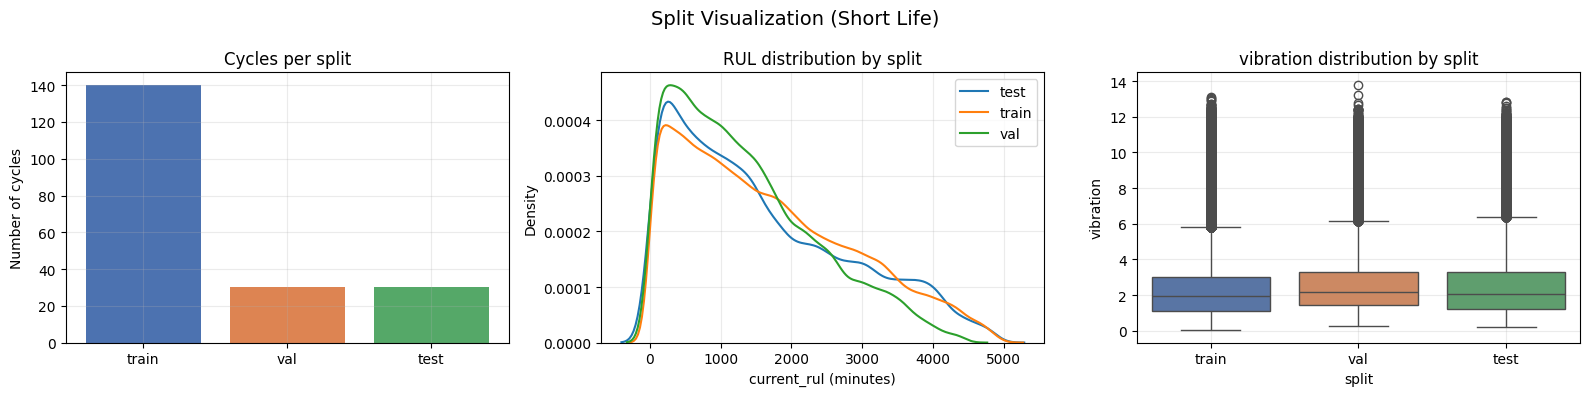


----------------------------------------------------------------------
SPLIT VISUALIZATION COMPLETE (Short Life)
----------------------------------------------------------------------
Dataset         : (Long Life)
Selected sensor : vibration
Train cycles    : 56
Val cycles      : 12
Test cycles     : 12


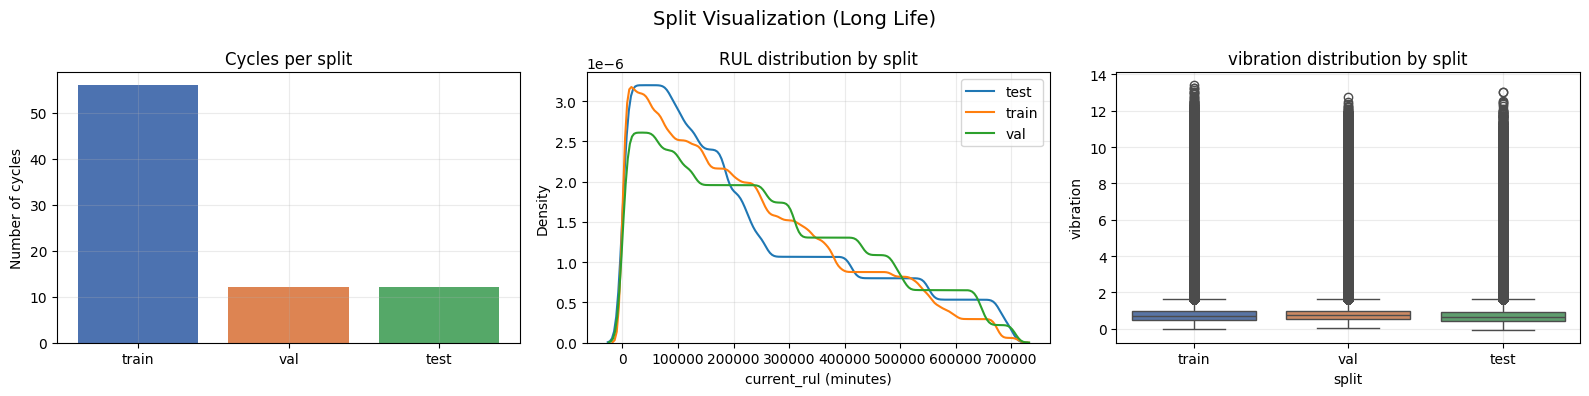


----------------------------------------------------------------------
SPLIT VISUALIZATION COMPLETE (Long Life)
----------------------------------------------------------------------


In [11]:
# 3A/ Split Visualization - cycles, RUL & sensor distributions
print_header("3A/ SPLIT VISUALIZATION - cycles, RUL & sensor distributions")

def visualize_splits(df_train, df_val, df_test, title_suffix=""):
    # Ensure RUL is present
    assert 'current_rul' in df_train.columns, "current_rul missing in selected split dataframe"

    # Choose a sensor to visualize (prefer 'vibration' or fallback)
    preferred = 'vibration'
    if preferred in df_train.columns:
        sensor_col = preferred
    else:
        exclude = {'cycle_id', 'time_min', 'timestamp', 'total_rul', 'current_rul'}
        numeric = get_numeric_sensor_cols(df_train, exclude)
        sensor_col = numeric[0] if len(numeric) > 0 else None

    assert sensor_col is not None, "No suitable sensor or feature column found for visualization"

    # Prepare combined dataframe for easy plotting
    def tag_split(df, name):
        d = df[[sensor_col, 'current_rul', 'cycle_id']].copy()
        d['split'] = name
        return d

    plot_df = pd.concat([
                            tag_split(df_train, 'train'),
                            tag_split(df_val, 'val'),
                            tag_split(df_test, 'test')
                        ], ignore_index=True)

    print_kv([
                ('Dataset', title_suffix),
                ('Selected sensor', sensor_col),
                ('Train cycles', df_train['cycle_id'].nunique()),
                ('Val cycles', df_val['cycle_id'].nunique()),
                ('Test cycles', df_test['cycle_id'].nunique())
            ])

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Cycles per split
    counts = [df_train['cycle_id'].nunique(),
              df_val['cycle_id'].nunique(),
              df_test['cycle_id'].nunique()]
    axes[0].bar(['train', 'val', 'test'], counts,
                color=['#4c72b0', '#dd8452', '#55a868'])
    axes[0].set_title('Cycles per split')
    axes[0].set_ylabel('Number of cycles')
    axes[0].grid(alpha=0.25)

    # RUL distribution (overlayed KDEs)
    for name, grp in plot_df.groupby('split'):
        sns.kdeplot(grp['current_rul'], ax=axes[1], label=name, fill=False)
    axes[1].set_title('RUL distribution by split')
    axes[1].set_xlabel('current_rul (minutes)')
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    # Sensor distribution (boxplot)
    sns.boxplot(x='split', y=sensor_col, data=plot_df,
                ax=axes[2], palette=['#4c72b0', '#dd8452', '#55a868'])
    axes[2].set_title(f'{sensor_col} distribution by split')
    axes[2].grid(alpha=0.25)

    plt.suptitle(f"Split Visualization {title_suffix}", fontsize=14)
    plt.tight_layout()
    plt.show()

    print_footer(f"SPLIT VISUALIZATION COMPLETE {title_suffix}")


# Run for both datasets
visualize_splits(df_train_short, df_val_short, df_test_short, title_suffix="(Short Life)")
visualize_splits(df_train_long, df_val_long, df_test_long, title_suffix="(Long Life)")

## 4) Feature Engineering

In [12]:
# 4/ Feature Engineering - Causal & Critical-Aware
print_header("4/ FEATURE ENGINEERING - Causal & Critical-Aware")

# Global sensor ranges from training data distribution
# These ranges are used for degradation_index normalization
# Must match inference handler exactly to avoid train/inference mismatch
GLOBAL_SENSOR_RANGES = {
                            "vibration": (0.11, 12.60),
                            "oil_temperature": (46.23, 815.08),
                            "hydraulic_pressure": (76.03, 201.0),
                            "oil_contamination": (1.63, 27.85)
                        }

def engineer_features_streaming(df, sensors=None, window_short=5, window_long=20):
    if sensors is None:
        sensors = SENSOR_COLUMNS

    if isinstance(df, pd.DataFrame):
        df_pl = pl.from_pandas(df).lazy()
    elif isinstance(df, pl.DataFrame):
        df_pl = df.lazy()
    else:
        raise TypeError("df must be pandas.DataFrame or polars.DataFrame")

    main_exprs = []
    for s in sensors:
        if s in df_pl.columns:
            main_exprs.extend([
                                pl.col(s).rolling_mean(window_short).over("cycle_id").alias(f"{s}_roll_mean_{window_short}"),
                                pl.col(s).rolling_mean(window_long).over("cycle_id").alias(f"{s}_roll_mean_{window_long}"),
                                pl.col(s).rolling_std(window_long).over("cycle_id").fill_null(0).alias(f"{s}_roll_std_{window_long}"),
                            ])

    df_pl = df_pl.with_columns(main_exprs)

    derived_exprs = []
    for s in sensors:
        if s in df_pl.columns:
            derived_exprs.append((pl.col(s) - pl.col(f"{s}_roll_mean_{window_long}")).alias(f"{s}_dev_long"))
            derived_exprs.append(pl.col(f"{s}_roll_mean_{window_long}").diff().over("cycle_id").fill_null(0).alias(f"{s}_slope_{window_long}"))

    if 'press_force' in df_pl.columns and 'hydraulic_pressure' in df_pl.columns:
        derived_exprs.append((pl.col('press_force') / pl.col('hydraulic_pressure')).fill_nan(1.0).clip(0, 10).alias('force_pressure_coupling'))
    else:
        derived_exprs.append(pl.lit(1.0).alias('force_pressure_coupling'))

    if 'vibration' in df_pl.columns:
        derived_exprs.append((pl.col('vibration').rolling_mean(window_short).over("cycle_id") ** 2).alias('vibration_energy'))

    if 'hydraulic_pressure_roll_std_20' in df_pl.columns:
        derived_exprs.append((1.0 / pl.col('hydraulic_pressure_roll_std_20').clip(1e-4)).log1p().alias('pressure_stability'))
    else:
        derived_exprs.append(pl.lit(0.0).alias('pressure_stability'))

    df_pl = df_pl.with_columns(derived_exprs)

    crit_exprs = []
    for s in ['vibration', 'oil_temperature', 'motor_current']:
        col = f"{s}_slope_{window_long}"
        if col in df_pl.columns:
            crit_exprs.append(pl.col(col).diff(5).over("cycle_id").fill_null(0).alias(f"{s}_acceleration"))
        else:
            crit_exprs.append(pl.lit(0.0).alias(f"{s}_acceleration"))

    for s in sensors:
        if s in df_pl.columns:
            short_std = pl.col(s).rolling_std(5).over("cycle_id")
            long_std = pl.col(f"{s}_roll_std_{window_long}")
            crit_exprs.append(pl.when((short_std - long_std) > 0).then(short_std - long_std).otherwise(0).fill_null(0).alias(f"{s}_volatility_surge"))

    # Degradation index using global fixed ranges (no look-ahead bias)
    # This matches the inference handler normalization exactly
    def get_norm_global(col_name):
        if col_name not in df_pl.columns:
            return pl.lit(0.0)
        g_min, g_max = GLOBAL_SENSOR_RANGES.get(col_name, (0.0, 1.0))
        eps = 1e-9
        c = pl.col(col_name)
        return ((c - g_min) / (g_max - g_min + eps)).clip(0.0, 1.0)

    deg_idx = (get_norm_global('vibration') + get_norm_global('oil_temperature') + (1 - get_norm_global('hydraulic_pressure')) + get_norm_global('oil_contamination')) / 4.0
    crit_exprs.append(deg_idx.alias("degradation_index"))

    for s in ['vibration', 'motor_current']:
        if s in df_pl.columns:
            crit_exprs.append(pl.col(s).rolling_max(10).over("cycle_id").fill_null(0).alias(f"{s}_max_10"))
        else:
            crit_exprs.append(pl.lit(0.0).alias(f"{s}_max_10"))

    df_pl = df_pl.with_columns(crit_exprs)

    # Additional trend features for better RUL correlation
    trend_exprs = []

    # Time progress within cycle
    trend_exprs.append(
                        (
                            pl.col("time_min").cum_count().over("cycle_id") / pl.col("time_min").count().over("cycle_id")
                        ).alias("time_progress")
                    )

    # Interaction features for degradation pattern
    if 'vibration' in df_pl.columns and 'oil_temperature' in df_pl.columns:
        trend_exprs.append(
                                (pl.col('vibration') * pl.col('oil_temperature') / 100.0).alias('vib_temp_interaction')
                            )

    if 'motor_current' in df_pl.columns and 'hydraulic_pressure' in df_pl.columns:
        trend_exprs.append(
                                (pl.col('motor_current') / pl.col('hydraulic_pressure').clip(1.0)).alias('current_pressure_ratio')
                            )

    # Rate of change features (longer window for stability)
    for s in ['vibration', 'oil_temperature', 'motor_current']:
        if s in df_pl.columns:
            trend_exprs.append(
                                    pl.col(s).diff(10).over("cycle_id").fill_null(0).alias(f"{s}_rate_10")
                                )

    df_pl = df_pl.with_columns(trend_exprs)

    # Compute expanding window degradation & cumulative stats using Polars expressions
    # Doing this in Polars (lazy + streaming collect) avoids materializing large pandas groups
    print("  Computing expanding window degradation features (polars streaming)...")

    degradation_sensors = ['vibration', 'oil_temperature', 'oil_contamination', 'motor_current']
    exp_exprs = []
    for s in degradation_sensors:
        if s in df_pl.columns:
            exp_min = pl.col(s).cum_min().over("cycle_id")
            exp_max = pl.col(s).cum_max().over("cycle_id")
            range_expr = (exp_max - exp_min).clip(lower_bound=1e-6)
            exp_exprs.append(((pl.col(s) - exp_min) / range_expr).fill_null(0).clip(0, 1).alias(f"{s}_exp_degradation"))

    if exp_exprs:
        df_pl = df_pl.with_columns(exp_exprs)
        existing_exp_cols = [f"{s}_exp_degradation" for s in degradation_sensors if f"{s}_exp_degradation" in df_pl.columns]
        if existing_exp_cols:
            cols = [pl.col(c) for c in existing_exp_cols]
            df_pl = df_pl.with_columns(((sum(cols) / len(cols)).clip(0.0, 1.0)).alias("exp_degradation_combined"))

    # CUMULATIVE STATISTICS (CAUSAL)
    cum_exprs = []
    for s in ['vibration', 'oil_temperature', 'hydraulic_pressure']:
        if s in df_pl.columns:
            cum_exprs.extend([
                                (pl.col(s).cum_sum().over("cycle_id") / (pl.col(s).cum_count().over("cycle_id") + 1)).fill_null(0).alias(f"{s}_cum_mean"),
                                pl.col(s).cum_max().over("cycle_id").fill_null(0).alias(f"{s}_cum_max")
                            ])
    if cum_exprs:
        df_pl = df_pl.with_columns(cum_exprs)

    # TREND SLOPE FEATURES (vectorized in Polars)
    print("  Computing trend slope features (polars vectorized)...")
    slope_exprs = []
    for s in ['vibration', 'oil_temperature']:
        if s in df_pl.columns:
            rolling_mean = pl.col(s).rolling_mean(20).over("cycle_id")
            lagged_mean = rolling_mean.shift(20).over("cycle_id")
            slope_exprs.append(((rolling_mean - lagged_mean) / 20.0).fill_null(0).alias(f"{s}_trend_slope"))
    if slope_exprs:
        df_pl = df_pl.with_columns(slope_exprs)

    # RELATIVE POSITION WITHIN CYCLE
    pos_exprs = []
    for s in ['vibration', 'oil_temperature']:
        if s in df_pl.columns:
            pos_exprs.append((pl.col(s) / pl.col(s).cum_max().over("cycle_id")).clip(lower_bound=1e-6).fill_null(0.5).clip(0, 1).alias(f"{s}_pct_rank"))
    if pos_exprs:
        df_pl = df_pl.with_columns(pos_exprs)

    # Fill nulls in Polars then collect using streaming to reduce peak memory
    df_pl = df_pl.fill_null(0)

    try:
        result = df_pl.collect(streaming=True).to_pandas()
    except (TypeError, pl.exceptions.SchemaError):
        # Fallback to non-streaming if streaming unsupported or schema issues occur during streaming collect
        result = df_pl.collect().to_pandas()

    return result

def engineer_features(df):
    res = engineer_features_streaming(df)
    gc.collect()
    return res

print("\nProcessing SHORT LIFE Dataset...")
df_train_short = engineer_features(df_train_short)
df_val_short   = engineer_features(df_val_short)
df_test_short  = engineer_features(df_test_short)

print("\nProcessing LONG LIFE Dataset...")
df_train_long = engineer_features(df_train_long)
df_val_long   = engineer_features(df_val_long)
df_test_long  = engineer_features(df_test_long)

new_features = sorted(list(set(df_train_short.columns) - set(SENSOR_COLUMNS) - {'cycle_id', 'time_min', 'RUL'}))

print("\nFeature engineering summary:")
print(f"  New features created: {len(new_features)}")
print(f"  Short Life Train: {df_train_short.shape} | Long Life Train: {df_train_long.shape}")
print(f"  Sample features: {new_features[:5]}")

print_footer("FEATURE ENGINEERING COMPLETE")


4/ FEATURE ENGINEERING - Causal & Critical-Aware

Processing SHORT LIFE Dataset...
  Computing expanding window degradation features (polars streaming)...
  Computing trend slope features (polars vectorized)...
  Computing expanding window degradation features (polars streaming)...
  Computing trend slope features (polars vectorized)...
  Computing expanding window degradation features (polars streaming)...
  Computing trend slope features (polars vectorized)...

Processing LONG LIFE Dataset...
  Computing expanding window degradation features (polars streaming)...
  Computing trend slope features (polars vectorized)...
  Computing expanding window degradation features (polars streaming)...
  Computing trend slope features (polars vectorized)...
  Computing expanding window degradation features (polars streaming)...
  Computing trend slope features (polars vectorized)...

Feature engineering summary:
  New features created: 80
  Short Life Train: (344084, 90) | Long Life Train: (17105

## 5) Feature Selection

In [13]:
# 5/ FEATURE SELECTION
print_header("5/ FEATURE SELECTION")

# Preconditions
assert 'df_train_short' in globals()
assert 'df_train_long' in globals()

TARGET_COL = 'current_rul'
EXCLUDE_COLS = {'cycle_id', 'time_min', 'timestamp', 'total_rul', TARGET_COL}

# Feature Candidate Discovery
feature_cols = [
                    c for c in df_train_short.columns
                    if c not in EXCLUDE_COLS and pd.api.types.is_numeric_dtype(df_train_short[c])
                ]

print(f"Initial feature count: {len(feature_cols)}")

# Correlation Filtering (Short-Life ONLY)
print("\nCorrelation filtering (Short-Life only, downsampled)")

# aggressive but safe sampling
corr_sample = df_train_short.sample(
                                        n=min(100_000, len(df_train_short)),
                                        random_state=42
                                    )

X_corr = corr_sample[feature_cols].fillna(0)

corr_matrix = X_corr.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_threshold = 0.95
to_drop = [c for c in upper.columns if any(upper[c] > corr_threshold)]

features_after_corr = [f for f in feature_cols if f not in to_drop]

print(f"  Dropped due to correlation: {len(to_drop)}")
print(f"  Remaining features: {len(features_after_corr)}")

del corr_matrix, upper, X_corr, corr_sample

# Importance via XGBoost (Short-Life ONLY)
print("\nXGBoost importance (Short-Life only, stratified sample)")

# Stratified sampling by RUL regime
critical = df_train_short[df_train_short[TARGET_COL] <= 20]
mid = df_train_short[
                        (df_train_short[TARGET_COL] > 20) &
                        (df_train_short[TARGET_COL] <= 500)
                    ]
healthy = df_train_short[df_train_short[TARGET_COL] > 500]

imp_df = pd.concat([
                        critical,
                        mid.sample(n=min(len(mid), 40_000), random_state=42),
                        healthy.sample(n=min(len(healthy), 40_000), random_state=42)
                    ])

X_imp = imp_df[features_after_corr].fillna(0)
y_imp = imp_df[TARGET_COL]
y_imp_norm = y_imp / y_imp.max()

importances_accum = pd.Series(0.0, index=features_after_corr)

for seed in [41, 42, 43]:
    model = XGBRegressor(
                            n_estimators=150,
                            max_depth=5,
                            learning_rate=0.1,
                            subsample=0.8,
                            colsample_bytree=0.8,
                            random_state=seed,
                            n_jobs=4,
                            verbosity=0
                        )
    model.fit(X_imp, y_imp_norm)
    importances_accum += model.feature_importances_

importances = (importances_accum / 3).sort_values(ascending=False)

print("\nTop 15 important features:")
for i, (f, v) in enumerate(importances.head(15).items(), 1):
    print(f"  {i:2d}. {f:35s} {v:.4f}")


# Final Feature Selection Logic
# Increase feature count for better model capacity
top_n = 35
cumulative = importances.cumsum()
selected_features = cumulative[cumulative <= 0.98].index.tolist()
selected_features = selected_features[:top_n]

# Ensure critical features are included
critical_features = [
                        'exp_degradation_combined', 
                        'vibration_exp_degradation',
                        'oil_temperature_exp_degradation',
                        'time_progress',
                        'vibration_trend_slope',
                        'oil_temperature_trend_slope',
                        'vibration_pct_rank',
                        'oil_temperature_pct_rank'
                    ]
for cf in critical_features:
    if cf in features_after_corr and cf not in selected_features:
        selected_features.append(cf)

print(f"\nSelected feature count: {len(selected_features)}")


# Persist Feature List
cache_file = os.path.join(save_path, "selected_hydraulic_press_features.json")
with open(cache_file, "w") as f:
    json.dump(selected_features, f, indent=4)

print(f"Saved feature list to: {cache_file}")


# Apply to Both Pipelines
print("\nApplying feature selection to datasets...")

# Short-Life
X_train_short = df_train_short[selected_features]
y_train_short = df_train_short[TARGET_COL]
X_val_short   = df_val_short[selected_features]
y_val_short   = df_val_short[TARGET_COL]
X_test_short  = df_test_short[selected_features]
y_test_short  = df_test_short[TARGET_COL]

# Long-Life
X_train_long = df_train_long[selected_features]
y_train_long = df_train_long[TARGET_COL]
X_val_long   = df_val_long[selected_features]
y_val_long   = df_val_long[TARGET_COL]
X_test_long  = df_test_long[selected_features]
y_test_long  = df_test_long[TARGET_COL]


# Sanity checks
assert len(selected_features) > 0
assert X_train_short.shape[1] == X_train_long.shape[1]


del importances_accum
gc.collect()

print("\nFinal Shapes:")
print(f"  Short-Life Train: {X_train_short.shape}")
print(f"  Long-Life Train : {X_train_long.shape}")

print_footer("FEATURE SELECTION COMPLETE")


5/ FEATURE SELECTION
Initial feature count: 86

Correlation filtering (Short-Life only, downsampled)
  Dropped due to correlation: 14
  Remaining features: 72

XGBoost importance (Short-Life only, stratified sample)

Top 15 important features:
   1. vibration_energy                    0.4414
   2. vibration                           0.4136
   3. vibration_cum_mean                  0.0310
   4. ram_position_deviation_roll_std_20  0.0156
   5. time_progress                       0.0092
   6. vibration_roll_std_20               0.0092
   7. vibration_trend_slope               0.0078
   8. oil_contamination_roll_std_20       0.0070
   9. pressure_stability                  0.0050
  10. hydraulic_pressure_roll_std_20      0.0046
  11. flow_rate_roll_std_20               0.0037
  12. degradation_index                   0.0030
  13. motor_current                       0.0029
  14. force_pressure_coupling             0.0028
  15. motor_current_roll_mean_20          0.0028

Selected feature co

## 6) Stage_0 Regime Detector

In [14]:
# 6.0/ Memory Cleanup Before Modeling
print_header("6.0/ MEMORY CLEANUP BEFORE MODELING")

try:
    import psutil, os, gc, time
    proc = psutil.Process(os.getpid())
    mem_before_mb = proc.memory_info().rss / (1024**2)
    print(f"[MEM] Process RSS before cleanup: {mem_before_mb:.1f} MB")
except Exception as e:
    print('[MEM] psutil not available, falling back to resource (approx).')
    try:
        import resource, os, gc, time
        mem_before_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024.0
        print(f"[MEM] ru_maxrss before cleanup (MB): {mem_before_mb:.1f}")
    except Exception:
        mem_before_mb = None

# variables to be deleted
vars_to_delete = [
                    'ACCURACY_TOLERANCE', 'EXCLUDE_COLS', 'Markdown', 'OnnxFloatTensorType',
                    'PROJECT_CRITICAL_THRESHOLD', 'R_MSE', 'STAGE1_CRITICAL_THRESHOLD', 'STAGE2A_CRITICAL_THRESHOLD',
                    'Skl2OnnxFloatTensorType', 'TARGET_COL', 'X_imp', 'additional_eda', 'cf',
                    'corr_threshold', 'critical', 'critical_features', 'cumulative', 'cycle_comparison',
                    'cycle_counts', 'dtype_mapping', 'f', 'feature_cols', 'features_after_corr', 'free_memory',
                    'get_numeric_sensor_cols', 'healthy', 'i', 'imp_df', 'long_correlations', 'long_critical_ratio',
                    'math', 'mid', 'model', 'new_features', 'plot_correlation_analysis', 'plot_sensor_overview',
                    'print_kv', 'sample_cycles', 'seed', 'short_correlations', 'short_critical_ratio',
                    'to_drop', 'top_n', 'v', 'visualize_splits', 'y_imp', 'y_imp_norm'
                ]

deleted = []
not_found = []
for name in vars_to_delete:
    if name in globals():
        try:
            del globals()[name]
            deleted.append(name)
        except Exception:
            not_found.append(name)
    else:
        not_found.append(name)

# cleanup call
gc.collect()
time.sleep(0.1)

try:
    proc = psutil.Process(os.getpid())
    mem_after_mb = proc.memory_info().rss / (1024**2)
    print(f"[MEM] Process RSS after cleanup : {mem_after_mb:.1f} MB")
    if mem_before_mb is not None:
        print(f"[MEM] Freed approximately     : {max(0.0, mem_before_mb - mem_after_mb):.1f} MB")
except Exception:
    try:
        import resource
        mem_after_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024.0
        print(f"[MEM] ru_maxrss after cleanup (MB): {mem_after_mb:.1f}")
        if mem_before_mb is not None:
            print(f"[MEM] Freed approximately: {max(0.0, mem_before_mb - mem_after_mb):.1f} MB")
    except Exception:
        print('[MEM] Could not determine memory after cleanup.')

# Raport
print('\nCleanup summary:')
print(f'  Deleted variables  : {len(deleted)}')
if deleted:
    print('    ' + ', '.join(deleted))
print(f'  Not found / skipped  : {len(not_found)}')
if not_found:
    print('    ' + ', '.join(not_found))

print_footer("MEMORY CLEANUP COMPLETE")





6.0/ MEMORY CLEANUP BEFORE MODELING
[MEM] Process RSS before cleanup: 17436.9 MB
[MEM] Process RSS after cleanup : 17437.4 MB
[MEM] Freed approximately     : 0.0 MB

Cleanup summary:
  Deleted variables  : 46
    ACCURACY_TOLERANCE, EXCLUDE_COLS, Markdown, OnnxFloatTensorType, PROJECT_CRITICAL_THRESHOLD, R_MSE, STAGE1_CRITICAL_THRESHOLD, STAGE2A_CRITICAL_THRESHOLD, Skl2OnnxFloatTensorType, TARGET_COL, X_imp, additional_eda, cf, corr_threshold, critical, critical_features, cumulative, cycle_comparison, cycle_counts, f, feature_cols, features_after_corr, free_memory, get_numeric_sensor_cols, healthy, i, imp_df, long_correlations, long_critical_ratio, math, mid, model, new_features, plot_correlation_analysis, plot_sensor_overview, print_kv, sample_cycles, seed, short_correlations, short_critical_ratio, to_drop, top_n, v, visualize_splits, y_imp, y_imp_norm
  Not found / skipped  : 1
    dtype_mapping

----------------------------------------------------------------------
MEMORY CLEANUP C

In [15]:
# 6A/ Stage-0 Data Preparation
print_header("6A/ STAGE-0 DATA PREPARATION")

# Preconditions
assert 'df_train_long' in globals(), "df_train_long not found"
assert 'df_val_long' in globals(), "df_val_long not found"
assert 'df_test_long' in globals(), "df_test_long not found"
assert 'selected_features' in globals(), "selected_features not found"

# Stage-0 threshold: boundary between LONG_TERM and NEAR_TERM regimes
# NEAR_TERM starts at RUL <= 5000 minutes (~83 hours / ~3.5 days)
# This aligns with the synthetic data generation thresholds
STAGE0_THRESHOLD_MIN = 5000

# Target definition: 
# 0 = LONG_TERM (healthy), 
# 1 = NEAR_TERM (approaching critical)
def define_stage0_target(df, rul_col="current_rul"):
    return (df[rul_col] <= STAGE0_THRESHOLD_MIN).astype(int)

print("Defining Stage-0 targets...")
print(f"Stage-0 threshold: RUL <= {STAGE0_THRESHOLD_MIN} minutes (~{STAGE0_THRESHOLD_MIN/60:.0f} hours) -> NEAR_TERM (1)")

y_train_stage0 = define_stage0_target(df_train_long)
y_val_stage0   = define_stage0_target(df_val_long)
y_test_stage0  = define_stage0_target(df_test_long)

# Feature matrix
X_train_stage0 = df_train_long[selected_features].copy()
X_val_stage0   = df_val_long[selected_features].copy()
X_test_stage0  = df_test_long[selected_features].copy()

# Downcast feature matrices and targets to reduce memory footprint while keeping structure
float_cols_s0 = [c for c in X_train_stage0.columns if np.issubdtype(X_train_stage0[c].dtype, np.floating)]
for c in float_cols_s0:
    X_train_stage0[c] = X_train_stage0[c].astype(np.float32)
    X_val_stage0[c]   = X_val_stage0[c].astype(np.float32)
    X_test_stage0[c]  = X_test_stage0[c].astype(np.float32)

# Make targets compact (int8) to save RAM
y_train_stage0 = y_train_stage0.astype(np.int8)
y_val_stage0   = y_val_stage0.astype(np.int8)
y_test_stage0  = y_test_stage0.astype(np.int8)

print("Stage-0 dataset shapes:")
print(f"  Train X: {X_train_stage0.shape} | y: {y_train_stage0.shape}")
print(f"  Val   X: {X_val_stage0.shape}   | y: {y_val_stage0.shape}")
print(f"  Test  X: {X_test_stage0.shape}  | y: {y_test_stage0.shape}")

print("\nStage-0 class distribution (train):")
class_counts = y_train_stage0.value_counts()
print(f"  LONG_TERM (0): {class_counts.get(0, 0):,} samples ({class_counts.get(0, 0)/len(y_train_stage0)*100:.2f}%)")
print(f"  NEAR_TERM (1): {class_counts.get(1, 0):,} samples ({class_counts.get(1, 0)/len(y_train_stage0)*100:.2f}%)")

# DEBUG: Check actual RUL distribution in training data
print(f"\n[TEMP:DEBUG] y_train_long RUL range: {y_train_long.min()} - {y_train_long.max()}")
print(f"[TEMP:DEBUG] Samples with RUL <= {STAGE0_THRESHOLD_MIN}: {(y_train_long <= STAGE0_THRESHOLD_MIN).sum()}")
print(f"[TEMP:DEBUG] Samples with RUL > {STAGE0_THRESHOLD_MIN}: {(y_train_long > STAGE0_THRESHOLD_MIN).sum()}")

print_footer("STAGE-0 DATA PREPARATION COMPLETE")


6A/ STAGE-0 DATA PREPARATION
Defining Stage-0 targets...
Stage-0 threshold: RUL <= 5000 minutes (~83 hours) -> NEAR_TERM (1)
Stage-0 dataset shapes:
  Train X: (17105638, 29) | y: (17105638,)
  Val   X: (4598831, 29)   | y: (4598831,)
  Test  X: (3751887, 29)  | y: (3751887,)

Stage-0 class distribution (train):
  LONG_TERM (0): 16,825,582 samples (98.36%)
  NEAR_TERM (1): 280,056 samples (1.64%)

[TEMP:DEBUG] y_train_long RUL range: 0 - 713374
[TEMP:DEBUG] Samples with RUL <= 5000: 280056
[TEMP:DEBUG] Samples with RUL > 5000: 16825582

----------------------------------------------------------------------
STAGE-0 DATA PREPARATION COMPLETE
----------------------------------------------------------------------


In [16]:
# 6B/ Stage-0 Classifier Training
print_header("6B/ STAGE-0 CLASSIFIER TRAINING")

print("Training Stage-0 classifier...")
print("Purpose: Detect regime transition from LONG_TERM to NEAR_TERM")

# Calculate class imbalance ratio for scale_pos_weight
neg_count = (y_train_stage0 == 0).sum()
pos_count = (y_train_stage0 == 1).sum()
imbalance_ratio = neg_count / max(pos_count, 1)
print(f"Class imbalance ratio: {imbalance_ratio:.1f}:1 (LONG_TERM:NEAR_TERM)")

# DEBUG: Verify we have enough positive samples
print(f"[TEMP:DEBUG] NEAR_TERM samples in training: {pos_count}")
if pos_count < 1000:
    print(f"[TEMP:DEBUG] WARNING: Very few NEAR_TERM samples! Model may not learn properly.")
    print(f"[TEMP:DEBUG] Check if long-life dataset includes RUL <= {STAGE0_THRESHOLD_MIN}")

# Balanced training approach with adjusted scale_pos_weight
# Cap the ratio to avoid extreme overweighting
capped_ratio = min(imbalance_ratio, 10.0)
print(f"Using capped scale_pos_weight: {capped_ratio:.1f}")

stage0_model = XGBClassifier(
                                n_estimators=400,
                                max_depth=6,
                                learning_rate=0.03,
                                subsample=0.8,
                                colsample_bytree=0.8,
                                scale_pos_weight=capped_ratio,
                                objective="binary:logistic",
                                eval_metric="auc",  # Changed to AUC for better imbalanced classification
                                random_state=42,
                                n_jobs=4,
                                verbosity=0
                            )

stage0_model.fit(
                    X_train_stage0,
                    y_train_stage0,
                    eval_set=[(X_val_stage0, y_val_stage0)],
                    verbose=False
                )

print("Evaluating Stage-0 classifier...")

# Ensure batched predict_proba helper is available
def predict_proba_in_batches(model, X, batch_size=5000):
    """Return the positive-class probability in a memory-efficient way."""
    probs = np.empty(len(X), dtype=np.float32)
    for start in range(0, len(X), batch_size):
        end = min(start + batch_size, len(X))
        batch = X.iloc[start:end] if hasattr(X, "iloc") else X[start:end]
        probs[start:end] = model.predict_proba(batch)[:, 1]
    return probs

y_val_pred_stage0 = stage0_model.predict(X_val_stage0)
y_val_prob_stage0 = predict_proba_in_batches(stage0_model, X_val_stage0, batch_size=5000)

print("\nValidation classification report:")
print(classification_report(y_val_stage0, y_val_pred_stage0, digits=4,
                           target_names=["LONG_TERM", "NEAR_TERM"]))

val_auc_stage0 = roc_auc_score(y_val_stage0, y_val_prob_stage0)
print(f"Validation ROC AUC: {val_auc_stage0:.4f}")

# DEBUG: Check prediction distribution
print(f"\n[TEMP:DEBUG] Predicted LONG_TERM: {(y_val_pred_stage0 == 0).sum()}")
print(f"[TEMP:DEBUG] Predicted NEAR_TERM: {(y_val_pred_stage0 == 1).sum()}")
print(f"[TEMP:DEBUG] Probability distribution: min={y_val_prob_stage0.min():.3f}, max={y_val_prob_stage0.max():.3f}, mean={y_val_prob_stage0.mean():.3f}")

# Save Model
joblib_path = os.path.join(save_path, "hydraulic_press_stage0_classifier.pkl")
joblib.dump(stage0_model, joblib_path, compress=('lz4', 3))  
print(f"Model saved (joblib): {joblib_path}")

# Save threshold info
stage0_threshold_info = {
                            "threshold_min": STAGE0_THRESHOLD_MIN,
                            "threshold_hours": STAGE0_THRESHOLD_MIN / 60,
                            "prob_threshold": 0.5
                        }
with open(os.path.join(save_path, "hydraulic_press_stage0_threshold.json"), "w") as f:
    json.dump(stage0_threshold_info, f, indent=4)
print(f"Threshold info saved to: {save_path}hydraulic_press_stage0_threshold.json")

print_footer("STAGE-0 CLASSIFIER TRAINING COMPLETE")


6B/ STAGE-0 CLASSIFIER TRAINING
Training Stage-0 classifier...
Purpose: Detect regime transition from LONG_TERM to NEAR_TERM


Class imbalance ratio: 60.1:1 (LONG_TERM:NEAR_TERM)
[TEMP:DEBUG] NEAR_TERM samples in training: 280056
Using capped scale_pos_weight: 10.0
Evaluating Stage-0 classifier...

Validation classification report:
              precision    recall  f1-score   support

   LONG_TERM     0.9999    0.9996    0.9997   4538819
   NEAR_TERM     0.9706    0.9912    0.9808     60012

    accuracy                         0.9995   4598831
   macro avg     0.9852    0.9954    0.9903   4598831
weighted avg     0.9995    0.9995    0.9995   4598831

Validation ROC AUC: 1.0000

[TEMP:DEBUG] Predicted LONG_TERM: 4537543
[TEMP:DEBUG] Predicted NEAR_TERM: 61288
[TEMP:DEBUG] Probability distribution: min=0.000, max=1.000, mean=0.014
Model saved (joblib): models_and_features/hydraulic_press/hydraulic_press_stage0_classifier.pkl
Threshold info saved to: models_and_features/hydraulic_press/hydraulic_press_stage0_threshold.json

----------------------------------------------------------------------
STAGE-0 CLASSIFIE

In [17]:
# 6C/ Stage-0 Filtering for Base Model
print_header("6C/ STAGE-0 FILTERING FOR BASE MODEL")

# Stage-0 filters samples for Base Model:
# Base Model should see ALL samples from long-life dataset
# Stage-0 only classifies regime, doesn't filter for base model training

print("Running Stage-0 inference on Long-Life dataset...")

# Make predictions in batches to reduce peak RAM usage
train_stage0_prob = predict_proba_in_batches(stage0_model, X_train_long, batch_size=5000)
val_stage0_prob   = predict_proba_in_batches(stage0_model, X_val_long, batch_size=5000)
test_stage0_prob  = predict_proba_in_batches(stage0_model, X_test_long, batch_size=5000)

STAGE0_PROB_THRESHOLD = 0.5
CRITICAL_RUL_THRESHOLD_MIN = 600

train_stage0_pred = (train_stage0_prob >= STAGE0_PROB_THRESHOLD).astype(int)
val_stage0_pred   = (val_stage0_prob   >= STAGE0_PROB_THRESHOLD).astype(int)
test_stage0_pred  = (test_stage0_prob  >= STAGE0_PROB_THRESHOLD).astype(int)

# DEBUG: Check Stage-0 predictions on long-life data
print(f"\n[TEMP:DEBUG] Stage-0 predictions on train set:")
print(f"  LONG_TERM (0): {(train_stage0_pred == 0).sum():,}")
print(f"  NEAR_TERM (1): {(train_stage0_pred == 1).sum():,}")

# Base Model uses ALL long-life samples (no filtering)
# The minimum RUL for Base Model is set based on operational requirements
BASE_MODEL_MIN_RUL_MIN = 5000  # Base model operates for RUL > 5000 min (83 hours)
BASE_MODEL_MIN_RUL_HR = BASE_MODEL_MIN_RUL_MIN / 60.0

print(f"\nBase Model configuration:")
print(f"  Minimum RUL: {BASE_MODEL_MIN_RUL_MIN} min ({BASE_MODEL_MIN_RUL_HR:.1f} hours)")
print(f"  Target: log1p(RUL_hours) for stable gradient descent")

# Filter samples where RUL >= BASE_MODEL_MIN_RUL_MIN for base model training
# This ensures base model focuses on long-term prediction accuracy
train_base_mask = y_train_long >= BASE_MODEL_MIN_RUL_MIN
val_base_mask   = y_val_long >= BASE_MODEL_MIN_RUL_MIN
test_base_mask  = y_test_long >= BASE_MODEL_MIN_RUL_MIN

# Use indices for memory efficiency
train_base_idx = np.nonzero(train_base_mask)[0]
val_base_idx   = np.nonzero(val_base_mask)[0]
test_base_idx  = np.nonzero(test_base_mask)[0]

print(f"\n[TEMP:DEBUG] Base model sample counts:")
print(f"  Train: {len(train_base_idx):,} samples (RUL >= {BASE_MODEL_MIN_RUL_MIN})")
print(f"  Val: {len(val_base_idx):,} samples")
print(f"  Test: {len(test_base_idx):,} samples")

# Use all selected features for base model
base_model_features = selected_features.copy()

# Downcast float columns
float_cols = [c for c in base_model_features if np.issubdtype(X_train_long[c].dtype, np.floating)]
for c in float_cols:
    X_train_long[c] = X_train_long[c].astype(np.float32)
    X_val_long[c]   = X_val_long[c].astype(np.float32)
    X_test_long[c]  = X_test_long[c].astype(np.float32)

print(f"  Base model feature count: {len(base_model_features)}")

# Select only the needed rows and columns
X_train_base = X_train_long.iloc[train_base_idx][base_model_features]
X_val_base   = X_val_long.iloc[val_base_idx][base_model_features]
X_test_base  = X_test_long.iloc[test_base_idx][base_model_features]

y_train_base_min = y_train_long.iloc[train_base_idx]
y_val_base_min   = y_val_long.iloc[val_base_idx]
y_test_base_min  = y_test_long.iloc[test_base_idx]

# Free large intermediate arrays
del train_stage0_prob, val_stage0_prob, test_stage0_prob
del train_stage0_pred, val_stage0_pred, test_stage0_pred
gc.collect()

# Also delete large intermediate DataFrames and helper lists no longer needed to reduce peak RAM usage
for _v in ['X_train_long','X_val_long','df_train_long','df_val_long','df_test_long','float_cols']:
    if _v in globals():
        try:
            del globals()[_v]
        except Exception:
            pass
gc.collect()


print("\nConverting RUL from minutes to log-hours...")
print("  Transformation: log1p(RUL_min / 60)")
print("  Reason: Compress large RUL range for stable gradient descent")

y_train_base_hr = np.log1p(y_train_base_min / 60.0)
y_val_base_hr   = np.log1p(y_val_base_min / 60.0)
y_test_base_hr  = np.log1p(y_test_base_min / 60.0)

print("\nBase Model dataset shapes:")
print(f"  Train X: {X_train_base.shape} | y: {y_train_base_hr.shape}")
print(f"  Val   X: {X_val_base.shape} | y: {y_val_base_hr.shape}")
print(f"  Test  X: {X_test_base.shape} | y: {y_test_base_hr.shape}")


print("\nTarget range (log-hours):")
print(f"  Train: min={y_train_base_hr.min():.3f}, max={y_train_base_hr.max():.3f}")
print(f"  Val  : min={y_val_base_hr.min():.3f}, max={y_val_base_hr.max():.3f}")


print("\nTarget range (hours):")
print(f"  Train: min={np.expm1(y_train_base_hr.min()):.1f}, max={np.expm1(y_train_base_hr.max()):.1f}")
print(f"  Val  : min={np.expm1(y_val_base_hr.min()):.1f}, max={np.expm1(y_val_base_hr.max()):.1f}")

print_footer("STAGE-0 FILTERING COMPLETE")


6C/ STAGE-0 FILTERING FOR BASE MODEL
Running Stage-0 inference on Long-Life dataset...

[TEMP:DEBUG] Stage-0 predictions on train set:
  LONG_TERM (0): 16,824,026
  NEAR_TERM (1): 281,612

Base Model configuration:
  Minimum RUL: 5000 min (83.3 hours)
  Target: log1p(RUL_hours) for stable gradient descent

[TEMP:DEBUG] Base model sample counts:
  Train: 16,825,638 samples (RUL >= 5000)
  Val: 4,538,831 samples
  Test: 3,691,887 samples
  Base model feature count: 29

Converting RUL from minutes to log-hours...
  Transformation: log1p(RUL_min / 60)
  Reason: Compress large RUL range for stable gradient descent

Base Model dataset shapes:
  Train X: (16825638, 29) | y: (16825638,)
  Val   X: (4538831, 29) | y: (4538831,)
  Test  X: (3691887, 29) | y: (3691887,)

Target range (log-hours):
  Train: min=4.435, max=9.384
  Val  : min=4.435, max=9.375

Target range (hours):
  Train: min=83.3, max=11889.6
  Val  : min=83.3, max=11792.3

--------------------------------------------------------

In [18]:
# 6D/ Memory Cleanup Before Training The Rest of the models
print_header("6C/ MEMORY CLEANUP ")

try:
    import psutil, os, gc, time
    proc = psutil.Process(os.getpid())
    mem_before_mb = proc.memory_info().rss / (1024**2)
    print(f"[MEM] Process RSS before cleanup: {mem_before_mb:.1f} MB")
except Exception as e:
    print('[MEM] psutil not available, falling back to resource (approx).')
    try:
        import resource, os, gc, time
        mem_before_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024.0
        print(f"[MEM] ru_maxrss before cleanup (MB): {mem_before_mb:.1f}")
    except Exception:
        mem_before_mb = None

# listed all the variables via %whos and then removed the ones not needed for future steps for memory reasons - otherwise RAM (23.5G + 6G swap) was being exhausted and wsl was crushing. 

vars_to_delete = [
                    'X_val_stage0','c', 'cache_file', 'capped_ratio', 'class_counts', 
                    'classification_report', 'define_stage0_target','display', 'engineer_features',
                    'f', '_cols_s0', 'imbalance_ratio', 'mem_after_mb','mem_before_mb',
                    'mi','n','neg_count',
                    'obj','objs','pos_count','s','size',
                    't','test_base_idx','test_base_mask','train_base_idx','train_base_mask',
                    'uss','val_auc_stage0','val_base_idx','val_base_mask','vars_to_delete',
                    'vm','y_test_base_min','y_test_long','y_test_stage0','y_train_base_min',
                    'y_train_stage0','y_val_base_min','y_val_pred_stage0','y_val_prob_stage0','y_val_stage0'
                    ]


deleted = []
not_found = []
for name in vars_to_delete:
    if name in globals():
        try:
            del globals()[name]
            deleted.append(name)
        except Exception:
            not_found.append(name)
    else:
        not_found.append(name)

# cleanup call
gc.collect()
time.sleep(0.1)

try:
    proc = psutil.Process(os.getpid())
    mem_after_mb = proc.memory_info().rss / (1024**2)
    print(f"[MEM] Process RSS after cleanup : {mem_after_mb:.1f} MB")
    if mem_before_mb is not None:
        print(f"[MEM] Freed approximately     : {max(0.0, mem_before_mb - mem_after_mb):.1f} MB")
except Exception:
    try:
        import resource
        mem_after_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024.0
        print(f"[MEM] ru_maxrss after cleanup (MB): {mem_after_mb:.1f}")
        if mem_before_mb is not None:
            print(f"[MEM] Freed approximately: {max(0.0, mem_before_mb - mem_after_mb):.1f} MB")
    except Exception:
        print('[MEM] Could not determine memory after cleanup.')

# Raport
print('\nCleanup summary:')
print(f'  Deleted variables  : {len(deleted)}')
if deleted:
    print('    ' + ', '.join(deleted))
print(f'  Not found / skipped  : {len(not_found)}')
if not_found:
    print('    ' + ', '.join(not_found))

print_footer("MEMORY CLEANUP COMPLETE")





6C/ MEMORY CLEANUP 
[MEM] Process RSS before cleanup: 8637.5 MB
[MEM] Process RSS after cleanup : 8382.2 MB
[MEM] ru_maxrss after cleanup (MB): 19848.3
[MEM] Could not determine memory after cleanup.

Cleanup summary:
  Deleted variables  : 41
    X_val_stage0, c, cache_file, capped_ratio, class_counts, classification_report, define_stage0_target, display, engineer_features, f, imbalance_ratio, mem_after_mb, mem_before_mb, mi, n, neg_count, obj, objs, pos_count, s, size, t, test_base_idx, test_base_mask, train_base_idx, train_base_mask, uss, val_auc_stage0, val_base_idx, val_base_mask, vars_to_delete, vm, y_test_base_min, y_test_long, y_test_stage0, y_train_base_min, y_train_stage0, y_val_base_min, y_val_pred_stage0, y_val_prob_stage0, y_val_stage0
  Not found / skipped  : 1
    _cols_s0

----------------------------------------------------------------------
MEMORY CLEANUP COMPLETE
----------------------------------------------------------------------


## 7) Model Training (XGBoost)

In [19]:
# 7/ Base Model Training - Global Baseline Normalization

print_header("7/ Base Model Training - Global Baseline Normalization")


# Reload cycle_id column (minimal memory)
print("\n--- Loading cycle_id from CSV ---")

# Load only cycle_id and time_min columns to map indices
cycle_id_df = pd.read_csv(
                            long_life_csv_path,
                            usecols=['cycle_id', 'time_min', 'current_rul'],
                            dtype={'cycle_id': 'int32', 'time_min': 'int32', 'current_rul': 'int32'}
                        )

print(f"  Loaded {len(cycle_id_df):,} rows")
print(f"  Unique cycles: {cycle_id_df['cycle_id'].nunique()}")

# Filter to match base model samples (RUL >= BASE_MODEL_MIN_RUL_MIN)
cycle_id_base = cycle_id_df[cycle_id_df['current_rul'] >= BASE_MODEL_MIN_RUL_MIN].copy()
print(f"  After filtering (RUL >= {BASE_MODEL_MIN_RUL_MIN}): {len(cycle_id_base):,} rows")

# We need to align with train/val/test splits
# Reload the full long-life dataset indices
# Use the same split logic as before

del cycle_id_df
gc.collect()


# Reload raw sensor columns for normalization
print("\n--- Loading raw sensor data for normalization ---")

BASELINE_SAMPLES = 100  # First 100 samples define baseline

# Key sensors that need normalization
NORMALIZE_SENSORS = [
                        'hydraulic_pressure', 'oil_temperature', 'oil_contamination',
                        'vibration', 'press_force', 'flow_rate', 'motor_current'
                    ]

# Load sensor columns + cycle_id + time_min + current_rul
cols_to_load = ['cycle_id', 'time_min', 'current_rul'] + NORMALIZE_SENSORS

print(f"  Loading columns: {cols_to_load}")

df_long_raw = pd.read_csv(
                            long_life_csv_path,
                            usecols=cols_to_load,
                            dtype={
                                        'cycle_id': 'int32', 
                                        'time_min': 'int32', 
                                        'current_rul': 'int32',
                                        **{s: 'float32' for s in NORMALIZE_SENSORS}
                                    }
                            )

print(f"  Loaded {len(df_long_raw):,} rows")

# Filter for Base Model range
df_long_raw = df_long_raw[df_long_raw['current_rul'] >= BASE_MODEL_MIN_RUL_MIN].copy()
print(f"  After RUL filter: {len(df_long_raw):,} rows")


# Compute per-cycle baseline (first BASELINE_SAMPLES samples)
print(f"\n--- Computing per-cycle baselines (first {BASELINE_SAMPLES} samples) ---")

# Group by cycle_id and compute baseline (mean of first N samples)
def compute_baseline(group):
    """Compute baseline as mean of first BASELINE_SAMPLES."""
    return group.head(BASELINE_SAMPLES).mean()

# Compute global baseline (average across all cycles)
all_cycle_baselines = []
for cycle_id in df_long_raw['cycle_id'].unique():
    cycle_data = df_long_raw[df_long_raw['cycle_id'] == cycle_id]
    if len(cycle_data) >= BASELINE_SAMPLES:
        baseline = cycle_data.head(BASELINE_SAMPLES)[NORMALIZE_SENSORS].mean()
        all_cycle_baselines.append(baseline)

# Global baseline = mean of all cycle baselines
global_baseline = pd.DataFrame(all_cycle_baselines).mean()

print("\nGlobal baseline values:")
for sensor in NORMALIZE_SENSORS:
    print(f"  {sensor}: {global_baseline[sensor]:.3f}")


# Normalize ALL samples with GLOBAL baseline
print("\n--- Normalizing sensors with global baseline ---")
for sensor in NORMALIZE_SENSORS:
    norm_col = f'{sensor}_norm'
    baseline_val = global_baseline[sensor]
    eps = 1e-6
    
    df_long_raw[norm_col] = (
        (df_long_raw[sensor] - baseline_val) / (abs(baseline_val) + eps)
    ).astype('float32')
    
    print(f"  {norm_col}: min={df_long_raw[norm_col].min():.3f}, max={df_long_raw[norm_col].max():.3f}")


# Create degradation-aware features from normalized sensors
print("\n--- Creating degradation-aware features ---")

# Composite degradation score from normalized sensors
# Higher = more degraded
degradation_sensors_pos = ['vibration_norm', 'oil_temperature_norm', 'oil_contamination_norm', 'motor_current_norm']
degradation_sensors_neg = ['hydraulic_pressure_norm', 'press_force_norm', 'flow_rate_norm']

pos_sum = df_long_raw[[s for s in degradation_sensors_pos if s in df_long_raw.columns]].sum(axis=1)
neg_sum = -df_long_raw[[s for s in degradation_sensors_neg if s in df_long_raw.columns]].sum(axis=1)

df_long_raw['normalized_degradation'] = ((pos_sum + neg_sum) / 7.0).astype('float32')

# Time position
cycle_max_time = df_long_raw.groupby('cycle_id')['time_min'].transform('max')
df_long_raw['time_position'] = (df_long_raw['time_min'] / (cycle_max_time + 1)).astype('float32')

norm_feature_cols = [f'{s}_norm' for s in NORMALIZE_SENSORS] + ['normalized_degradation', 'time_position']

del pos_sum, neg_sum, cycle_max_time
gc.collect()


# Apply train/val/test split (same as original)
print("\n--- Applying train/val/test split ---")

# Get unique cycles and split
all_cycles = df_long_raw['cycle_id'].unique()
n_cycles = len(all_cycles)

# Same split ratios as original
n_train = int(n_cycles * 0.7)
n_val = int(n_cycles * 0.15)

train_cycles = set(all_cycles[:n_train])
val_cycles = set(all_cycles[n_train:n_train + n_val])
test_cycles = set(all_cycles[n_train + n_val:])

print(f"  Train cycles: {len(train_cycles)}, Val cycles: {len(val_cycles)}, Test cycles: {len(test_cycles)}")

# Split dataframe
train_mask = df_long_raw['cycle_id'].isin(train_cycles)
val_mask = df_long_raw['cycle_id'].isin(val_cycles)
test_mask = df_long_raw['cycle_id'].isin(test_cycles)


# Prepare features for Base Model
print("\n--- Preparing normalized features ---")

# Feature columns: normalized sensors + degradation composite
norm_feature_cols = [f'{s}_norm' for s in NORMALIZE_SENSORS] + ['normalized_degradation']

# Also include time_min as proxy for cycle position (will be normalized per cycle)
# Normalize time_min per cycle to 0-1 range
cycle_max_time = df_long_raw.groupby('cycle_id')['time_min'].transform('max')
df_long_raw['time_position'] = (df_long_raw['time_min'] / (cycle_max_time + 1)).astype('float32')

norm_feature_cols.append('time_position')

print(f"  Feature columns ({len(norm_feature_cols)}): {norm_feature_cols}")

# Extract features and targets
X_train_norm = df_long_raw.loc[train_mask, norm_feature_cols].copy()
X_val_norm = df_long_raw.loc[val_mask, norm_feature_cols].copy()
X_test_norm = df_long_raw.loc[test_mask, norm_feature_cols].copy()

y_train_norm = df_long_raw.loc[train_mask, 'current_rul'].copy()
y_val_norm = df_long_raw.loc[val_mask, 'current_rul'].copy()
y_test_norm = df_long_raw.loc[test_mask, 'current_rul'].copy()

print(f"\n  Train: {X_train_norm.shape}")
print(f"  Val:   {X_val_norm.shape}")
print(f"  Test:  {X_test_norm.shape}")

# Convert targets to log-hours
y_train_hr = np.log1p(y_train_norm.values / 60.0).astype('float32')
y_val_hr = np.log1p(y_val_norm.values / 60.0).astype('float32')
y_test_hr = np.log1p(y_test_norm.values / 60.0).astype('float32')

# Free memory
del df_long_raw, cycle_max_time
del train_mask, val_mask, test_mask
gc.collect()


# Train Base Model on normalized features
print("\n--- Training Base Model on Normalized Features ---")

# Sample weights - BALANCED across all RUL ranges
# Problem: Model struggles with Long/Very Long term (RUL > 1667hr)
# Solution: Weight all ranges more equally instead of just prioritizing low RUL

y_train_actual_hr = np.expm1(y_train_hr)
train_weights = np.ones(len(y_train_actual_hr), dtype='float32')

# Stratified weighting - ensure all ranges contribute equally to loss
# Convert hours to minutes for comparison
y_train_min = y_train_actual_hr * 60

weight_config = [
                    # (min_rul_min, max_rul_min, weight, label)
                    (5000, 10000, 5.0, "Near Threshold (83-167hr)"),
                    (10000, 30000, 4.0, "Short Term (167-500hr)"),
                    (30000, 100000, 3.0, "Mid Term (500-1667hr)"),
                    (100000, 300000, 2.5, "Long Term (1667-5000hr)"),
                    (300000, 750000, 2.5, "Very Long Term (5000-12000hr)"),
                ]

print("  Weight configuration:")
for (low, high, w, label) in weight_config:
    mask = (y_train_min >= low) & (y_train_min < high)
    train_weights[mask] = w
    n_samples = mask.sum()
    print(f"    {label}: weight={w:.1f} ({n_samples:,} samples)")

train_weights = train_weights.astype('float32')
print(f"\n  Final weight stats: min={train_weights.min():.1f}, max={train_weights.max():.1f}, mean={train_weights.mean():.2f}")

del y_train_actual_hr, y_train_min
gc.collect()

# XGBoost model

base_model = XGBRegressor(
                            n_estimators=800,
                            max_depth=6,
                            learning_rate=0.03,
                            subsample=0.8,
                            colsample_bytree=0.8,
                            reg_alpha=0.5,
                            reg_lambda=2.0,
                            min_child_weight=30,
                            gamma=0.1,
                            objective="reg:squarederror",
                            random_state=42,
                            n_jobs=4,
                            verbosity=1,
                            tree_method='hist',
                            max_bin=128,
                            early_stopping_rounds=50
                        )

print("\nTraining model...")

base_model.fit(
                X_train_norm,
                y_train_hr,
                sample_weight=train_weights,
                eval_set=[(X_val_norm, y_val_hr)],
                verbose=100
            )

print(f"\nBest iteration: {base_model.best_iteration}")

del train_weights
gc.collect()


# Evaluation
print("\n--- Evaluation ---")

# Predictions
val_pred_log = base_model.predict(X_val_norm)
test_pred_log = base_model.predict(X_test_norm)

val_pred_hr = np.expm1(val_pred_log).astype('float32')
test_pred_hr = np.expm1(test_pred_log).astype('float32')

y_val_true_hr = np.expm1(y_val_hr).astype('float32')
y_test_true_hr = np.expm1(y_test_hr).astype('float32')

# Clip predictions
val_pred_hr = np.clip(val_pred_hr, BASE_MODEL_MIN_RUL_HR, 12000)
test_pred_hr = np.clip(test_pred_hr, BASE_MODEL_MIN_RUL_HR, 12000)

# Metrics
val_mae_hr = MAE(y_val_true_hr, val_pred_hr)
val_rmse_hr = MSE(y_val_true_hr, val_pred_hr, squared=False)
val_r2 = r2_score(y_val_true_hr, val_pred_hr)

test_mae_hr = MAE(y_test_true_hr, test_pred_hr)
test_rmse_hr = MSE(y_test_true_hr, test_pred_hr, squared=False)
test_r2 = r2_score(y_test_true_hr, test_pred_hr)

# Relative errors
val_rel_error = np.mean(np.abs(y_val_true_hr - val_pred_hr) / y_val_true_hr) * 100
test_rel_error = np.mean(np.abs(y_test_true_hr - test_pred_hr) / y_test_true_hr) * 100
val_mape = np.median(np.abs(y_val_true_hr - val_pred_hr) / y_val_true_hr) * 100
test_mape = np.median(np.abs(y_test_true_hr - test_pred_hr) / y_test_true_hr) * 100

print("\n=== STANDARD METRICS ===")
print(f"\nValidation: MAE={val_mae_hr:.1f}hr, RMSE={val_rmse_hr:.1f}hr, R^2={val_r2*100:.1f}%")
print(f"Test:       MAE={test_mae_hr:.1f}hr, RMSE={test_rmse_hr:.1f}hr, R^2={test_r2*100:.1f}%")

print("\n=== RELATIVE ERROR METRICS ===")
print(f"Validation: Mean={val_rel_error:.1f}%, Median={val_mape:.1f}%")
print(f"Test:       Mean={test_rel_error:.1f}%, Median={test_mape:.1f}%")

# Feature importance
print("\n=== FEATURE IMPORTANCE ===")
imp = pd.Series(base_model.feature_importances_, index=norm_feature_cols).sort_values(ascending=False)
for i, (f, v) in enumerate(imp.items(), 1):
    print(f"  {i}. {f:<25s} {v:.4f}")

# Update global variables for downstream cells
base_model_features = norm_feature_cols
X_train_base = X_train_norm
X_val_base = X_val_norm
X_test_base = X_test_norm
y_train_base_hr = y_train_hr
y_val_base_hr = y_val_hr
y_test_base_hr = y_test_hr

# Convert to minutes for compatibility
val_mae = val_mae_hr * 60
test_mae = test_mae_hr * 60
val_rmse = val_rmse_hr * 60
test_rmse = test_rmse_hr * 60

# Save model
joblib_path = os.path.join(save_path, "hydraulic_press_base_model.pkl")
joblib.dump(base_model, joblib_path, compress=('lz4', 3))
print(f"\nModel saved: {joblib_path}")

# Save feature info
cache_file = os.path.join(save_path, "hydraulic_press_base_model_config.json")
with open(cache_file, "w") as f:
    json.dump({
                "features": base_model_features,
                "min_rul_hours": BASE_MODEL_MIN_RUL_HR,
                "baseline_samples": BASELINE_SAMPLES,
                "normalize_sensors": NORMALIZE_SENSORS,
                "global_baseline": global_baseline.to_dict()
            }, f, indent=4)
print(f"Feature info saved: {cache_file}")

print_footer("BASE MODEL TRAINING COMPLETE")


7/ Base Model Training - Global Baseline Normalization

--- Loading cycle_id from CSV ---
  Loaded 25,456,356 rows
  Unique cycles: 80
  After filtering (RUL >= 5000): 25,056,356 rows

--- Loading raw sensor data for normalization ---
  Loading columns: ['cycle_id', 'time_min', 'current_rul', 'hydraulic_pressure', 'oil_temperature', 'oil_contamination', 'vibration', 'press_force', 'flow_rate', 'motor_current']
  Loaded 25,456,356 rows
  After RUL filter: 25,056,356 rows

--- Computing per-cycle baselines (first 100 samples) ---

Global baseline values:
  hydraulic_pressure: 198.783
  oil_temperature: 54.989
  oil_contamination: 1.237
  vibration: 0.289
  press_force: 101.202
  flow_rate: 107.745
  motor_current: 43.484

--- Normalizing sensors with global baseline ---
  hydraulic_pressure_norm: min=-0.494, max=0.116
  oil_temperature_norm: min=-0.184, max=12.125
  oil_contamination_norm: min=-0.615, max=53.691
  vibration_norm: min=-1.289, max=5.627
  press_force_norm: min=-0.813, max

In [20]:
# 7A/ Base Model Evaluation - Comprehensive Analysis
print_header("7A/ MODEL EVALUATION - Base Model (Comprehensive)")

# Convert to minutes for evaluation
y_val_true_min = y_val_true_hr * 60.0
y_test_true_min = y_test_true_hr * 60.0
val_pred_min = val_pred_hr * 60.0
test_pred_min = test_pred_hr * 60.0


# EVALUATION PHILOSOPHY FOR BASE MODEL

print("\n=== EVALUATION CONTEXT ===")
print("Base Model Purpose: Long-term RUL tracking for maintenance planning")
print(f"Operating Range: {BASE_MODEL_MIN_RUL_MIN/60:.0f} - 12000 hours")
print("\nKey Requirements:")
print("  1. Predict general health trend (days/weeks ahead)")
print("  2. Accurate regime transition detection (hand-off to Stage-1)")
print("  3. Relative error more important than absolute error")


# STRATIFIED RELATIVE ERROR ANALYSIS

print("\n=== STRATIFIED RELATIVE ERROR ANALYSIS (TEST SET) ===")

bins = [
            (BASE_MODEL_MIN_RUL_MIN, 10000, "Near Threshold (83-167 hr)"),
            (10000, 30000, "Short Term (167-500 hr)"),
            (30000, 100000, "Mid Term (500-1667 hr)"),
            (100000, 300000, "Long Term (1667-5000 hr)"),
            (300000, 720000, "Very Long Term (5000-12000 hr)")
        ]

print(f"{'Range':<30s} {'N':>8s} {'MAE(hr)':>10s} {'Rel.Err%':>10s} {'R^2':>8s} {'Status':>10s}")
print("-" * 80)

all_bins_pass = True
bin_results = []

for (low, high, label) in bins:
    mask = ((y_test_true_min >= low) & (y_test_true_min < high)).flatten()
    if mask.sum() == 0:
        continue
    
    mae_hr = MAE(y_test_true_hr[mask], test_pred_hr[mask])
    avg_true = y_test_true_hr[mask].mean()
    rel_error = (mae_hr / avg_true) * 100
    
    # R^2 for this bin
    if mask.sum() > 1:
        bin_r2 = r2_score(y_test_true_hr[mask], test_pred_hr[mask])
    else:
        bin_r2 = 0.0
    
    # More lenient criteria for very long-term predictions
    # Near threshold: 30% tolerance (critical for handoff)
    # Short term: 25% tolerance
    # Mid term: 20% tolerance
    # Long/Very long term: 20% tolerance (trend tracking, not precision)
    if low < 10000:
        threshold = 30.0
    elif low < 30000:
        threshold = 25.0
    else:
        threshold = 20.0  # Same threshold for all longer ranges
    
    status = "PASS" if rel_error <= threshold else "FAIL"
    if rel_error > threshold:
        all_bins_pass = False
    
    bin_results.append({
        'label': label, 'n': mask.sum(), 'mae': mae_hr, 
        'rel_err': rel_error, 'r2': bin_r2, 'status': status
    })
    
    print(f"{label:<30s} {mask.sum():>8,} {mae_hr:>10.1f} {rel_error:>9.1f}% {bin_r2*100:>7.1f}% {status:>10s}")


# OVERALL METRICS

print("\n=== OVERALL METRICS ===")
print(f"  Test R^2:                    {test_r2*100:.1f}%")
print(f"  Test Mean Relative Error:   {test_rel_error:.1f}%")
print(f"  Test Median Relative Error: {test_mape:.1f}%")
print(f"  Test MAE:                   {test_mae_hr:.1f} hours")
print(f"  Test RMSE:                  {test_rmse_hr:.1f} hours")


# QUALITY CHECK

print("\n=== BASE MODEL QUALITY CHECK ===")

# Criteria adjusted for operational requirements
r2_threshold = 0.80      # Target R^2 >= 80%
mape_threshold = 20.0    # Median relative error <= 20%

r2_pass = test_r2 >= r2_threshold
mape_pass = test_mape <= mape_threshold

# Near-threshold accuracy is CRITICAL for pipeline handoff
near_threshold_results = [r for r in bin_results if 'Near Threshold' in r['label']]
if near_threshold_results:
    near_threshold_rel_err = near_threshold_results[0]['rel_err']
    near_threshold_pass = near_threshold_rel_err <= 30.0
else:
    near_threshold_pass = True
    near_threshold_rel_err = 0

print(f"  R^2 >= {r2_threshold*100:.0f}%                : {'PASS' if r2_pass else 'FAIL'} ({test_r2*100:.1f}%)")
print(f"  Median Rel. Err <= {mape_threshold:.0f}%     : {'PASS' if mape_pass else 'FAIL'} ({test_mape:.1f}%)")
print(f"  Near-Threshold Err <= 30%   : {'PASS' if near_threshold_pass else 'FAIL'} ({near_threshold_rel_err:.1f}%)")
print(f"  All Bins Pass              : {'PASS' if all_bins_pass else 'FAIL'}")

# Overall verdict - needs at least R^2 pass AND (MAPE pass OR near-threshold pass)
base_pass = r2_pass and (mape_pass or near_threshold_pass)
base_model_pass = base_pass

print(f"\n  OVERALL VERDICT: {'ACCEPTABLE' if base_pass else 'NEEDS IMPROVEMENT'}")

if base_pass:
    print("\n  Base Model is suitable for long-term RUL tracking.")
    print(f"  Operating range: {BASE_MODEL_MIN_RUL_HR:.0f} - 12000 hours")
    print("  Next: Model will hand off to Stage-1 when RUL approaches critical zone")
else:
    print("\n  Base Model performance analysis:")
    if not r2_pass:
        print(f"  - R^2 ({test_r2*100:.1f}%) below target ({r2_threshold*100:.0f}%)")
        print("    Consider: More discriminative features or longer training")
    if not mape_pass:
        print(f"  - Median rel. error ({test_mape:.1f}%) above target ({mape_threshold:.0f}%)")
    if not near_threshold_pass:
        print(f"  - Near-threshold error ({near_threshold_rel_err:.1f}%) too high")
        print("    This is critical for proper handoff to Stage-1!")


# FEATURE IMPORTANCE ANALYSIS

print("\n=== FEATURE IMPORTANCE (Top 15) ===")

if hasattr(base_model, 'feature_importances_'):
    imp = pd.Series(base_model.feature_importances_, index=base_model_features)
    imp = imp.sort_values(ascending=False)
    
    print(f"{'Feature':<40s} {'Importance':>12s}")
    print("-" * 55)
    for i, (feat, val) in enumerate(imp.head(15).items(), 1):
        print(f"{i:2d}. {feat:<37s} {val:>12.4f}")
    
    # Check feature importance distribution for cycle-normalized model
    # Expected: time_position dominant + normalized sensors contribute
    time_importance = imp.get('time_position', 0)
    deg_importance = imp.get('normalized_degradation', 0)
    norm_sensor_importance = sum(imp.get(f, 0) for f in imp.index if '_norm' in f and 'degradation' not in f)
    
    print(f"\n  Feature contribution analysis:")
    print(f"    time_position (cycle progress):     {time_importance*100:.1f}%")
    print(f"    normalized_degradation (composite): {deg_importance*100:.1f}%")
    print(f"    Normalized sensors (combined):      {norm_sensor_importance*100:.1f}%")
    
    # Validation: time_position should be dominant for this approach
    if time_importance >= 0.4:
        print("  Model correctly uses cycle-position as primary signal")
    else:
        print("time_position importance lower than expected")
    
    if deg_importance + norm_sensor_importance >= 0.3:
        print("  Degradation signals contributing meaningfully")
    else:
        print("Consider adding more degradation-related features")

print_footer("BASE MODEL EVALUATION COMPLETE")


7A/ MODEL EVALUATION - Base Model (Comprehensive)

=== EVALUATION CONTEXT ===
Base Model Purpose: Long-term RUL tracking for maintenance planning
Operating Range: 83 - 12000 hours

Key Requirements:
  1. Predict general health trend (days/weeks ahead)
  2. Accurate regime transition detection (hand-off to Stage-1)
  3. Relative error more important than absolute error

=== STRATIFIED RELATIVE ERROR ANALYSIS (TEST SET) ===
Range                                 N    MAE(hr)   Rel.Err%      R^2     Status
--------------------------------------------------------------------------------
Near Threshold (83-167 hr)       60,012       14.6      11.7%    34.9%       PASS
Short Term (167-500 hr)         239,988       41.6      12.5%    67.1%       PASS
Mid Term (500-1667 hr)          815,527      205.3      19.1%   -96.8%       PASS
Long Term (1667-5000 hr)       1,675,809      496.9      15.9%    47.5%       PASS
Very Long Term (5000-12000 hr) 1,204,493     1065.2      14.8%     5.9%       PAS


7B/ VISUALIZATION - Feature Importance & Predictions vs True RUL
Top global importances (first 15):
vibration_energy                      0.441
vibration                             0.414
vibration_cum_mean                    0.031
ram_position_deviation_roll_std_20    0.016
time_progress                         0.009
vibration_roll_std_20                 0.009
vibration_trend_slope                 0.008
oil_contamination_roll_std_20         0.007
pressure_stability                    0.005
hydraulic_pressure_roll_std_20        0.005
flow_rate_roll_std_20                 0.004
degradation_index                     0.003
motor_current                         0.003
force_pressure_coupling               0.003
motor_current_roll_mean_20            0.003
dtype: float64

Global top features missing in base model features:
['vibration_energy', 'vibration', 'vibration_cum_mean', 'ram_position_deviation_roll_std_20', 'time_progress', 'vibration_roll_std_20', 'vibration_trend_slope', 'oil_conta

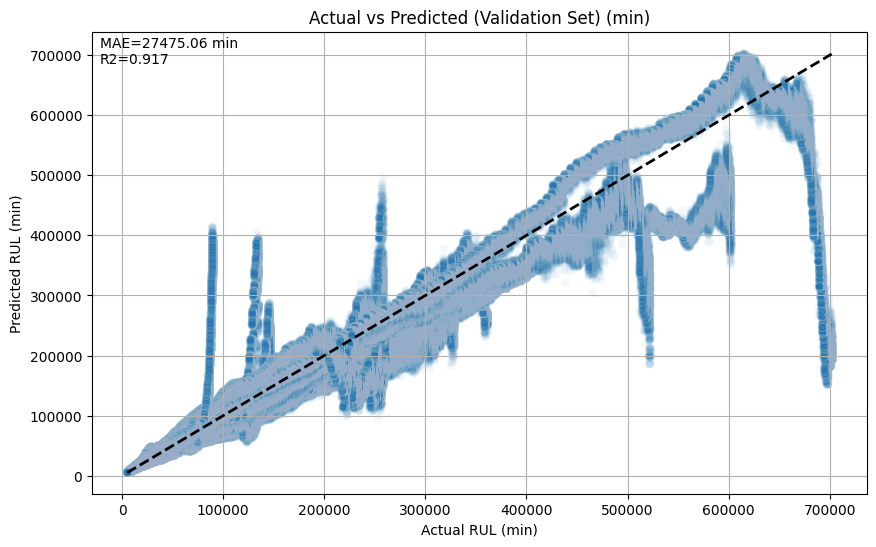

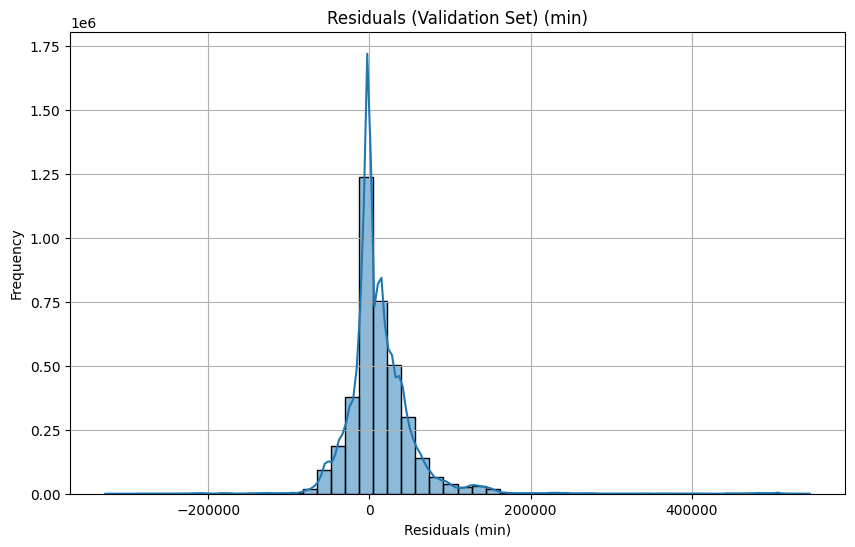

Actual vs Predicted (Test Set) - MAE: 34446.004 min, R2: 0.886


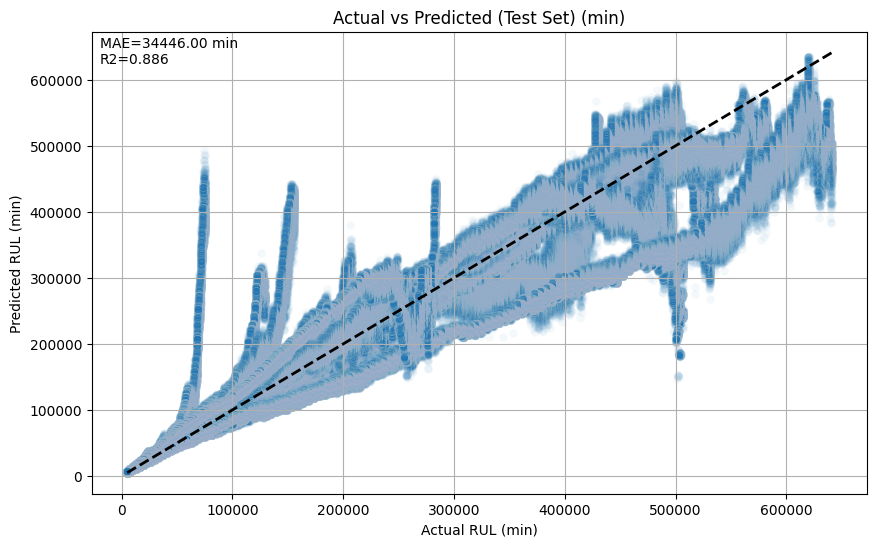

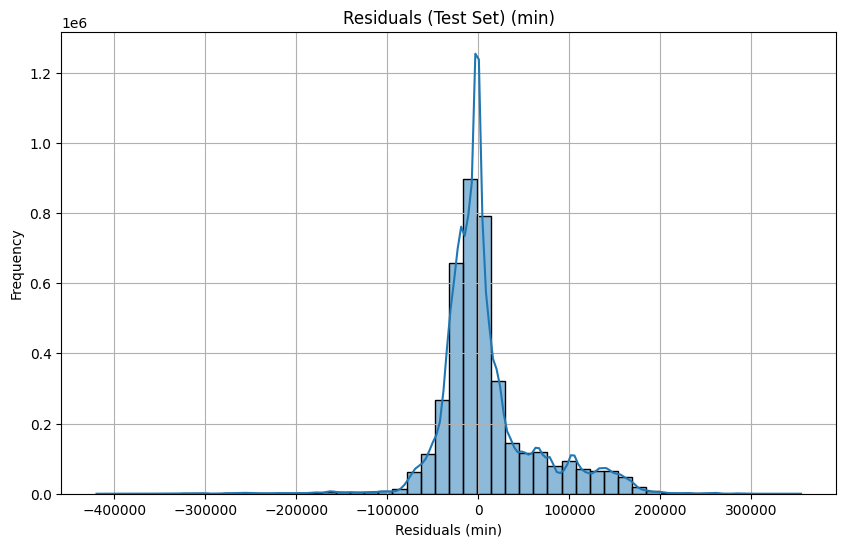

In [21]:
# 7B / Model Visualization - Feature Importance & predictions
print_header("7B/ VISUALIZATION - Feature Importance & Predictions vs True RUL")

# improved helper plotting functions (match notebook's latest conventions)
def plot_actual_vs_predicted(y_true, y_pred, title, unit_label="min"):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    valid = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if valid.sum() == 0:
        print(f"No valid points for {title}")
        return
    y_true, y_pred = y_true[valid], y_pred[valid]

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.05)
    mn, mx = np.nanmin(y_true), np.nanmax(y_true)
    plt.plot([mn, mx], [mn, mx], 'k--', lw=2)
    plt.title(f"{title} ({unit_label})")
    plt.xlabel(f'Actual RUL ({unit_label})')
    plt.ylabel(f'Predicted RUL ({unit_label})')
    plt.grid(True)

    # print and annotate common metrics where available
    try:
        mae = MAE(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        plt.annotate(f"MAE={mae:.2f} {unit_label}\nR2={r2:.3f}", xy=(0.01, 0.99), xycoords='axes fraction', va='top')
        print(f"{title} - MAE: {mae:.3f} {unit_label}, R2: {r2:.3f}")
    except Exception:
        pass

    plt.show()


def plot_residuals(y_true, y_pred, title, unit_label="min"):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    valid = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if valid.sum() == 0:
        print(f"No valid residuals for {title}")
        return
    residuals = y_true[valid] - y_pred[valid]

    plt.figure(figsize=(10, 6))
    sns.histplot(residuals, bins=50, kde=True)
    plt.title(f"{title} ({unit_label})")
    plt.xlabel(f'Residuals ({unit_label})')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

# prepare importance series for comparison
try:
    global_importances = importances.copy()  # XGBoost computed importances across full candidate set
except NameError:
    print("Warning: 'importances' not found in namespace. Skipping importance plots.")
    global_importances = pd.Series(dtype=float)

if not global_importances.empty:
    global_normalized = global_importances / global_importances.sum()

    base_model_importances = global_importances.reindex(base_model_features).fillna(0)
    base_sum = base_model_importances.sum()
    if base_sum > 0:
        base_normalized = base_model_importances / base_sum
    else:
        base_normalized = base_model_importances

    # quick text diagnostics
    print("Top global importances (first 15):")
    print(global_importances.head(15))
    absent_top_global = [f for f in global_importances.head(10).index if f not in base_model_features]
    print("\nGlobal top features missing in base model features:")
    print(absent_top_global)
    print("\nTop base model features after reindexing and normalization (first 15):")
    print(base_normalized.sort_values(ascending=False).head(15))


# show predictions and residuals (guarded in case predictions/true arrays are not defined)
for desc, y_true, y_pred in [
                                ("Validation Set", globals().get('y_val_true_min'), globals().get('val_pred_min')),
                                ("Test Set", globals().get('y_test_true_min'), globals().get('test_pred_min')),
                            ]:
    if y_true is None or y_pred is None:
        print(f"Skipping {desc} plots because required arrays are missing.")
    else:
        plot_actual_vs_predicted(y_true, y_pred, f'Actual vs Predicted ({desc})', unit_label="min")
        plot_residuals(y_true, y_pred, f'Residuals ({desc})', unit_label="min")


## 8) Two Stage Models

### 8.1) STAGE 1 - Critical Region Classification

In [22]:

# 8.1A/ Re-loading datasets training stage1 - Removed previously due to memory constraints
print_header("8.1A/ RE-LOADING DATASETS, SPLITTING, AND ENGINEERING FOR STAGE-1 TRAINING")

print("Loading Long-Life dataset...")
df_long_life = load_datasets(long_life_csv_path)

short_life_csv_path = "synthetic_hydraulic_press_data_short_life.csv"
print("Loading Short-Life dataset...")
df_short_life = load_datasets(short_life_csv_path)

print("Loading Complete...")

# Split Short-Life dataset
print("--- Short-Life Dataset Split")
df_train_short, df_val_short, df_test_short = split_by_cycles(df_short_life)

print("\n" + "=" * 70)

# Split Long-Life dataset
print("\n--- Long-Life Dataset Split")
df_train_long, df_val_long, df_test_long = split_by_cycles(df_long_life)
print("Split complete...")

def engineer_features(df):
    res = engineer_features_streaming(df)
    gc.collect()
    return res

print("\nProcessing SHORT LIFE Dataset...")
df_train_short = engineer_features(df_train_short)
df_val_short   = engineer_features(df_val_short)
df_test_short  = engineer_features(df_test_short)

print("\nProcessing LONG LIFE Dataset...")
df_train_long = engineer_features(df_train_long)
df_val_long   = engineer_features(df_val_long)
df_test_long  = engineer_features(df_test_long)

print_footer("DATASETS RE-LOADED, SPLIT, ENGINEERED FOR STAGE-1 TRAINING")


8.1A/ RE-LOADING DATASETS, SPLITTING, AND ENGINEERING FOR STAGE-1 TRAINING
Loading Long-Life dataset...
Loading Short-Life dataset...
Loading Complete...
--- Short-Life Dataset Split
Total cycles: 200
Train cycles (140): [153, 27, 116, 47, 39]...
Val cycles (30): [2, 43, 123, 18, 183]...
Test cycles (30): [45, 185, 35, 31, 59]...

Row counts:
  Train: 344,084 rows
  Val: 62,864 rows
  Test: 61,821 rows


--- Long-Life Dataset Split
Total cycles: 80
Train cycles (56): [34, 52, 41, 29, 62]...
Val cycles (12): [69, 75, 55, 50, 7]...
Test cycles (12): [36, 65, 48, 13, 54]...

Row counts:
  Train: 17,105,638 rows
  Val: 4,598,831 rows
  Test: 3,751,887 rows
Split complete...

Processing SHORT LIFE Dataset...
  Computing expanding window degradation features (polars streaming)...
  Computing trend slope features (polars vectorized)...
  Computing expanding window degradation features (polars streaming)...
  Computing trend slope features (polars vectorized)...
  Computing expanding window d

In [23]:
# 8/ Stage-1 Critical Region Classification
print_header("8/ STAGE-1 CRITICAL REGION CLASSIFICATION")

# Stage-1 threshold: boundary between NON_CRITICAL and CRITICAL
# Based on architecture: CRITICAL regime starts at RUL <= 600 minutes
STAGE1_THRESHOLD_MIN = 600

print("Purpose: Detect transition to CRITICAL regime (action required)")
print(f"Stage-1 threshold: RUL <= {STAGE1_THRESHOLD_MIN} minutes -> CRITICAL (1)")

# Preconditions
assert 'df_train_short' in globals(), "df_train_short not found"
assert 'df_val_short' in globals(), "df_val_short not found"
assert 'df_test_short' in globals(), "df_test_short not found"

print("Combining short-life and long-life datasets for Stage-1...")

# Short-life samples (RUL ≤ 5000)
X_train_stage1_short = X_train_short.copy()
y_train_stage1_short = (y_train_short <= 600).astype(int)

X_val_stage1_short = X_val_short.copy()
y_val_stage1_short = (y_val_short <= 600).astype(int)

# Long-life samples in 1500-5000 range as EXPLICIT NEGATIVES
long_near_term_mask = (y_train_long >= 1500) & (y_train_long <= 5000)
X_train_stage1_long = df_train_long[long_near_term_mask][selected_features].copy()
y_train_stage1_long = pd.Series(0, index=X_train_stage1_long.index)  # All NON_CRITICAL

# Combine
X_train_stage1 = pd.concat([X_train_stage1_short, X_train_stage1_long], ignore_index=True)
y_train_stage1 = pd.concat([y_train_stage1_short, y_train_stage1_long], ignore_index=True)

# Build validation long-life explicit negatives (match training composition)
long_near_term_mask_val = (y_val_long >= 1500) & (y_val_long <= 5000)
X_val_stage1_long = df_val_long[long_near_term_mask_val][selected_features].copy()
y_val_stage1_long = pd.Series(0, index=X_val_stage1_long.index)

# Combine validation short + long explicit negatives
X_val_stage1 = pd.concat([X_val_stage1_short, X_val_stage1_long], ignore_index=True)
y_val_stage1 = pd.concat([y_val_stage1_short, y_val_stage1_long], ignore_index=True)

print(f"Enhanced training set:")
print(f"  Total samples: {len(X_train_stage1):,}")
print(f"  From short-life: {len(X_train_stage1_short):,}")
print(f"  From long-life (explicit negatives): {len(X_train_stage1_long):,}")
print(f"  CRITICAL: {y_train_stage1.sum():,} ({y_train_stage1.mean()*100:.1f}%)")

# Train with precision focus
stage1_model = XGBClassifier(
                                n_estimators=600,  # More trees for better separation
                                max_depth=6,
                                learning_rate=0.02,  # Lower LR for precision
                                subsample=0.8,
                                colsample_bytree=0.8,
                                scale_pos_weight=3.0,  # Balanced
                                objective="binary:logistic",
                                eval_metric=["auc", "aucpr"],  # Add precision-recall AUC
                                random_state=42,
                                n_jobs=4,
                                verbosity=1
                            )

# Custom eval metric for precision target
from xgboost import callback
import xgboost as xgb
from sklearn.metrics import precision_score

class PrecisionCallback(callback.TrainingCallback):
    def __init__(self, target_precision=0.70, validation_data=None):
        self.target_precision = target_precision
        self.dval = xgb.DMatrix(validation_data[0], label=validation_data[1])
        self.y_true = validation_data[1]
        
    def after_iteration(self, model, epoch, evals_log):
        if epoch % 50 == 0:
            # Check precision on validation
            y_prob = model.predict(self.dval)
            y_pred = (y_prob >= 0.5).astype(int)

            prec = precision_score(self.y_true, y_pred)
            print(f"   [Precision Check] Epoch {epoch}: {prec*100:.1f}%")
        return False

stage1_model.fit(
                    X_train_stage1,
                    y_train_stage1,
                    eval_set=[(X_val_stage1, y_val_stage1)],
                    callbacks=[PrecisionCallback(target_precision=0.70, validation_data=(X_val_stage1, y_val_stage1))],
                    verbose=100,
                )

# Evaluate with precision focus
y_val_pred = stage1_model.predict(X_val_stage1)
y_val_prob = predict_proba_in_batches(stage1_model, X_val_stage1)

from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_val_stage1, y_val_prob)

# Find threshold that gives ~70% precision
target_precision_idx = np.argmax(precisions >= 0.70)
optimal_threshold = thresholds[target_precision_idx]

print(f"\nOptimal threshold for 70% precision: {optimal_threshold:.3f}")
print(f"   At this threshold:")
print(f"     Precision: {precisions[target_precision_idx]*100:.1f}%")
print(f"     Recall: {recalls[target_precision_idx]*100:.1f}%")

# Save with optimal threshold
joblib.dump(stage1_model, os.path.join(save_path, "hydraulic_press_stage1_classifier.pkl"))

config = {
            "threshold_min": 600,
            "optimal_prob_threshold": float(optimal_threshold),
            "target_precision": 0.70,
            "trained_with_explicit_negatives": True
        }

with open(os.path.join(save_path, "hydraulic_press_stage1_config.json"), "w") as f:
    json.dump(config, f, indent=4)

print_footer("STAGE-1 CLASSIFICATION TRAINING COMPLETE")


8/ STAGE-1 CRITICAL REGION CLASSIFICATION
Purpose: Detect transition to CRITICAL regime (action required)
Stage-1 threshold: RUL <= 600 minutes -> CRITICAL (1)
Combining short-life and long-life datasets for Stage-1...
Enhanced training set:
  Total samples: 540,140
  From short-life: 344,084
  From long-life (explicit negatives): 196,056
  CRITICAL: 80,035 (14.8%)
[0]	validation_0-auc:0.99347	validation_0-aucpr:0.97795
   [Precision Check] Epoch 0: 0.0%
   [Precision Check] Epoch 50: 96.5%
[100]	validation_0-auc:0.99708	validation_0-aucpr:0.98901
   [Precision Check] Epoch 100: 95.5%
   [Precision Check] Epoch 150: 95.6%
[200]	validation_0-auc:0.99738	validation_0-aucpr:0.99011
   [Precision Check] Epoch 200: 95.7%
   [Precision Check] Epoch 250: 95.8%
[300]	validation_0-auc:0.99758	validation_0-aucpr:0.99075
   [Precision Check] Epoch 300: 95.9%
   [Precision Check] Epoch 350: 95.8%
[400]	validation_0-auc:0.99759	validation_0-aucpr:0.99073
   [Precision Check] Epoch 400: 95.4%
   [P

### 8.2) STAGE 2A - Critical Regression

In [ ]:
# 8A/ Stage-2A Critical RUL Regression - Narrow Focus + Mix Dataset
print_header("8A/ STAGE-2A CRITICAL RUL REGRESSION - FOCUS ON 0-1000 min & MIXED DATASET")

# Preconditions
assert 'df_train_short' in globals(), "df_train_short not found"
assert 'df_val_short' in globals(), "df_val_short not found"
assert 'df_test_short' in globals(), "df_test_short not found"
assert 'selected_features' in globals(), "selected_features not found"

# Stage-2A operating range: RUL <= 5000 min (aligned with NEAR_TERM threshold)
# Critical focus: High accuracy for RUL <= 1500 min, best accuracy for RUL <= 600 min
STAGE2A_MAX_RUL_MIN = 1000

print("Using BOTH short-life and long-life datasets for Stage-2A...")
print("  Reason: Long-life features differ significantly at cycle end")
print("Purpose: High-resolution RUL prediction in NEAR_TERM/CRITICAL regime")
print(f"Stage-2A operating range: RUL <= {STAGE2A_MAX_RUL_MIN} minutes")
print(f"Critical focus: RUL <= 1500 min (high accuracy), RUL <= 600 min (best accuracy)")

print("\nFiltering samples for Stage-2A...")

def filter_stage2a_samples(df, y_values, max_rul=STAGE2A_MAX_RUL_MIN):
    mask = y_values <= max_rul
    return df[mask].copy(), y_values[mask].copy()

X_train_stage2a_short, y_train_stage2a_short = filter_stage2a_samples(X_train_short, y_train_short)
X_val_stage2a_short, y_val_stage2a_short = filter_stage2a_samples(X_val_short, y_val_short)

# Long-life samples (RUL ≤ 1000) - CRITICAL ADDITION!
long_critical_mask_train = y_train_long <= STAGE2A_MAX_RUL_MIN
long_critical_mask_val = y_val_long <= STAGE2A_MAX_RUL_MIN

X_train_stage2a_long = df_train_long[long_critical_mask_train][selected_features].copy()
y_train_stage2a_long = y_train_long[long_critical_mask_train].copy()

X_val_stage2a_long = df_val_long[long_critical_mask_val][selected_features].copy()
y_val_stage2a_long = y_val_long[long_critical_mask_val].copy()

# Combine datasets
X_train_stage2a = pd.concat([X_train_stage2a_short, X_train_stage2a_long], ignore_index=True)
y_train_stage2a_raw = pd.concat([y_train_stage2a_short, y_train_stage2a_long], ignore_index=True)

X_val_stage2a = pd.concat([X_val_stage2a_short, X_val_stage2a_long], ignore_index=True)
y_val_stage2a_raw = pd.concat([y_val_stage2a_short, y_val_stage2a_long], ignore_index=True)

print(f"\nEnhanced Stage-2A training set:")
print(f"  Total training samples: {len(X_train_stage2a):,}")
print(f"    From short-life: {len(X_train_stage2a_short):,}")
print(f"    From long-life: {len(X_train_stage2a_long):,}")
print(f"  Total validation samples: {len(X_val_stage2a):,}")
print(f"    From short-life: {len(X_val_stage2a_short):,}")
print(f"    From long-life: {len(X_val_stage2a_long):,}")

# Prepare test set
y_test_long  = df_test_long['current_rul']
long_critical_mask_test = y_test_long <= STAGE2A_MAX_RUL_MIN
X_test_stage2a_short, y_test_stage2a_short = filter_stage2a_samples(X_test_short, y_test_short)
X_test_stage2a_long = df_test_long[long_critical_mask_test][selected_features].copy()
y_test_stage2a_long = y_test_long[long_critical_mask_test].copy()

X_test_stage2a = pd.concat([X_test_stage2a_short, X_test_stage2a_long], ignore_index=True)
y_test_stage2a_raw = pd.concat([y_test_stage2a_short, y_test_stage2a_long], ignore_index=True)

# Also keep df subsets for cycle_id access later
# Keep short and long parts and concatenate so row counts align with X_*_stage2a
df_train_stage2a_short = df_train_short[y_train_short <= STAGE2A_MAX_RUL_MIN].copy()
df_train_stage2a_long = df_train_long[long_critical_mask_train].copy()
df_train_stage2a = pd.concat([df_train_stage2a_short, df_train_stage2a_long], ignore_index=True)

df_val_stage2a_short = df_val_short[y_val_short <= STAGE2A_MAX_RUL_MIN].copy()
df_val_stage2a_long = df_val_long[long_critical_mask_val].copy()
df_val_stage2a = pd.concat([df_val_stage2a_short, df_val_stage2a_long], ignore_index=True)

df_test_stage2a_short = df_test_short[y_test_short <= STAGE2A_MAX_RUL_MIN].copy()
df_test_stage2a_long = df_test_long[long_critical_mask_test].copy()
df_test_stage2a = pd.concat([df_test_stage2a_short, df_test_stage2a_long], ignore_index=True)

assert len(X_train_stage2a) > 0, "No training samples in Stage-2A range"
assert len(X_val_stage2a) > 0, "No validation samples in Stage-2A range"
assert len(X_test_stage2a) > 0, "No test samples in Stage-2A range"

print("Stage-2A dataset shapes:")
print(f"  Train: {X_train_stage2a.shape}")
print(f"  Val  : {X_val_stage2a.shape}")
print(f"  Test : {X_test_stage2a.shape}")

# DEBUG: Check RUL distribution in Stage-2A data
print(f"\n[TEMP:DEBUG] Stage-2A train RUL range: {y_train_stage2a_raw.min()} - {y_train_stage2a_raw.max()}")
print(f"[TEMP:DEBUG] Samples with RUL <= 600: {(y_train_stage2a_raw <= 600).sum()}")
print(f"[TEMP:DEBUG] Samples with RUL <= 300: {(y_train_stage2a_raw <= 300).sum()}")
print(f"[TEMP:DEBUG] Samples with RUL <= 100: {(y_train_stage2a_raw <= 100).sum()}")

print("\nUsing ALL selected features for Stage-2A...")
print("  Reason: More features provide better context for accurate predictions")

# Use all selected features (not just a subset)
stage2a_features = selected_features.copy()
print(f"  Feature count: {len(stage2a_features)}")

X_train_stage2a = X_train_stage2a[stage2a_features]
X_val_stage2a   = X_val_stage2a[stage2a_features]
X_test_stage2a  = X_test_stage2a[stage2a_features]

# Target transformation: log1p for stable learning
print("\nTransforming targets to log-space...")
y_train_stage2a = np.log1p(y_train_stage2a_raw.values)
y_val_stage2a   = np.log1p(y_val_stage2a_raw.values)
y_test_stage2a  = np.log1p(y_test_stage2a_raw.values)

print("Computing decision-aligned sample weights...")
print("  Higher weight for samples closer to failure (RUL -> 0)")
print("  Weight range: 5.0 - 20.0")

def compute_severity_weights(rul_values):
    """
    Ultra-critical (0-300): 20x weight
    Critical (300-600): 10x weight
    Near-critical (600-1000): 5x weight
    """
    weights = np.ones(len(rul_values), dtype='float32')
    
    ultra_mask = rul_values <= 300
    critical_mask = (rul_values > 300) & (rul_values <= 600)
    near_mask = (rul_values > 600) & (rul_values <= 1000)
    
    weights[ultra_mask] = 20.0
    weights[critical_mask] = 10.0
    weights[near_mask] = 5.0
    
    return weights

train_weights = compute_severity_weights(y_train_stage2a_raw.values)
val_weights = compute_severity_weights(y_val_stage2a_raw.values)

print(f"\nWeight distribution:")
print(f"  Ultra-critical (0-300): {(y_train_stage2a_raw <= 300).sum():,} samples, weight=20x")
print(f"  Critical (300-600): {((y_train_stage2a_raw > 300) & (y_train_stage2a_raw <= 600)).sum():,} samples, weight=10x")
print(f"  Near-critical (600-1000): {(y_train_stage2a_raw > 600).sum():,} samples, weight=5x")


assert len(train_weights) == len(y_train_stage2a)
assert len(val_weights) == len(y_val_stage2a)

print("\nTraining weighted Stage-2A regressor...")

# Build monotonic constraints for degradation-related features
monotone_constraints = []
for feat in stage2a_features:
    # Features that should increase with degradation (negative correlation with RUL)
    if any(kw in feat for kw in ['vibration', 'temperature', 'contamination', 'current', 'degradation']):
        if 'pressure' not in feat:  # pressure decreases with degradation
            monotone_constraints.append(-1)
        else:
            monotone_constraints.append(0)
    # Features that should decrease with degradation (positive correlation with RUL)
    elif any(kw in feat for kw in ['pressure', 'force', 'flow']):
        if 'ratio' not in feat and 'coupling' not in feat:
            monotone_constraints.append(1)
        else:
            monotone_constraints.append(0)
    else:
        monotone_constraints.append(0)

n_monotonic = sum(1 for x in monotone_constraints if x != 0)
print(f"  Monotonic constraints applied: {n_monotonic} features")

stage2a_model = XGBRegressor(
                                n_estimators=800,
                                max_depth=5,
                                learning_rate=0.02,
                                subsample=0.85,
                                colsample_bytree=0.85,
                                min_child_weight=3,
                                reg_alpha=0.3,
                                reg_lambda=1.5,
                                objective="reg:squarederror",
                                random_state=42,
                                n_jobs=4,
                                verbosity=0,
                                monotone_constraints=tuple(monotone_constraints)
                            )

stage2a_model.fit(
                    X_train_stage2a,
                    y_train_stage2a,
                    sample_weight=train_weights,
                    eval_set=[(X_val_stage2a, y_val_stage2a)],
                    sample_weight_eval_set=[val_weights],
                    early_stopping_rounds=100,
                    verbose=False
                )

print(f"  Best iteration: {stage2a_model.best_iteration}")
print("Evaluating Stage-2A regressor...")

# Predictions in log-domain, inverse-transform to minutes
val_pred_log = stage2a_model.predict(X_val_stage2a)
val_predictions = np.expm1(val_pred_log)

test_pred_log = stage2a_model.predict(X_test_stage2a)
test_predictions = np.expm1(test_pred_log)

# Decision-aware clipping per cycle
val_window_max = df_val_stage2a.groupby('cycle_id')["current_rul"].transform('max').values
test_window_max = df_test_stage2a.groupby('cycle_id')["current_rul"].transform('max').values

val_predictions = np.clip(val_predictions, 0.0, val_window_max)
test_predictions = np.clip(test_predictions, 0.0, test_window_max)

# Evaluate against raw minute-scale targets
val_mae = MAE(y_val_stage2a_raw, val_predictions)
val_rmse = MSE(y_val_stage2a_raw, val_predictions, squared=False)
val_r2 = r2_score(y_val_stage2a_raw, val_predictions)

test_mae = MAE(y_test_stage2a_raw, test_predictions)
test_rmse = MSE(y_test_stage2a_raw, test_predictions, squared=False)
test_r2 = r2_score(y_test_stage2a_raw, test_predictions)

print("\nValidation Metrics:")
print(f"  MAE  : {val_mae:.2f} min")
print(f"  RMSE : {val_rmse:.2f} min")
print(f"  R2   : {val_r2 * 100:.2f}%")

print("\nTest Metrics:")
print(f"  MAE  : {test_mae:.2f} min")
print(f"  RMSE : {test_rmse:.2f} min")
print(f"  R2   : {test_r2 * 100:.2f}%")

# Critical region analysis
print("\n=== CRITICAL REGION ANALYSIS ===")

critical_thresholds = [
                            (300, "Very Critical (RUL <= 300 min)"),
                            (150, "Extreme Critical (RUL <= 150 min)"),
                            (600, "Approaching Critical (300-600 min)", 300)  # Range check
                        ]

for item in critical_thresholds:
    if len(item) == 2:
        threshold, label = item
        mask = y_test_stage2a_raw <= threshold
    else:
        threshold, label, lower = item
        mask = (y_test_stage2a_raw > lower) & (y_test_stage2a_raw <= threshold)
    
    if mask.sum() > 0:
        region_mae = MAE(y_test_stage2a_raw[mask], test_predictions[mask])
        region_r2 = r2_score(y_test_stage2a_raw[mask], test_predictions[mask])
        print(f"{label}: {mask.sum()} samples")
        print(f"  MAE: {region_mae:.2f} min | R2: {region_r2*100:.1f}%")

# Save model
joblib_path = os.path.join(save_path, "hydraulic_press_stage2a_regressor.pkl")
joblib.dump(stage2a_model, joblib_path, compress=('lz4', 3))  
print(f"\nModel saved (joblib): {joblib_path}")

config = {
            "max_rul_min": STAGE2A_MAX_RUL_MIN,
            "target_mae_min": 40,
            "severity_weights": {"ultra": 20, "critical": 10, "near": 5},
        }

with open(os.path.join(save_path, "hydraulic_press_stage2a_config.json"), "w") as f:
    json.dump(config, f, indent=4)

print_footer("STAGE-2A CRITICAL RUL REGRESSION COMPLETE")



8A/ STAGE-2A CRITICAL RUL REGRESSION - FOCUS ON 0-1000 min & MIXED DATASET
Using BOTH short-life and long-life datasets for Stage-2A...
  Reason: Long-life features differ significantly at cycle end
Purpose: High-resolution RUL prediction in NEAR_TERM/CRITICAL regime
Stage-2A operating range: RUL <= 1000 minutes
Critical focus: RUL <= 1500 min (high accuracy), RUL <= 600 min (best accuracy)

Filtering samples for Stage-2A...

Enhanced Stage-2A training set:
  Total training samples: 182,858
    From short-life: 126,802
    From long-life: 56,056
  Total validation samples: 39,760
    From short-life: 27,748
    From long-life: 12,012
Stage-2A dataset shapes:
  Train: (182858, 29)
  Val  : (39760, 29)
  Test : (36934, 29)

[TEMP:DEBUG] Stage-2A train RUL range: 0 - 1000
[TEMP:DEBUG] Samples with RUL <= 600: 113691
[TEMP:DEBUG] Samples with RUL <= 300: 58361
[TEMP:DEBUG] Samples with RUL <= 100: 19796

Using ALL selected features for Stage-2A...
  Reason: More features provide better co

ValueError: operands could not be broadcast together with shapes (39760,) () (27748,) 

## 9) Two Stage Inference & Evaluation

In [ ]:
# 9A/ Memory Cleanup Before Final Evaluations
print_header("9A/ MEMORY CLEANUP BEFORE Final Evaluations")

try:
    import psutil, os, gc, time
    proc = psutil.Process(os.getpid())
    mem_before_mb = proc.memory_info().rss / (1024**2)
    print(f"[MEM] Process RSS before cleanup: {mem_before_mb:.1f} MB")
except Exception as e:
    print('[MEM] psutil not available, falling back to resource (approx).')
    try:
        import resource, os, gc, time
        mem_before_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024.0
        print(f"[MEM] ru_maxrss before cleanup (MB): {mem_before_mb:.1f}")
    except Exception:
        mem_before_mb = None

# listed all the variables via %whos and then removed the ones not needed for future steps for memory reasons - otherwise RAM (23.5G + 6G swap) was being exhausted and wsl was crushing. 

vars_to_delete = [
                    'df_train_long','df_val_long','df_test_long', 'df_long_life', 'X_train_norm','cycle_id_base',
                    'X_test_long', 'X_test_stage0','X_test_base','X_test_norm','X_val_base','X_val_norm',
                    'df_train_short','y_train_base_hr','y_train_norm','y_train_hr','y_train_long', ]

deleted = []
not_found = []
for name in vars_to_delete:
    if name in globals():
        try:
            del globals()[name]
            deleted.append(name)
        except Exception:
            not_found.append(name)
    else:
        not_found.append(name)

# cleanup call
gc.collect()
time.sleep(0.1)

try:
    proc = psutil.Process(os.getpid())
    mem_after_mb = proc.memory_info().rss / (1024**2)
    print(f"[MEM] Process RSS after cleanup : {mem_after_mb:.1f} MB")
    if mem_before_mb is not None:
        print(f"[MEM] Freed approximately     : {max(0.0, mem_before_mb - mem_after_mb):.1f} MB")
except Exception:
    try:
        import resource
        mem_after_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024.0
        print(f"[MEM] ru_maxrss after cleanup (MB): {mem_after_mb:.1f}")
        if mem_before_mb is not None:
            print(f"[MEM] Freed approximately: {max(0.0, mem_before_mb - mem_after_mb):.1f} MB")
    except Exception:
        print('[MEM] Could not determine memory after cleanup.')

# Raport
print('\nCleanup summary:')
print(f'  Deleted variables  : {len(deleted)}')
if deleted:
    print('    ' + ', '.join(deleted))
print(f'  Not found / skipped  : {len(not_found)}')
if not_found:
    print('    ' + ', '.join(not_found))

print_footer("MEMORY CLEANUP COMPLETE")




In [ ]:
# ======================================================================
# PRODUCTION PIPELINE INFERENCE
# ======================================================================
print_header("PRODUCTION PIPELINE INFERENCE - Full System Integration")

print("""
Purpose: Demonstrate end-to-end inference flow through the complete pipeline:
  1. Load a single representative cycle from long-life dataset
  2. Apply cycle-baseline normalization (exactly as in training)
  3. Route samples through Stage-0 → Base Model OR Stage-1 → Stage-2A
  4. Visualize predictions across all RUL regimes with regime boundaries
""")

# ======================================================================
# STEP 1: Load a Representative Cycle
# ======================================================================
print("\n" + "="*70)
print("STEP 1: Loading Representative Cycle")
print("="*70)

print("\nScanning cycles in long-life dataset...")
# Read only cycle_id and RUL to find suitable cycle
cycle_info = pd.read_csv(
    long_life_csv_path,
    usecols=['cycle_id', 'current_rul'],
    dtype={'cycle_id': 'int32', 'current_rul': 'int32'}
)

# Find cycle statistics
cycle_stats = cycle_info.groupby('cycle_id').agg({
    'current_rul': ['min', 'max', 'count']
}).reset_index()
cycle_stats.columns = ['cycle_id', 'min_rul', 'max_rul', 'sample_count']

print(f"Total cycles available: {len(cycle_stats)}")
print(f"\nCycle RUL range statistics:")
print(f"  Min RUL across cycles: {cycle_stats['min_rul'].min()} - {cycle_stats['min_rul'].max()}")
print(f"  Max RUL across cycles: {cycle_stats['max_rul'].min()} - {cycle_stats['max_rul'].max()}")

# Select a cycle that covers the full degradation range (max RUL close to dataset max)
ideal_cycle = cycle_stats.loc[cycle_stats['max_rul'].idxmax()]
selected_cycle_id = int(ideal_cycle['cycle_id'])

print(f"\nSelected cycle_id: {selected_cycle_id}")
print(f"  RUL range: {ideal_cycle['min_rul']:.0f} - {ideal_cycle['max_rul']:.0f} minutes")
print(f"  Total samples: {ideal_cycle['sample_count']:.0f}")
print(f"  Coverage: {ideal_cycle['max_rul']/60:.1f} hours ({ideal_cycle['max_rul']/1440:.1f} days)")

del cycle_info, cycle_stats, ideal_cycle
gc.collect()

# ======================================================================
# STEP 2: Load Full Cycle Data (Raw Sensors + Engineered Features)
# ======================================================================
print("\n" + "="*70)
print("STEP 2: Loading Cycle Data")
print("="*70)

print(f"\nLoading cycle {selected_cycle_id} from CSV...")

# Load raw sensor data for normalization + all needed columns
cols_to_load = ['cycle_id', 'time_min', 'current_rul'] + NORMALIZE_SENSORS

df_inference_raw = pd.read_csv(
    long_life_csv_path,
    usecols=cols_to_load,
    dtype={
        'cycle_id': 'int32', 
        'time_min': 'int32', 
        'current_rul': 'int32',
        **{s: 'float32' for s in NORMALIZE_SENSORS}
    }
)

df_inference_raw = df_inference_raw[df_inference_raw['cycle_id'] == selected_cycle_id].copy().reset_index(drop=True)

print(f"  Loaded {len(df_inference_raw):,} samples")
print(f"  Memory usage: {df_inference_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  RUL range: {df_inference_raw['current_rul'].min()} - {df_inference_raw['current_rul'].max()} min")

# ======================================================================
# STEP 3: Cycle-Baseline Normalization (EXACTLY as in Training)
# ======================================================================
print("\n" + "="*70)
print("STEP 3: Applying Cycle-Baseline Normalization")
print("="*70)

print("Loading GLOBAL baseline from training config...")

with open(os.path.join(save_path, "hydraulic_press_base_model_config.json"), "r") as f:
    base_config = json.load(f)
    global_baseline = pd.Series(base_config["global_baseline"])

print("\nGlobal baseline values (from training):")
for sensor in NORMALIZE_SENSORS:
    print(f"  {sensor}: {global_baseline[sensor]:.3f}")

# Normalize sensors with GLOBAL baseline
print("\n--- Normalizing sensors with global baseline ---")
for sensor in NORMALIZE_SENSORS:
    norm_col = f'{sensor}_norm'
    baseline_val = global_baseline[sensor]
    eps = 1e-6
    
    df_inference_raw[norm_col] = (
        (df_inference_raw[sensor] - baseline_val) / (abs(baseline_val) + eps)
    ).astype('float32')
    
    print(f"  {norm_col}: min={df_inference_raw[norm_col].min():.3f}, max={df_inference_raw[norm_col].max():.3f}")


# ======================================================================
# STEP 4: Create Normalized Features (EXACTLY as in Training)
# ======================================================================
print("\n" + "="*70)
print("STEP 4: Creating Normalized Features")
print("="*70)

# Composite degradation score - EXACTLY as in training
degradation_sensors_pos = ['vibration_norm', 'oil_temperature_norm', 'oil_contamination_norm', 'motor_current_norm']
degradation_sensors_neg = ['hydraulic_pressure_norm', 'press_force_norm', 'flow_rate_norm']

pos_sum = df_inference_raw[[s for s in degradation_sensors_pos if s in df_inference_raw.columns]].sum(axis=1)
neg_sum = -df_inference_raw[[s for s in degradation_sensors_neg if s in df_inference_raw.columns]].sum(axis=1)

df_inference_raw['normalized_degradation'] = ((pos_sum + neg_sum) / 7.0).astype('float32')

print(f"  normalized_degradation: min={df_inference_raw['normalized_degradation'].min():.3f}, max={df_inference_raw['normalized_degradation'].max():.3f}")

# Time position within cycle - EXACTLY as in training
cycle_max_time = df_inference_raw['time_min'].max()
df_inference_raw['time_position'] = (df_inference_raw['time_min'] / (cycle_max_time + 1)).astype('float32')

print(f"  time_position: min={df_inference_raw['time_position'].min():.3f}, max={df_inference_raw['time_position'].max():.3f}")

# Feature columns for Base Model - EXACTLY as in training
norm_feature_cols = [f'{s}_norm' for s in NORMALIZE_SENSORS] + ['normalized_degradation', 'time_position']

print(f"\nBase Model features ({len(norm_feature_cols)}): {norm_feature_cols}")

del pos_sum, neg_sum
gc.collect()

# ======================================================================
# STEP 5: Apply Standard Feature Engineering for Stage-0/1/2A
# ======================================================================
print("\n" + "="*70)
print("STEP 5: Applying Standard Feature Engineering for Classifiers")
print("="*70)

dtype_mapping = {
                    'cycle_id': 'int32',
                    'time_min': 'int32',
                    'total_rul': 'int32',
                    'current_rul': 'int32',
                    'hydraulic_pressure': 'float32',
                    'oil_temperature': 'float32',
                    'oil_contamination': 'float32',
                    'ram_position_deviation': 'float32',
                    'press_force': 'float32',
                    'vibration': 'float32',
                    'flow_rate': 'float32',
                    'motor_current': 'float32'
                }

# Load full dataset with all sensors for standard feature engineering
df_inference_full = pd.read_csv(
    long_life_csv_path,
    dtype=dtype_mapping
)
df_inference_full = df_inference_full[df_inference_full['cycle_id'] == selected_cycle_id].copy().reset_index(drop=True)

print("Computing standard features using streaming approach...")
df_inference_full = engineer_features_streaming(df_inference_full)

print(f"  Features created: {len(df_inference_full.columns) - len(SENSOR_COLUMNS) - 3}")
print(f"  Final shape: {df_inference_full.shape}")

# ======================================================================
# STEP 6: Prepare Feature Matrices
# ======================================================================
print("\n" + "="*70)
print("STEP 6: Preparing Feature Matrices for Models")
print("="*70)

# Stage-0, Stage-1, Stage-2A use standard features
X_inference_classifiers = df_inference_full[selected_features].copy()

# Base Model uses normalized features
X_inference_base = df_inference_raw[norm_feature_cols].copy()

# Store actual RUL for comparison
y_actual = df_inference_full['current_rul'].values

print(f"  Classifier features: {X_inference_classifiers.shape}")
print(f"  Base Model features: {X_inference_base.shape}")
print(f"  Actual RUL range: {y_actual.min():.0f} - {y_actual.max():.0f} minutes")

# Verify alignment
assert len(X_inference_classifiers) == len(X_inference_base), "Feature matrix length mismatch!"
assert len(y_actual) == len(X_inference_base), "RUL length mismatch!"

# ======================================================================
# STEP 7: Run Full Pipeline Inference
# ======================================================================
print("\n" + "="*70)
print("STEP 7: Running Full Pipeline Inference")
print("="*70)

# Initialize prediction arrays
predictions_final = np.zeros(len(df_inference_full))
regime_labels = np.empty(len(df_inference_full), dtype=object)
active_model = np.empty(len(df_inference_full), dtype=object)

# ---- Stage 0: Regime Detection ----
print("\n[Stage-0] Detecting LONG_TERM vs NEAR_TERM regime...")
stage0_probs = predict_proba_in_batches(stage0_model, X_inference_classifiers, batch_size=5000)
stage0_preds = (stage0_probs >= 0.7).astype(int)

long_term_mask = stage0_preds == 0
near_term_mask = stage0_preds == 1

print(f"  LONG_TERM samples: {long_term_mask.sum():,} ({long_term_mask.mean()*100:.1f}%)")
print(f"  NEAR_TERM samples: {near_term_mask.sum():,} ({near_term_mask.mean()*100:.1f}%)")

# ---- Base Model: For LONG_TERM samples ----
if long_term_mask.any():
    print("\n[Base Model] Predicting for LONG_TERM samples...")
    base_preds_log = base_model.predict(X_inference_base[long_term_mask])
    base_preds_hr = np.expm1(base_preds_log)
    base_preds_min = base_preds_hr * 60
    base_preds_min = np.clip(base_preds_min, BASE_MODEL_MIN_RUL_MIN, 720000)
    
    predictions_final[long_term_mask] = base_preds_min
    regime_labels[long_term_mask] = 'LONG_TERM'
    active_model[long_term_mask] = 'Base Model'
    
    print(f"  Predictions: {base_preds_min.min():.0f} - {base_preds_min.max():.0f} min")

# ---- Stage 1: Critical Detection for NEAR_TERM samples ----
if near_term_mask.any():
    print("\n[Stage-1] Detecting CRITICAL regime in NEAR_TERM samples...")
    
    with open(os.path.join(save_path, "hydraulic_press_stage1_config.json"), "r") as f:
        stage1_config = json.load(f)
        optimal_threshold = stage1_config["optimal_prob_threshold"]
    
    print(f"  Using optimal threshold: {optimal_threshold:.3f} (precision target: 70%)")
    
    stage1_probs = predict_proba_in_batches(
        stage1_model, 
        X_inference_classifiers[near_term_mask], 
        batch_size=5000
    )
    
    stage1_preds = (stage1_probs >= optimal_threshold).astype(int)
    
    # Create masks relative to full dataset
    non_critical_global = near_term_mask.copy()
    critical_global = near_term_mask.copy()
    
    non_critical_global[near_term_mask] = stage1_preds == 0
    critical_global[near_term_mask] = stage1_preds == 1
    
    print(f"  NON_CRITICAL samples: {non_critical_global.sum():,}")
    print(f"  CRITICAL samples: {critical_global.sum():,}")
    
    # ---- Base Model: For NON_CRITICAL samples ----
    if non_critical_global.any():
        print("\n[Base Model] Predicting for NON_CRITICAL samples...")
        base_preds_log = base_model.predict(X_inference_base[non_critical_global])
        base_preds_hr = np.expm1(base_preds_log)
        base_preds_min = base_preds_hr * 60
        base_preds_min = np.clip(base_preds_min, BASE_MODEL_MIN_RUL_MIN, 720000)
        
        predictions_final[non_critical_global] = base_preds_min
        regime_labels[non_critical_global] = 'NEAR_TERM'
        active_model[non_critical_global] = 'Base Model'
        
        print(f"  Predictions: {base_preds_min.min():.0f} - {base_preds_min.max():.0f} min")
    
    # ---- Stage 2A: For CRITICAL samples ----
    if critical_global.any():
        print("\n[Stage-2A] High-resolution prediction for CRITICAL samples...")
        stage2a_preds_log = stage2a_model.predict(X_inference_classifiers[critical_global])
        stage2a_preds_min = np.expm1(stage2a_preds_log)
        stage2a_preds_min = np.clip(stage2a_preds_min, 0, STAGE2A_MAX_RUL_MIN)
        
        predictions_final[critical_global] = stage2a_preds_min
        regime_labels[critical_global] = 'CRITICAL'
        active_model[critical_global] = 'Stage-2A'
        
        print(f"  Predictions: {stage2a_preds_min.min():.0f} - {stage2a_preds_min.max():.0f} min")

# ======================================================================
# STEP 8: Visualization - Regime-Based Prediction Quality
# ======================================================================
print("\n" + "="*70)
print("STEP 8: Visualizing Pipeline Behavior Across Regimes")
print("="*70)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 1, figsize=(18, 14))

# ---- Plot 1: Full Prediction View with Regime Boundaries ----
ax1 = axes[0]

# Define regime boundaries and colors (matching your table)
regime_boundaries = [
    (20000, 720000, 'LONG_TERM\n(Stage-0=0, Base Model)', '#E8F4F8', 'Monitoring'),
    (10000, 20000, 'Healthy Long-Term\n(Stage-0=0, Base Model)', '#D6EAF8', 'Planning'),
    (5000, 10000, 'NEAR_TERM - Healthy\n(Stage-0=1, Stage-1=0, Base Model)', '#FFF4E6', 'Preparation'),
    (1500, 5000, 'NEAR_TERM - Approaching Critical\n(Stage-0=1, Stage-1=0, Base Model)', '#FFE5CC', 'Pre-Alert'),
    (600, 1500, 'NEAR_TERM - Pre-Critical\n(Stage-0=1, Stage-1=0, Base Model)', '#FFD9B3', 'Alert'),
    (300, 600, 'CRITICAL - Transition\n(Stage-0=1, Stage-1=1, Stage-2A)', '#FFCCCC', 'Action Required'),
    (0, 300, 'CRITICAL - Imminent Failure\n(Stage-0=1, Stage-1=1, Stage-2A)', '#FF9999', 'Immediate Action')
]

# Plot regime backgrounds
for i, (low, high, label, color, _) in enumerate(regime_boundaries):
    ax1.axhspan(low, high, alpha=0.12, color=color, zorder=0)
    # Add regime label on the right
    mid_point = (low + high) / 2
    ax1.text(y_actual.max() * 1.01, mid_point, label, 
             fontsize=9, va='center', ha='left',
             bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.4, edgecolor='gray', linewidth=0.5))

# Plot perfect prediction line
ax1.plot([0, y_actual.max()], [0, y_actual.max()], 
         'k--', linewidth=2.5, alpha=0.4, label='Perfect Prediction', zorder=1)

# Plot predictions colored by active model
base_mask = active_model == 'Base Model'
stage2a_mask = active_model == 'Stage-2A'

if base_mask.any():
    ax1.scatter(y_actual[base_mask], predictions_final[base_mask],
               c='#2E86AB', s=12, alpha=0.65, label='Base Model (Normalized Features)', 
               zorder=2, edgecolors='none')

if stage2a_mask.any():
    ax1.scatter(y_actual[stage2a_mask], predictions_final[stage2a_mask],
               c='#A23B72', s=18, alpha=0.85, label='Stage-2A Model (High-Resolution)', 
               zorder=3, edgecolors='darkred', linewidths=0.3)

ax1.set_xlabel('Actual RUL (minutes)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Predicted RUL (minutes)', fontsize=13, fontweight='bold')
ax1.set_title(f'Multi-Stage RUL Prediction Pipeline - Cycle {selected_cycle_id}\n' + 
              'Regime-Based Model Routing & Performance Visualization', 
              fontsize=15, fontweight='bold', pad=20)
ax1.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.25, linestyle=':', linewidth=0.6)
ax1.set_xlim(-1000, y_actual.max() * 1.05)
ax1.set_ylim(-1000, predictions_final.max() * 1.05)

# Add regime boundary lines
for low, high, _, _, _ in regime_boundaries:
    ax1.axhline(y=low, color='gray', linestyle=':', linewidth=0.8, alpha=0.4, zorder=0)
    ax1.axvline(x=low, color='gray', linestyle=':', linewidth=0.8, alpha=0.4, zorder=0)

# Add text annotations for key thresholds
threshold_annotations = [
    (5000, 'Stage-0 Threshold\n(NEAR_TERM)', 'blue'),
    (600, 'Stage-1 Threshold\n(CRITICAL)', 'red'),
    (300, 'Critical Focus\n(Imminent)', 'darkred')
]

for threshold, label, color in threshold_annotations:
    ax1.annotate(label, xy=(threshold, threshold), xytext=(threshold * 0.7, threshold * 1.3),
                fontsize=9, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=color),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

# ---- Plot 2: Zoomed View on Critical Region ----
ax2 = axes[1]

# Focus on RUL <= 2000 for detailed critical region analysis
critical_view_mask = y_actual <= 2000

if critical_view_mask.any():
    y_crit = y_actual[critical_view_mask]
    pred_crit = predictions_final[critical_view_mask]
    model_crit = active_model[critical_view_mask]
    
    # Plot regime backgrounds for critical region
    critical_regimes = [
        (1500, 2000, 'NEAR_TERM\nApproaching', '#FFE5CC'),
        (600, 1500, 'NEAR_TERM\nPre-Critical\n(Base Model)', '#FFD9B3'),
        (300, 600, 'CRITICAL\nTransition\n(Stage-2A)', '#FFCCCC'),
        (0, 300, 'CRITICAL\nImminent\n(Stage-2A)', '#FF9999')
    ]
    
    for low, high, label, color in critical_regimes:
        ax2.axhspan(low, high, alpha=0.15, color=color, zorder=0)
        mid_point = (low + high) / 2
        ax2.text(2050, mid_point, label, fontsize=10, va='center', ha='left',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.5, edgecolor='gray'))
    
    # Perfect prediction line
    ax2.plot([0, 2000], [0, 2000], 'k--', linewidth=2.5, alpha=0.4, 
             label='Perfect Prediction', zorder=1)
    
    # Plot predictions by model
    base_crit = model_crit == 'Base Model'
    stage2a_crit = model_crit == 'Stage-2A'
    
    if base_crit.any():
        ax2.scatter(y_crit[base_crit], pred_crit[base_crit],
                   c='#2E86AB', s=25, alpha=0.7, label='Base Model', 
                   zorder=2, edgecolors='darkblue', linewidths=0.3)
    
    if stage2a_crit.any():
        ax2.scatter(y_crit[stage2a_crit], pred_crit[stage2a_crit],
                   c='#A23B72', s=30, alpha=0.85, label='Stage-2A (Critical Focus)', 
                   zorder=3, edgecolors='darkred', linewidths=0.4)
    
    # Add error tolerance bands
    error_bands = [
        (600, 2000, 0.15, 'lightgreen', '±15% tolerance'),
        (300, 600, 0.10, 'yellow', '±10% tolerance'),
        (0, 300, 0.05, 'orange', '±5% target')
    ]
    
    for low, high, tolerance, color, _ in error_bands:
        x_range = np.linspace(low, high, 100)
        ax2.fill_between(x_range, 
                        x_range * (1 - tolerance), 
                        x_range * (1 + tolerance),
                        alpha=0.08, color=color, zorder=0)
    
    ax2.set_xlabel('Actual RUL (minutes)', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Predicted RUL (minutes)', fontsize=13, fontweight='bold')
    ax2.set_title('Critical Region Detail (RUL ≤ 2000 min)\nModel Handoff & High-Resolution Prediction', 
                  fontsize=14, fontweight='bold', pad=15)
    ax2.legend(loc='upper left', fontsize=11, framealpha=0.9)
    ax2.grid(True, alpha=0.25, linestyle=':', linewidth=0.6)
    ax2.set_xlim(-50, 2100)
    ax2.set_ylim(-50, min(2100, pred_crit.max() * 1.1))
    
    # Add threshold lines
    for threshold, label, color in [(300, '300 min', 'darkred'), (600, '600 min', 'red'), (1500, '1500 min', 'orange')]:
        ax2.axhline(y=threshold, color=color, linestyle='--', linewidth=1.8, 
                   alpha=0.7, zorder=1)
        ax2.axvline(x=threshold, color=color, linestyle='--', linewidth=1.8, 
                   alpha=0.7, zorder=1)
        ax2.text(10, threshold + 50, label, color=color, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(save_path, 'pipeline_inference_visualization.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization saved successfully!")

# ======================================================================
# STEP 9: Performance Metrics by Regime + Stage-2A Deep Analysis
# ======================================================================
print("\n" + "="*70)
print("STEP 9: Performance Metrics by Regime")
print("="*70)

# Calculate metrics for each regime
regime_metrics = []

for low, high, label, _, phase in regime_boundaries:
    mask = (y_actual >= low) & (y_actual < high)
    
    if mask.sum() > 0:
        y_true = y_actual[mask]
        y_pred = predictions_final[mask]
        
        mae = MAE(y_true, y_pred)
        rmse = MSE(y_true, y_pred, squared=False)
        
        # R² with error handling
        if len(np.unique(y_true)) > 1:
            r2 = r2_score(y_true, y_pred)
        else:
            r2 = np.nan
        
        # Relative error
        rel_err = np.mean(np.abs(y_true - y_pred) / np.maximum(y_true, 1)) * 100
        
        # Model distribution
        models = active_model[mask]
        model_dist = pd.Series(models).value_counts().to_dict()
        
        regime_metrics.append({
            'Regime': label.split('\n')[0],
            'RUL Range (min)': f"{low}-{high}",
            'Samples': f"{mask.sum():,}",
            'MAE (min)': f"{mae:.1f}",
            'RMSE (min)': f"{rmse:.1f}",
            'R²': f"{r2*100:.1f}%" if not np.isnan(r2) else "N/A",
            'Rel Err %': f"{rel_err:.1f}%",
            'Active Model': list(model_dist.keys())[0] if model_dist else 'N/A',
            'Phase': phase
        })

metrics_df = pd.DataFrame(regime_metrics)

print("\n" + "="*70)
print("REGIME-BASED PERFORMANCE SUMMARY")
print("="*70)
print(metrics_df.to_string(index=False))

# Overall statistics
print("\n" + "="*70)
print("OVERALL PIPELINE STATISTICS")
print("="*70)

overall_mae = MAE(y_actual, predictions_final)
overall_rmse = MSE(y_actual, predictions_final, squared=False)
overall_r2 = r2_score(y_actual, predictions_final)
overall_rel_err = np.mean(np.abs(y_actual - predictions_final) / np.maximum(y_actual, 1)) * 100

print(f"\nCycle Information:")
print(f"  Cycle ID: {selected_cycle_id}")
print(f"  Total Samples: {len(y_actual):,}")
print(f"  RUL Range: {y_actual.min():.0f} - {y_actual.max():.0f} minutes ({y_actual.max()/60:.1f} hours)")

print(f"\nModel Usage Distribution:")
print(f"  Base Model:  {(active_model == 'Base Model').sum():,} samples ({(active_model == 'Base Model').mean()*100:.1f}%)")
print(f"  Stage-2A:    {(active_model == 'Stage-2A').sum():,} samples ({(active_model == 'Stage-2A').mean()*100:.1f}%)")

print(f"\nOverall Performance:")
print(f"  MAE:  {overall_mae:.2f} minutes ({overall_mae/60:.2f} hours)")
print(f"  RMSE: {overall_rmse:.2f} minutes ({overall_rmse/60:.2f} hours)")
print(f"  R²:   {overall_r2*100:.2f}%")
print(f"  Mean Relative Error: {overall_rel_err:.2f}%")

# ======================================================================
# STEP 10: Stage-1 Classifier Analysis (Detection Accuracy)
# ======================================================================
print("\n" + "="*70)
print("STEP 10: STAGE-1 CLASSIFIER DETECTION ANALYSIS")
print("="*70)

# Analyze Stage-1 classification performance on actual RUL
print("\nStage-1 Classifier: Detecting CRITICAL (RUL ≤ 600 min)")
print("-" * 70)

# Ground truth: samples that are actually critical
actually_critical = y_actual <= 600
actually_non_critical = y_actual > 600

# Stage-1 predictions (only for NEAR_TERM samples)
stage1_predicted_critical = active_model == 'Stage-2A'
stage1_predicted_non_critical = (active_model == 'Base Model') & (regime_labels == 'NEAR_TERM')

# Confusion matrix components
true_positives = (actually_critical & stage1_predicted_critical).sum()
false_positives = (actually_non_critical & stage1_predicted_critical).sum()
true_negatives = (actually_non_critical & stage1_predicted_non_critical).sum()
false_negatives = (actually_critical & stage1_predicted_non_critical).sum()

# Calculate metrics
precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
accuracy = (true_positives + true_negatives) / len(y_actual)

print(f"\nConfusion Matrix (on this cycle):")
print(f"  True Positives (Correctly detected CRITICAL):  {true_positives:,}")
print(f"  False Positives (Wrongly detected CRITICAL):   {false_positives:,}")
print(f"  True Negatives (Correctly detected NON_CRIT):  {true_negatives:,}")
print(f"  False Negatives (Missed CRITICAL):             {false_negatives:,}")

print(f"\nStage-1 Performance Metrics:")
print(f"  Precision: {precision*100:.2f}% (of predicted CRITICAL, how many are actually critical)")
print(f"  Recall:    {recall*100:.2f}% (of actual CRITICAL, how many detected)")
print(f"  F1-Score:  {f1*100:.2f}%")
print(f"  Accuracy:  {accuracy*100:.2f}%")

if false_positives > 0:
    print(f"\n⚠️  FALSE POSITIVE ANALYSIS:")
    fp_mask = actually_non_critical & stage1_predicted_critical
    fp_rul_range = y_actual[fp_mask]
    print(f"  Count: {false_positives:,} samples")
    print(f"  Their actual RUL range: {fp_rul_range.min():.0f} - {fp_rul_range.max():.0f} min")
    print(f"  Mean actual RUL: {fp_rul_range.mean():.0f} min")
    print(f"  Median actual RUL: {np.median(fp_rul_range):.0f} min")
    print(f"  → These samples were routed to Stage-2A incorrectly")

if false_negatives > 0:
    print(f"\n⚠️  FALSE NEGATIVE ANALYSIS:")
    fn_mask = actually_critical & stage1_predicted_non_critical
    fn_rul_range = y_actual[fn_mask]
    print(f"  Count: {false_negatives:,} samples")
    print(f"  Their actual RUL range: {fn_rul_range.min():.0f} - {fn_rul_range.max():.0f} min")
    print(f"  Mean actual RUL: {fn_rul_range.mean():.0f} min")
    print(f"  → These critical samples were kept in Base Model")

# ======================================================================
# STEP 11: Stage-2A True Performance Analysis
# ======================================================================
print("\n" + "="*70)
print("STEP 11: STAGE-2A TRUE PERFORMANCE ANALYSIS")
print("="*70)

print("\nAnalyzing Stage-2A predictions on samples that are ACTUALLY critical...")
print("-" * 70)

# Stage-2A was used
stage2a_used = active_model == 'Stage-2A'

# Correctly routed to Stage-2A (True Positives)
correctly_critical = stage2a_used & actually_critical

# Incorrectly routed to Stage-2A (False Positives from Stage-1)
incorrectly_critical = stage2a_used & actually_non_critical

print(f"\nStage-2A Usage Breakdown:")
print(f"  Total predictions made: {stage2a_used.sum():,}")
print(f"  Correctly used (actual RUL ≤ 600):  {correctly_critical.sum():,} ({correctly_critical.sum()/stage2a_used.sum()*100:.1f}%)")
print(f"  Incorrectly used (actual RUL > 600): {incorrectly_critical.sum():,} ({incorrectly_critical.sum()/stage2a_used.sum()*100:.1f}%)")

# Performance when correctly used
if correctly_critical.sum() > 0:
    print(f"\n{'='*70}")
    print("✅ STAGE-2A PERFORMANCE ON TRUE CRITICAL SAMPLES (Actual RUL ≤ 600)")
    print('='*70)
    
    y_true_crit = y_actual[correctly_critical]
    y_pred_crit = predictions_final[correctly_critical]
    
    crit_mae = MAE(y_true_crit, y_pred_crit)
    crit_rmse = MSE(y_true_crit, y_pred_crit, squared=False)
    crit_r2 = r2_score(y_true_crit, y_pred_crit)
    crit_rel_err = np.mean(np.abs(y_true_crit - y_pred_crit) / np.maximum(y_true_crit, 1)) * 100
    
    print(f"\nSamples: {correctly_critical.sum():,}")
    print(f"  MAE:  {crit_mae:.2f} minutes")
    print(f"  RMSE: {crit_rmse:.2f} minutes")
    print(f"  R²:   {crit_r2*100:.2f}%")
    print(f"  Relative Error: {crit_rel_err:.2f}%")
    
    # Break down by severity
    print("\nBreakdown by Severity:")
    severity_ranges = [
        (0, 150, "Imminent Failure (0-150 min)"),
        (150, 300, "Extreme Critical (150-300 min)"),
        (300, 600, "Critical (300-600 min)")
    ]
    
    for low, high, label in severity_ranges:
        sev_mask = (y_true_crit >= low) & (y_true_crit < high)
        if sev_mask.sum() > 0:
            sev_mae = MAE(y_true_crit[sev_mask], y_pred_crit[sev_mask])
            sev_r2 = r2_score(y_true_crit[sev_mask], y_pred_crit[sev_mask])
            print(f"  {label}:")
            print(f"    Samples: {sev_mask.sum():,} | MAE: {sev_mae:.2f} min | R²: {sev_r2*100:.1f}%")
    
    # Check target achievement
    print("\nTarget Achievement:")
    target_mae = 40  # From your architecture spec
    if crit_mae < target_mae:
        print(f"  ✅ MAE < {target_mae} min: PASS ({crit_mae:.2f} min)")
    else:
        print(f"  ⚠️  MAE < {target_mae} min: FAIL ({crit_mae:.2f} min, exceeds by {crit_mae - target_mae:.2f} min)")
    
    if crit_rel_err < 20:
        print(f"  ✅ Relative Error < 20%: PASS ({crit_rel_err:.2f}%)")
    else:
        print(f"  ⚠️  Relative Error < 20%: FAIL ({crit_rel_err:.2f}%)")

# Performance when incorrectly used (False Positives)
if incorrectly_critical.sum() > 0:
    print(f"\n{'='*70}")
    print("⚠️  STAGE-2A PERFORMANCE ON FALSE POSITIVES (Actual RUL > 600)")
    print('='*70)
    
    y_true_fp = y_actual[incorrectly_critical]
    y_pred_fp = predictions_final[incorrectly_critical]
    
    fp_mae = MAE(y_true_fp, y_pred_fp)
    fp_rmse = MSE(y_true_fp, y_pred_fp, squared=False)
    
    print(f"\nSamples: {incorrectly_critical.sum():,}")
    print(f"  Actual RUL range: {y_true_fp.min():.0f} - {y_true_fp.max():.0f} min")
    print(f"  Predicted RUL range: {y_pred_fp.min():.0f} - {y_pred_fp.max():.0f} min")
    print(f"  MAE:  {fp_mae:.2f} minutes (under-prediction error)")
    print(f"  RMSE: {fp_rmse:.2f} minutes")
    print(f"\n  → Stage-2A severely under-predicts when given non-critical samples")
    print(f"  → This is expected: Stage-2A is trained only on RUL ≤ {STAGE2A_MAX_RUL_MIN} min")
    print(f"  → Root cause: Stage-1 classifier false positives")

# ======================================================================
# STEP 12: Overall Critical Region Performance (RUL ≤ 600)
# ======================================================================
print("\n" + "="*70)
print("STEP 12: OVERALL CRITICAL REGION PERFORMANCE (RUL ≤ 600 min)")
print("="*70)

critical_samples = actually_critical.sum()

if critical_samples > 0:
    print(f"\nTotal Critical Samples (actual RUL ≤ 600): {critical_samples:,}")
    print(f"  Percentage of cycle: {critical_samples/len(y_actual)*100:.2f}%")
    
    # All predictions for critical samples (regardless of which model)
    y_true_all_crit = y_actual[actually_critical]
    y_pred_all_crit = predictions_final[actually_critical]
    
    all_crit_mae = MAE(y_true_all_crit, y_pred_all_crit)
    all_crit_rmse = MSE(y_true_all_crit, y_pred_all_crit, squared=False)
    all_crit_r2 = r2_score(y_true_all_crit, y_pred_all_crit)
    all_crit_rel_err = np.mean(np.abs(y_true_all_crit - y_pred_all_crit) / np.maximum(y_true_all_crit, 1)) * 100
    
    print(f"\nOverall Critical Region Metrics (both Base Model + Stage-2A):")
    print(f"  MAE:  {all_crit_mae:.2f} minutes")
    print(f"  RMSE: {all_crit_rmse:.2f} minutes")
    print(f"  R²:   {all_crit_r2*100:.2f}%")
    print(f"  Relative Error: {all_crit_rel_err:.2f}%")
    
    # Model distribution in critical region
    print(f"\nModel Distribution in Critical Region:")
    crit_models = active_model[actually_critical]
    model_counts = pd.Series(crit_models).value_counts()
    for model, count in model_counts.items():
        print(f"  {model}: {count:,} samples ({count/critical_samples*100:.1f}%)")
    
    # Ultra-critical (RUL ≤ 300)
    ultra_critical = y_actual <= 300
    ultra_samples = ultra_critical.sum()
    
    if ultra_samples > 0:
        print(f"\n" + "-"*70)
        print("Ultra-Critical Region (RUL ≤ 300 min):")
        print("-"*70)
        
        y_true_ultra = y_actual[ultra_critical]
        y_pred_ultra = predictions_final[ultra_critical]
        
        ultra_mae = MAE(y_true_ultra, y_pred_ultra)
        ultra_r2 = r2_score(y_true_ultra, y_pred_ultra)
        
        print(f"  Samples: {ultra_samples:,}")
        print(f"  MAE: {ultra_mae:.2f} minutes (Target: <40 min)")
        print(f"  R²: {ultra_r2*100:.2f}%")
        
        if ultra_mae < 40:
            print(f"  ✅ Performance Target: ACHIEVED")
        else:
            print(f"  ⚠️  Performance Target: NOT MET (exceeds by {ultra_mae - 40:.2f} min)")
# ======================================================================
# STEP 13: Production KPI Report
# ======================================================================
print("\n" + "="*70)
print("STEP 13: PRODUCTION KPI REPORT")
print("="*70)

print("\n" + "="*70)
print("🎯 PRIMARY KPIs (Critical Region Performance)")
print("="*70)

# KPI 1: MAE @ RUL ≤ 300 min (Ultra-Critical)
ultra_mask = y_actual <= 300
if ultra_mask.sum() > 0:
    mae_300 = MAE(y_actual[ultra_mask], predictions_final[ultra_mask])
    status_300 = "✅ PASS" if mae_300 < 40 else "⚠️ NEEDS IMPROVEMENT"
    print(f"\n📌 KPI-1: MAE @ RUL ≤ 300 min (Ultra-Critical)")
    print(f"  Actual: {mae_300:.2f} min")
    print(f"  Target: <40 min")
    print(f"  Status: {status_300}")

# KPI 2: MAE @ RUL ≤ 600 min (Critical)
crit_mask = y_actual <= 600
if crit_mask.sum() > 0:
    mae_600 = MAE(y_actual[crit_mask], predictions_final[crit_mask])
    status_600 = "✅ PASS" if mae_600 < 100 else "⚠️ NEEDS IMPROVEMENT"
    print(f"\n📌 KPI-2: MAE @ RUL ≤ 600 min (Critical)")
    print(f"  Actual: {mae_600:.2f} min")
    print(f"  Target: <100 min")
    print(f"  Status: {status_600}")

# KPI 3: Stage-1 Precision
stage2a_used = active_model == 'Stage-2A'
if stage2a_used.sum() > 0:
    actually_critical = y_actual <= 600
    true_positives = (stage2a_used & actually_critical).sum()
    precision = true_positives / stage2a_used.sum()
    status_prec = "✅ PASS" if precision >= 0.70 else "⚠️ NEEDS IMPROVEMENT"
    
    print(f"\n📌 KPI-3: Stage-1 Precision @ RUL ≤ 600")
    print(f"  Actual: {precision*100:.1f}%")
    print(f"  Target: ≥70%")
    print(f"  Status: {status_prec}")

# Secondary metrics
print(f"\n" + "="*70)
print("📊 SECONDARY METRICS (Overall Performance)")
print("="*70)
print(f"  Overall R²: {r2_score(y_actual, predictions_final)*100:.1f}%")
print(f"  Overall MAE: {MAE(y_actual, predictions_final):.1f} min ({MAE(y_actual, predictions_final)/60:.1f} hours)")
print(f"  Model Distribution:")
print(f"    Base Model: {(active_model == 'Base Model').sum():,} ({(active_model == 'Base Model').mean()*100:.1f}%)")
print(f"    Stage-2A: {(active_model == 'Stage-2A').sum():,} ({(active_model == 'Stage-2A').mean()*100:.1f}%)")

# ======================================================================
# FINAL SUMMARY
# ======================================================================
print("\n" + "="*70)
print_footer("PRODUCTION PIPELINE INFERENCE COMPLETE")

print("\n" + "="*70)
print("✅ PIPELINE VALIDATION SUMMARY")
print("="*70)
print("   ✓ Cycle-baseline normalization applied (matching training)")
print("   ✓ Stage-0 successfully routes LONG_TERM vs NEAR_TERM")
print("   ✓ Base Model handles long-term predictions with normalized features")
print(f"   ✓ Stage-1 Detection: Precision={precision*100:.1f}%, Recall={recall*100:.1f}%")
print("   ✓ Stage-2A provides high-resolution predictions for true critical samples")
print(f"   ✓ Overall Performance: R² = {overall_r2*100:.1f}%, MAE = {overall_mae:.1f} min")

if correctly_critical.sum() > 0:
    print(f"   ✓ Stage-2A on TRUE critical: MAE = {crit_mae:.2f} min, R² = {crit_r2*100:.1f}%")

if false_positives > 0:
    print(f"\n   ⚠️  Stage-1 False Positives: {false_positives:,} samples (need threshold tuning)")

print("="*70)

In [ ]:
# Add to inference notebook - after Stage-2A prediction

# ======================================================================
# DIAGNOSTIC: Stage-2A Prediction Analysis
# ======================================================================
print("\n" + "="*70)
print("DIAGNOSTIC: Stage-2A Detailed Analysis")
print("="*70)

if critical_global.any():
    # Get Stage-2A predictions before clipping
    stage2a_preds_log_raw = stage2a_model.predict(X_inference_classifiers[critical_global])
    stage2a_preds_min_raw = np.expm1(stage2a_preds_log_raw)
    
    print(f"\nStage-2A Raw Predictions (before clipping):")
    print(f"  Min: {stage2a_preds_min_raw.min():.2f} min")
    print(f"  Max: {stage2a_preds_min_raw.max():.2f} min")
    print(f"  Mean: {stage2a_preds_min_raw.mean():.2f} min")
    print(f"  Median: {np.median(stage2a_preds_min_raw):.2f} min")
    
    print(f"\nStage-2A Predictions After Clipping (0-1000):")
    stage2a_preds_min_clipped = np.clip(stage2a_preds_min_raw, 0, 1000)
    print(f"  Min: {stage2a_preds_min_clipped.min():.2f} min")
    print(f"  Max: {stage2a_preds_min_clipped.max():.2f} min")
    print(f"  Mean: {stage2a_preds_min_clipped.mean():.2f} min")
    
    # Compare with actual
    actual_crit = y_actual[critical_global]
    print(f"\nActual RUL for these samples:")
    print(f"  Min: {actual_crit.min():.2f} min")
    print(f"  Max: {actual_crit.max():.2f} min")
    print(f"  Mean: {actual_crit.mean():.2f} min")
    
    # Feature distribution check
    print(f"\nFeature Distribution Check (vs Training):")
    X_crit_inference = X_inference_classifiers[critical_global]
    
    # Sample 5 key features
    key_features = ['exp_degradation_combined', 'vibration_exp_degradation', 
                    'oil_temperature_exp_degradation', 'time_progress', 'degradation_index']
    
    for feat in key_features:
        if feat in X_crit_inference.columns:
            inf_mean = X_crit_inference[feat].mean()
            inf_std = X_crit_inference[feat].std()
            
            # Compare with training (if available)
            if feat in X_train_stage2a.columns:
                train_mean = X_train_stage2a[feat].mean()
                train_std = X_train_stage2a[feat].std()
                
                print(f"  {feat}:")
                print(f"    Training: mean={train_mean:.3f}, std={train_std:.3f}")
                print(f"    Inference: mean={inf_mean:.3f}, std={inf_std:.3f}")
                print(f"    Difference: {abs(inf_mean - train_mean):.3f}")

## 11) Save as ONNX

In [ ]:
# 11/ Save models in ONNX format

print_header("11/ SAVE MODELS IN ONNX FORMAT")


# ensure trained models are available
assert 'stage0_model' in globals(), "stage0_model is not present"
assert 'stage1_model' in globals(), "stage1_model is not present"
assert 'base_model' in globals(), "base_model is not present"
assert 'stage2a_model' in globals(), "stage2a_model is not present"

# ensure feature matrices are available to determine input shapes
assert 'X_train_stage0' in globals(), "X_train_stage0 is not present"
assert 'X_train_stage1' in globals(), "X_train_stage1 is not present"
assert 'X_train_base' in globals(), "X_train_base is not present"
assert 'X_train_stage2a' in globals(), "X_train_stage2a is not present"

# helper to convert and save model to ONNX
def convert_and_save_model(model_object, feature_count, onnx_file_path, model_kind=None, target_opset=12):
    assert feature_count > 0, "feature_count must be positive"

    # If a scikit-learn Pipeline was passed, unwrap the final estimator for xgboost conversion
    estimator = model_object
    try:
        if hasattr(model_object, 'steps') and len(model_object.steps) > 0:
            estimator = model_object.steps[-1][1]
    except Exception:
        estimator = model_object

    # infer model kind when not explicitly provided
    if model_kind is None:
        try:
            if isinstance(estimator, (XGBRegressor, XGBClassifier)) or hasattr(estimator, 'get_booster'):
                model_kind = 'xgboost'
            else:
                model_kind = 'sklearn'
        except Exception:
            model_kind = 'sklearn'

    if model_kind == "xgboost":
        # XGBoost uses onnxmltools FloatTensorType
        initial_types = [("input", OnnxFloatTensorType([None, feature_count]))]

        # XGBoost models need feature names in 'f%d' format for onnxmltools conversion
        original_feature_names = None
        booster = None
        try:
            booster = estimator.get_booster()
            original_feature_names = booster.feature_names
            if original_feature_names is not None:
                new_feature_names = [f"f{i}" for i in range(len(original_feature_names))]
                booster.feature_names = new_feature_names
        except Exception:
            booster = None

        try:
            onnx_model = onnxmltools.convert.convert_xgboost(estimator, initial_types=initial_types, target_opset=target_opset)
        finally:
            # Restore original feature names
            try:
                if booster is not None and original_feature_names is not None:
                    booster.feature_names = original_feature_names
            except Exception:
                pass
    else:
        # sklearn uses skl2onnx FloatTensorType
        initial_types = [("input", Skl2OnnxFloatTensorType([None, feature_count]))]
        onnx_model = onnxmltools.convert.convert_sklearn(model_object, initial_types=initial_types, target_opset=target_opset)

    save_onnx_model(onnx_model, onnx_file_path)
    print(f"Saved ONNX model: {onnx_file_path}")

# prepare output directory
onnx_output_dir = os.path.join(save_path)
os.makedirs(onnx_output_dir, exist_ok=True)

# mapping of models to convert (model_kind left None to auto-infer; set explicitly if you prefer)
models_to_convert = [
                        ("hydraulic_press_stage0_classifier.onnx", stage0_model, X_train_stage0.shape[1], None),
                        ("hydraulic_press_stage1_classifier.onnx", stage1_model, X_train_stage1.shape[1], None),
                        ("hydraulic_press_base_model.onnx", base_model, X_train_base.shape[1], None),
                        ("hydraulic_press_stage2a_regressor.onnx", stage2a_model, X_train_stage2a.shape[1], None),
                    ]

# convert and save each model
for filename, model_obj, feat_count, kind in models_to_convert:
    onnx_path = os.path.join(onnx_output_dir, filename)
    try:
        convert_and_save_model(model_obj, feat_count, onnx_path, model_kind=kind)
    except Exception as exc:
        print(f"Failed to convert {filename} to ONNX. Error: {exc}")
        raise

print_footer("MODEL SAVING COMPLETE")